# 🔎 Affaire Mercier & Associés — Notebook d'enquête data forensique
**Mission n° 2026-FOR-0314 · Cellule data forensique · Tribunal Judiciaire de Paris**

> *"Je veux des preuves statistiques, pas des intuitions."*  
> — Florence AUBRY, Juge d'instruction

---
## Plan d'analyse
1. Chargement & exploration des données  
2. Analyse exploratoire descriptive (EDA)  
3. Tests statistiques (Shapiro-Wilk, t-tests, ANOVA, Khi-deux, Fisher)  
4. Apprentissage non-supervisé (PCA + K-Means)  
5. Apprentissage supervisé (KNN + Arbre de décision)  
6. Convergence multi-méthodes & verdict final  
7. Code du coffre


## 0. Setup — librairies & configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import (shapiro, ttest_rel, ttest_ind, f_oneway,
                         chi2_contingency, fisher_exact, mannwhitneyu)
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import cross_val_score, LeaveOneOut
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import silhouette_score, silhouette_samples
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

PALETTE = {
    'S01': '#C0392B', 'S02': '#E67E22', 'S04': '#2980B9',
    'S03': '#7F8C8D', 'S05': '#F39C12', 'S06': '#7F8C8D',
    'S07': '#7F8C8D', 'S08': '#7F8C8D', 'S09': '#27AE60', 'S10': '#7F8C8D'
}
C_CUP = '#C0392B'
C_S05 = '#F39C12'
C_NEU = '#95A5A6'

SUSPECTS = ['S01','S02','S03','S04','S05','S06','S07','S08','S09','S10']
NOMS = {
    'S01':'DUBOIS','S02':'MOREAU','S03':'BERNARD','S04':'HADDAD',
    'S05':'ROUSSEAU','S06':'LAMBERT','S07':'PETIT','S08':'GIRARD',
    'S09':'MARTIN','S10':'ROUX'
}
print("✓ Librairies chargées")


✓ Librairies chargées


## 1. Chargement & exploration initiale

In [3]:
DATA_DIR = "C:/Users/dynam/Documents/cours-DIA/statistique-enquete/"

employes   = pd.read_csv(DATA_DIR + "employes.csv")
emails     = pd.read_csv(DATA_DIR + "emails.csv")
logs       = pd.read_csv(DATA_DIR + "logs_acces.csv")
interrogat = pd.read_csv(DATA_DIR + "interrogatoires.csv")
preuves    = pd.read_csv(DATA_DIR + "preuves_materielles.csv")
transact   = pd.read_csv(DATA_DIR + "transactions.csv")

print(f"employes     : {employes.shape}")
print(f"emails       : {emails.shape}")
print(f"logs accès   : {logs.shape}")
print(f"interrogat.  : {interrogat.shape}")
print(f"preuves mat. : {preuves.shape}")
print(f"transactions : {transact.shape}")


employes     : (10, 12)
emails       : (1005, 6)
logs accès   : (10649, 4)
interrogat.  : (300, 6)
preuves mat. : (10, 7)
transactions : (2500, 11)


In [4]:
employes.set_index('id_suspect', inplace=False).round(2)


,nom,prenom,age,sexe,departement,poste,anciennete_annees,salaire_annuel_eur,conges_pris_2025_jours,performance_score,acces_pharmacie_societe
id_suspect,,,,,,,,,,,
S01,Dubois,Claire,47,F,Direction Financière,Directrice Financière,12,148601,4,8.4,True
S02,Moreau,Antoine,38,M,Trading,Trader senior,8,118376,4,7.9,False
S03,Bernard,Sophie,41,F,Conformité,Resp. conformité,14,102501,25,6.5,False
S04,Haddad,Karim,44,M,IT,DSI,10,133526,4,7.7,True
S05,Rousseau,Élodie,29,F,Direction Financière,Assistante,4,42508,15,5.3,False
S06,Lambert,Pierre,58,M,Direction Générale,PDG,20,213814,17,7.3,False
S07,Petit,Julie,26,F,Trading,Analyste junior,2,45820,16,8.5,True
S08,Girard,Marc,52,M,Patrimoine,Gestion. patrimoine,18,93927,22,5.6,False
S09,Martin,Léa,39,F,RH,Resp. RH,9,82686,22,5.8,False


## 2. Analyse exploratoire descriptive (EDA)

### 2.1 Transactions — profil par suspect

In [5]:
transact['date'] = pd.to_datetime(transact['date'])
transact['heure_h'] = pd.to_datetime(transact['heure'], format='%H:%M:%S').dt.hour
transact['offshore'] = transact['beneficiaire_pays'].isin(['KY','PA','VG'])
transact['nocturne']  = (transact['heure_h'] >= 22) | (transact['heure_h'] < 6)

tx_profile = []
for s in SUSPECTS:
    init  = transact[transact['id_suspect_initiateur'] == s]
    off   = init[init['offshore']]
    noc   = init[init['nocturne']]
    auto  = transact[(transact['id_suspect_initiateur']==s) & (transact['validateur_id']==s)]
    valS01= transact[(transact['id_suspect_initiateur']==s) & (transact['validateur_id']=='S01')]
    tx_profile.append({
        'suspect'          : s,
        'nom'              : NOMS[s],
        'nb_init'          : len(init),
        'montant_total_k€' : round(init['montant_eur'].sum()/1000, 1),
        'nb_offshore'      : len(off),
        'montant_off_k€'   : round(off['montant_eur'].sum()/1000, 1),
        'pct_offshore'     : round(len(off)/len(init)*100, 1) if len(init) > 0 else 0,
        'nb_nocturnes'     : len(noc),
        'auto_validations' : len(auto),
        'valide_par_S01'   : len(valS01),
    })

txdf = pd.DataFrame(tx_profile)
txdf.sort_values('montant_off_k€', ascending=False)


,suspect,nom,nb_init,montant_total_k€,nb_offshore,montant_off_k€,pct_offshore,nb_nocturnes,auto_validations,valide_par_S01
1,S02,MOREAU,600,4864.7,125,3500.0,20.8,120,0,347
7,S08,GIRARD,250,1416.6,25,700.0,10.0,0,0,76
6,S07,PETIT,200,793.0,18,700.0,9.0,0,0,82
4,S05,ROUSSEAU,200,692.8,15,600.0,7.5,0,0,82
5,S06,LAMBERT,200,242.0,3,155.0,1.5,0,63,68
2,S03,BERNARD,200,139.0,2,32.0,1.0,0,81,60
0,S01,DUBOIS,300,181.5,0,0.0,0.0,108,25,25
3,S04,HADDAD,150,49.5,0,0.0,0.0,70,0,58
8,S09,MARTIN,200,87.8,0,0.0,0.0,0,0,65
9,S10,ROUX,200,93.6,0,0.0,0.0,0,0,61


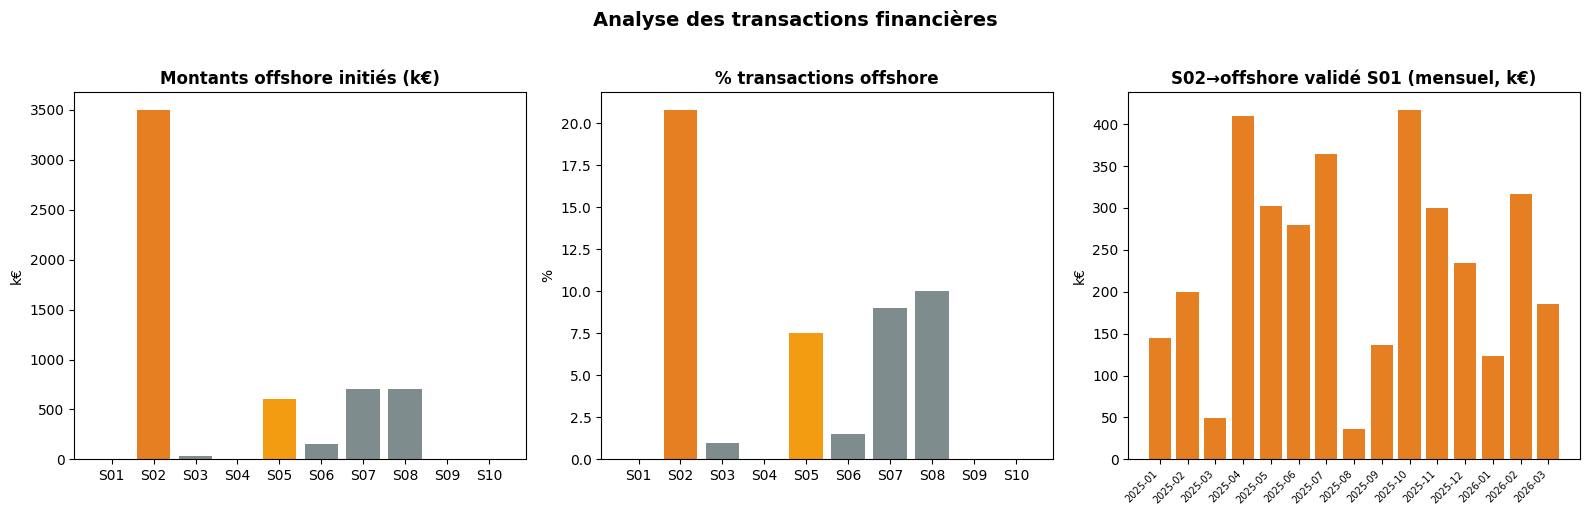

Total S02→offshore→validé S01 : 3.50 M€ sur 125 opérations


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = [PALETTE.get(s, '#aaa') for s in txdf['suspect']]

axes[0].bar(txdf['suspect'], txdf['montant_off_k€'], color=colors)
axes[0].set_title("Montants offshore initiés (k€)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("k€")
axes[0].axhline(0, color='black', lw=0.5)

axes[1].bar(txdf['suspect'], txdf['pct_offshore'], color=colors)
axes[1].set_title("% transactions offshore", fontsize=12, fontweight='bold')
axes[1].set_ylabel("%")

s02_off = transact[(transact['id_suspect_initiateur']=='S02') &
                   (transact['offshore']) &
                   (transact['validateur_id']=='S01')].copy()
s02_off['mois'] = s02_off['date'].dt.to_period('M').astype(str)
monthly = s02_off.groupby('mois')['montant_eur'].sum() / 1000
axes[2].bar(range(len(monthly)), monthly.values, color='#E67E22')
axes[2].set_xticks(range(len(monthly)))
axes[2].set_xticklabels(monthly.index, rotation=45, ha='right', fontsize=7)
axes[2].set_title("S02→offshore validé S01 (mensuel, k€)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("k€")

plt.suptitle("Analyse des transactions financières", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR + 'img/fig_transactions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Total S02→offshore→validé S01 : {s02_off['montant_eur'].sum()/1e6:.2f} M€ sur {len(s02_off)} opérations")


### 2.2 Interrogatoire — BPM par type de question

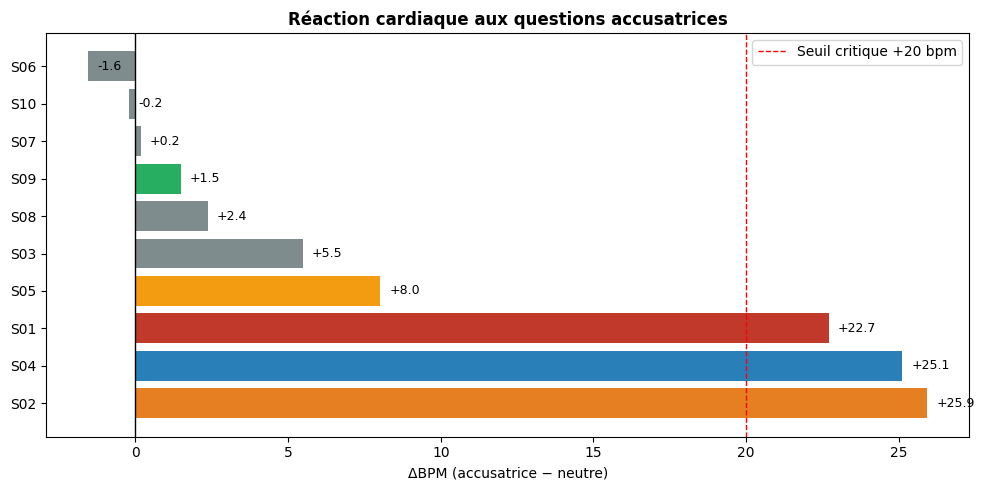

,id_suspect,bpm_n,bpm_a,delta_bpm,delta_rt
1,S02,69.873333,95.800000,25.93,3.70
3,S04,68.133333,93.246667,25.11,4.31
0,S01,71.480000,94.180000,22.70,4.82
4,S05,73.926667,81.940000,8.01,1.27
2,S03,68.400000,73.880000,5.48,0.18
7,S08,70.293333,72.660000,2.37,0.92
8,S09,71.280000,72.760000,1.48,0.35
6,S07,71.433333,71.613333,0.18,0.59
9,S10,72.046667,71.840000,-0.21,-0.47
5,S06,71.473333,69.926667,-1.55,0.80


In [7]:
bpm_stats = interrogat.groupby(['id_suspect','type_question']).agg(
    bpm=('rythme_cardiaque_bpm','mean'),
    rt=('temps_reponse_sec','mean')
).reset_index()

neutre = bpm_stats[bpm_stats['type_question']=='neutre'][['id_suspect','bpm','rt']].rename(
    columns={'bpm':'bpm_n','rt':'rt_n'})
accus  = bpm_stats[bpm_stats['type_question']=='accusatrice'][['id_suspect','bpm','rt']].rename(
    columns={'bpm':'bpm_a','rt':'rt_a'})
delta_df = neutre.merge(accus, on='id_suspect')
delta_df['delta_bpm'] = (delta_df['bpm_a'] - delta_df['bpm_n']).round(2)
delta_df['delta_rt']  = (delta_df['rt_a']  - delta_df['rt_n']).round(2)
delta_df = delta_df.sort_values('delta_bpm', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_d = [PALETTE.get(s, '#aaa') for s in delta_df['id_suspect']]
bars = ax.barh(delta_df['id_suspect'], delta_df['delta_bpm'], color=colors_d)
ax.axvline(0, color='black', lw=1)
ax.axvline(20, color='red', lw=1, ls='--', label='Seuil critique +20 bpm')
ax.set_xlabel("ΔBPM (accusatrice − neutre)")
ax.set_title("Réaction cardiaque aux questions accusatrices", fontweight='bold')
ax.legend()
for bar, val in zip(bars, delta_df['delta_bpm']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'+{val:.1f}' if val > 0 else f'{val:.1f}',
            va='center', fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR + 'img/fig_bpm_delta.png', dpi=150, bbox_inches='tight')
plt.show()
delta_df[['id_suspect','bpm_n','bpm_a','delta_bpm','delta_rt']]


### 2.3 Logs d'accès — nuit du 14 mars 2026

In [8]:
logs['timestamp'] = pd.to_datetime(logs['timestamp'])
nuit = logs[(logs['timestamp'] >= '2026-03-14 18:00') &
            (logs['timestamp'] <  '2026-03-15 06:00')].sort_values('timestamp')

print("=== Chronologie nuit du 14 mars 2026 ===")
for _, r in nuit.iterrows():
    flag = '★ CRITIQUE' if (r['id_suspect']=='S01' and r['lieu']=='bureau_victime') else ''
    print(f"  {r['timestamp'].strftime('%H:%M')}  {r['id_suspect']}  {r['lieu']:30s}  {r['action']}  {flag}")

entree = nuit[(nuit['id_suspect']=='S01') & (nuit['lieu']=='bureau_victime') & (nuit['action']=='entree')]['timestamp'].values[0]
sortie = nuit[(nuit['id_suspect']=='S01') & (nuit['lieu']=='bureau_victime') & (nuit['action']=='sortie')]['timestamp'].values[0]
duree = (pd.Timestamp(sortie) - pd.Timestamp(entree)).seconds // 60
print(f"\n★ S01 (DUBOIS) passe {duree} minutes seule dans le bureau de la victime")


=== Chronologie nuit du 14 mars 2026 ===
  19:06  S04  entree_principale               entree  
  19:10  S05  entree_principale               entree  
  19:47  S01  entree_principale               entree  
  20:00  S05  etage_4_direction               entree  
  20:12  S01  bureau_victime                  entree  ★ CRITIQUE
  20:15  S02  salle_serveurs                  entree  
  20:15  S04  salle_serveurs                  entree  
  20:16  S10  entree_principale               entree  
  20:29  S10  salle_archives                  entree  
  20:34  S02  entree_principale               entree  
  20:47  S01  bureau_victime                  sortie  ★ CRITIQUE
  20:52  S06  etage_4_direction               entree  
  20:54  S06  entree_principale               entree  
  21:10  S04  salle_serveurs                  sortie  
  21:10  S02  salle_serveurs                  sortie  
  22:41  S02  entree_principale               sortie  
  22:54  S10  entree_principale               sortie  
  22

=== EMAILS COMPROMETTANTS — E00001 à E00021 ===
Nombre d'emails critiques : 21

  E00001  2026-01-13  S01 → S02
    Sujet : Dossier Pégase
    Corps : Antoine, le dossier Pégase est prêt. Procède au transfert habituel. Discrétion absolue.

  E00002  2026-01-14  S02 → S01
    Sujet : RE: Dossier Pégase
    Corps : Claire, transfert Pégase effectué. 380k€ sur le compte habituel.

  E00003  2026-01-18  S01 → S04
    Sujet : Comptes Hermès
    Corps : Karim, les logs des comptes Hermès doivent disparaître ce soir.

  E00004  2026-01-18  S04 → S01
    Sujet : RE: Comptes Hermès
    Corps : Logs Hermès purgés. Aucune trace résiduelle.

  E00005  2026-01-23  S01 → S02
    Sujet : Transfert Cerbère
    Corps : Antoine, lance Cerbère lundi. Montant habituel. Je validerai.

  E00006  2026-01-24  S02 → S01
    Sujet : RE: Transfert Cerbère
    Corps : Cerbère exécuté. Confirmation côté KY reçue.

  E00007  2026-01-28  S04 → S02
    Sujet : Pégase nettoyage
    Corps : J’ai effacé l’audit trail Pé

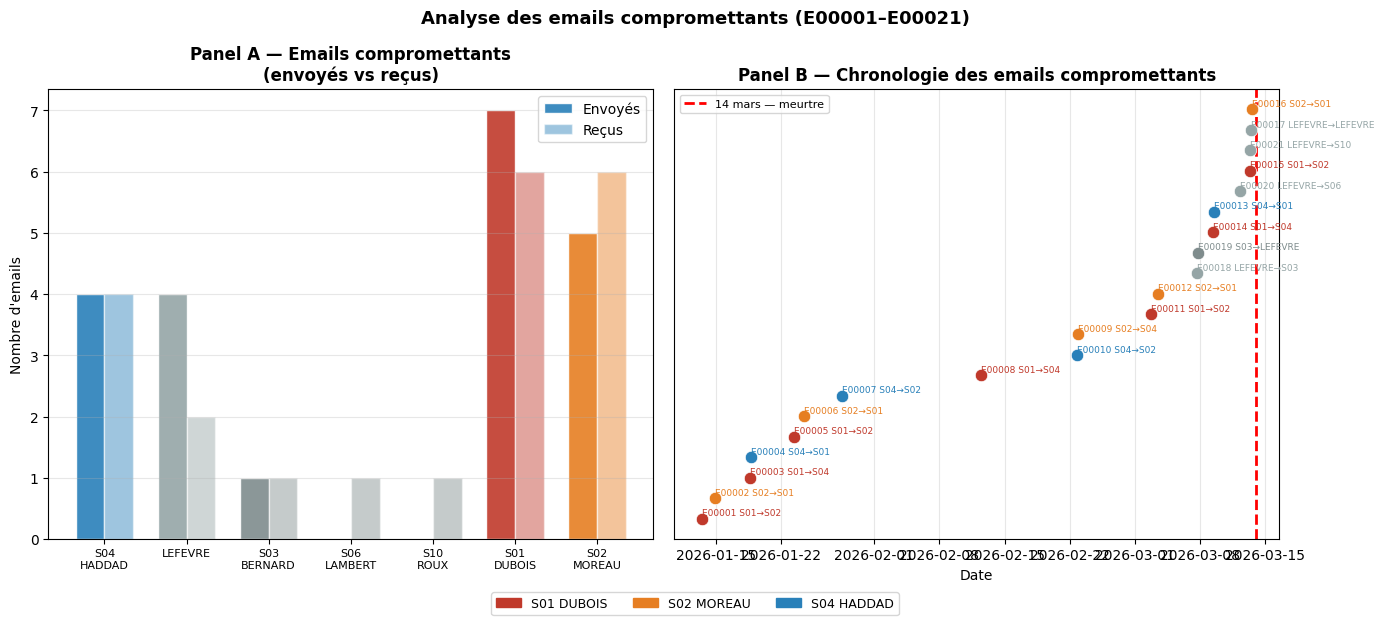

✓ Figure emails compromettants générée


In [9]:
critical_ids = [f'E{i:05d}' for i in range(1, 22)]
emails_crit  = emails[emails['id_email'].isin(critical_ids)].copy()
emails_crit  = emails_crit.sort_values('id_email')

print("=== EMAILS COMPROMETTANTS — E00001 à E00021 ===")
print(f"Nombre d'emails critiques : {len(emails_crit)}")
print()

for _, row in emails_crit.iterrows():
    exp  = row['expediteur_id']
    dest = row['destinataire_id']
    date = str(row['timestamp'])[:10] if 'timestamp' in row else row.get('date','?')
    print(f"  {row['id_email']}  {date}  {exp} → {dest}")
    print(f"    Sujet : {row.get('sujet','N/A')}")
    print(f"    Corps : {str(row.get('corps','N/A'))[:120]}")
    print()

print("=== RÉSEAU DE COMMUNICATION (emails compromettants) ===")
reseau = emails_crit.groupby(['expediteur_id','destinataire_id']).size().reset_index(name='nb')
for _, r in reseau.iterrows():
    print(f"  {r['expediteur_id']} ({NOMS.get(r['expediteur_id'],'?')}) "
          f"→ {r['destinataire_id']} ({NOMS.get(r['destinataire_id'],'?')}) "
          f": {r['nb']} email(s)")

print()
print("=== EMAILS COMPROMETTANTS ENVOYÉS PAR SUSPECT ===")
sent = emails_crit['expediteur_id'].value_counts()
for s, n in sent.items():
    print(f"  {s} ({NOMS.get(s,'?'):<10}) : {n} email(s) envoyé(s)")


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Analyse des emails compromettants (E00001–E00021)",
             fontsize=13, fontweight='bold')

sent_counts = emails_crit['expediteur_id'].value_counts()
recv_counts = emails_crit['destinataire_id'].value_counts()

all_suspects_emails = list(set(list(sent_counts.index) + list(recv_counts.index)))
sent_vals = [sent_counts.get(s, 0) for s in all_suspects_emails]
recv_vals  = [recv_counts.get(s, 0) for s in all_suspects_emails]

x    = np.arange(len(all_suspects_emails))
w    = 0.35
cols = [PALETTE.get(s, '#95A5A6') for s in all_suspects_emails]

axes[0].bar(x - w/2, sent_vals, w, color=cols, alpha=0.9,
            edgecolor='white', label='Envoyés')
axes[0].bar(x + w/2, recv_vals, w, color=cols, alpha=0.45,
            edgecolor='white', label='Reçus')
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [f"{s}\n{NOMS.get(s,'')}" for s in all_suspects_emails],
    fontsize=8
)
axes[0].set_title("Panel A — Emails compromettants\n(envoyés vs reçus)",
                  fontweight='bold')
axes[0].set_ylabel("Nombre d'emails")
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

# Panel B — Chronologie des emails
emails_crit['date_parsed'] = pd.to_datetime(
    emails_crit.get('timestamp', emails_crit.get('date', None)),
    errors='coerce'
)
emails_crit_sorted = emails_crit.dropna(subset=['date_parsed']).sort_values('date_parsed')

for idx, (_, row) in enumerate(emails_crit_sorted.iterrows()):
    exp   = row['expediteur_id']
    c     = PALETTE.get(exp, '#95A5A6')
    date  = row['date_parsed']
    axes[1].scatter(date, idx, color=c, s=80, zorder=3,
                    edgecolors='white', linewidth=0.5)
    axes[1].text(date, idx + 0.15,
                 f"{row['id_email']} {exp}→{row['destinataire_id']}",
                 fontsize=6.5, color=c)

# Ligne du meurtre
import matplotlib.dates as mdates
murder_date = pd.Timestamp('2026-03-14')
axes[1].axvline(murder_date, color='red', lw=2, ls='--',
                label='14 mars — meurtre')
axes[1].set_title("Panel B — Chronologie des emails compromettants",
                  fontweight='bold')
axes[1].set_xlabel("Date")
axes[1].set_yticks([])
axes[1].legend(fontsize=8)
axes[1].grid(True, axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_e = [
    Patch(color=PALETTE['S01'], label='S01 DUBOIS'),
    Patch(color=PALETTE['S02'], label='S02 MOREAU'),
    Patch(color=PALETTE['S04'], label='S04 HADDAD'),
]
fig.legend(handles=legend_e, loc='lower center',
           ncol=3, bbox_to_anchor=(0.5, -0.04), fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR + 'img/emails_compromettants.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure emails compromettants générée")

## 3. Tests statistiques inférentiels

> Conformément aux exigences de la juge AUBRY : H₀, H₁, conditions d'application, p-value, conclusion.

### 3.1 Test de normalité Shapiro-Wilk (BPM)

In [10]:
print("=== Shapiro-Wilk : normalité du BPM par suspect ===")
print(f"{'Suspect':<10} {'Type':<12} {'W':<10} {'p-value':<12} {'Normal ?'}")
print("-"*55)

for s in SUSPECTS:
    for qtype in ['neutre', 'accusatrice']:
        vals = interrogat[(interrogat['id_suspect']==s) &
                          (interrogat['type_question']==qtype)]['rythme_cardiaque_bpm'].values
        if len(vals) >= 3:
            W, p = shapiro(vals)
            normal = "✓ Oui" if p > 0.05 else "✗ Non"
            print(f"  {s:<8} {qtype:<12} {W:.4f}    {p:<12.4f} {normal}")


=== Shapiro-Wilk : normalité du BPM par suspect ===
Suspect    Type         W          p-value      Normal ?
-------------------------------------------------------
  S01      neutre       0.9732    0.9028       ✓ Oui
  S01      accusatrice  0.9114    0.1425       ✓ Oui
  S02      neutre       0.9337    0.3095       ✓ Oui
  S02      accusatrice  0.9713    0.8763       ✓ Oui
  S03      neutre       0.9412    0.3972       ✓ Oui
  S03      accusatrice  0.9538    0.5867       ✓ Oui
  S04      neutre       0.9548    0.6027       ✓ Oui
  S04      accusatrice  0.9176    0.1769       ✓ Oui
  S05      neutre       0.9504    0.5313       ✓ Oui
  S05      accusatrice  0.8802    0.0478       ✗ Non
  S06      neutre       0.9426    0.4161       ✓ Oui
  S06      accusatrice  0.9522    0.5596       ✓ Oui
  S07      neutre       0.9427    0.4177       ✓ Oui
  S07      accusatrice  0.9284    0.2586       ✓ Oui
  S08      neutre       0.9399    0.3817       ✓ Oui
  S08      accusatrice  0.9794    0.9656

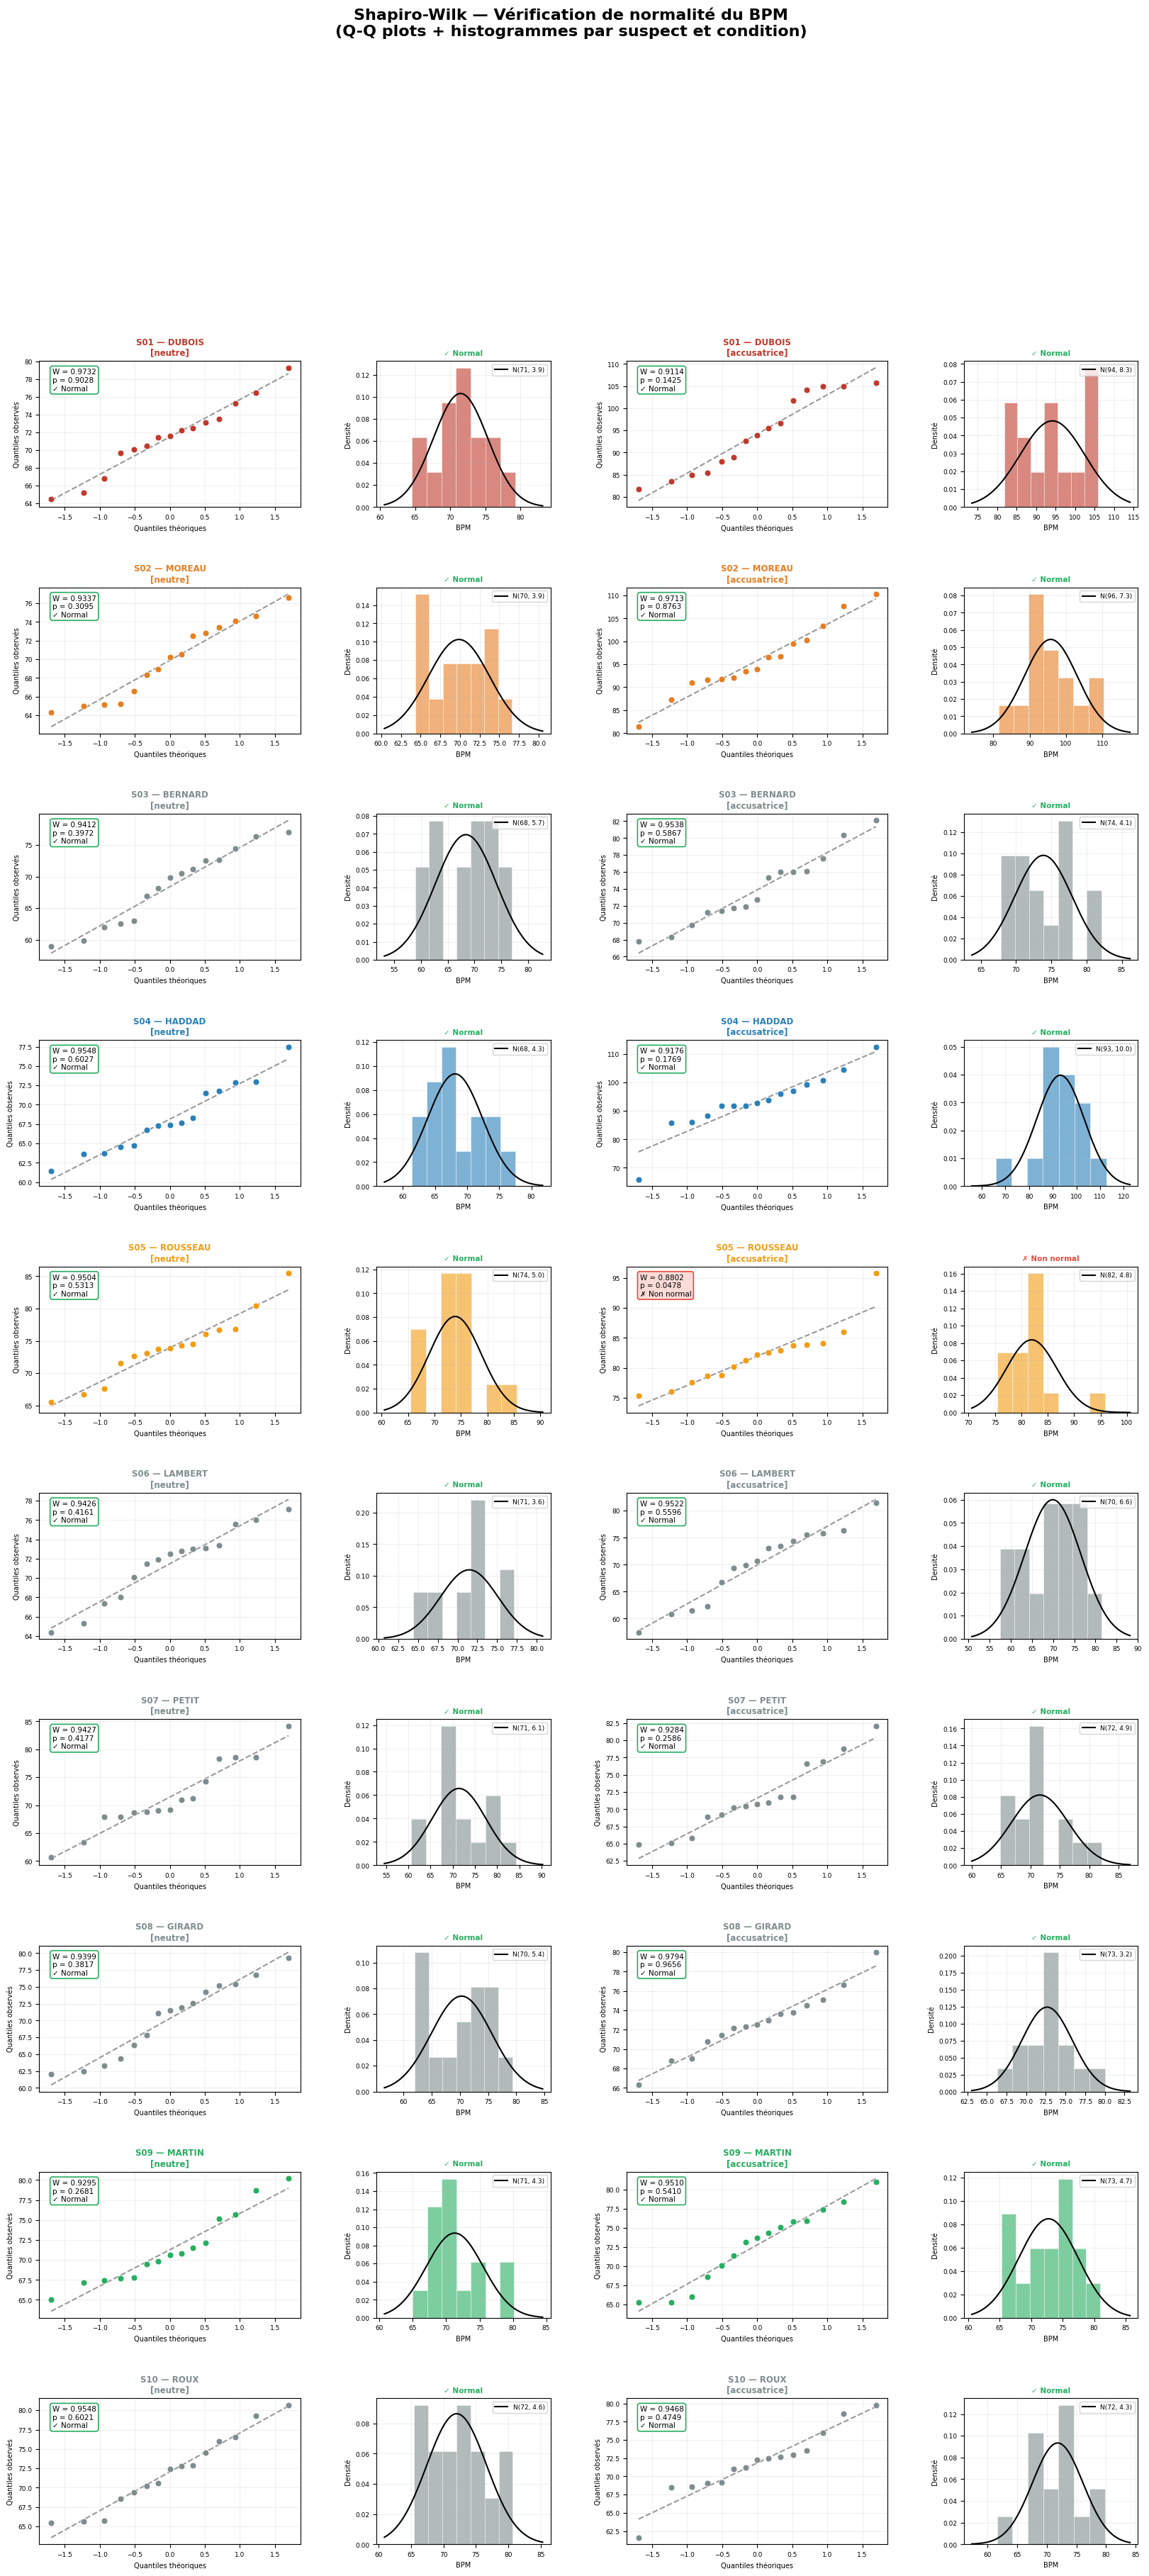

✓ Figure Shapiro-Wilk générée


In [11]:
# ── Visualisation Shapiro-Wilk — Q-Q plots + histogrammes ──────
# Utilise SUSPECTS, NOMS, PALETTE déjà définis en cellule 0
import matplotlib.gridspec as gridspec


QTYPES = ['neutre', 'accusatrice']

fig = plt.figure(figsize=(20, 40))
fig.suptitle(
    "Shapiro-Wilk — Vérification de normalité du BPM\n"
    "(Q-Q plots + histogrammes par suspect et condition)",
    fontsize=16, fontweight='bold', y=1.005
)

outer = gridspec.GridSpec(10, 1, figure=fig, hspace=0.55)

for i, s in enumerate(SUSPECTS):
    color = PALETTE.get(s, '#7F8C8D')

    inner = gridspec.GridSpecFromSubplotSpec(
        1, 4, subplot_spec=outer[i],
        wspace=0.35,
        width_ratios=[1.2, 0.8, 1.2, 0.8]
    )

    for j, qtype in enumerate(QTYPES):
        vals = interrogat[
            (interrogat['id_suspect'] == s) &
            (interrogat['type_question'] == qtype)
        ]['rythme_cardiaque_bpm'].values

        W, p        = shapiro(vals)
        normal      = "✓ Normal"    if p > 0.05 else "✗ Non normal"
        status_color = '#27AE60'    if p > 0.05 else '#E74C3C'
        fond         = '#FDFEFE'    if p > 0.05 else '#FADBD8'

        col_offset = j * 2

        ax_qq = fig.add_subplot(inner[col_offset])

        (osm, osr), (slope, intercept, _) = stats.probplot(vals, dist="norm", fit=True)
        x_line = np.linspace(osm.min(), osm.max(), 100)

        ax_qq.plot(x_line, slope * x_line + intercept,
                   color='gray', lw=1.5, ls='--', alpha=0.8, zorder=1)
        ax_qq.scatter(osm, osr, color=color, s=40, zorder=2,
                      edgecolors='white', linewidth=0.5)
        ax_qq.text(
            0.05, 0.95,
            f"W = {W:.4f}\np = {p:.4f}\n{normal}",
            transform=ax_qq.transAxes, fontsize=7.5, va='top',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor=fond, edgecolor=status_color, linewidth=1.2)
        )
        ax_qq.set_title(
            f"{s} — {NOMS[s]}\n[{qtype}]",
            fontsize=8.5, fontweight='bold', color=color
        )
        ax_qq.set_xlabel("Quantiles théoriques", fontsize=7)
        ax_qq.set_ylabel("Quantiles observés",   fontsize=7)
        ax_qq.tick_params(labelsize=6.5)
        ax_qq.grid(True, alpha=0.3, lw=0.5)

        ax_hist = fig.add_subplot(inner[col_offset + 1])

        mu, sigma = vals.mean(), vals.std()
        x_norm    = np.linspace(vals.min() - sigma, vals.max() + sigma, 200)

        n_bins = min(8, len(vals) // 2) if len(vals) > 6 else 5
        ax_hist.hist(vals, bins=n_bins, density=True,
                     color=color, alpha=0.6, edgecolor='white', linewidth=0.5)
        ax_hist.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma),
                     color='black', lw=1.5, label=f'N({mu:.0f}, {sigma:.1f})')

        ax_hist.set_title(normal, fontsize=7.5,
                          color=status_color, fontweight='bold')
        ax_hist.set_xlabel("BPM", fontsize=7)
        ax_hist.set_ylabel("Densité", fontsize=7)
        ax_hist.tick_params(labelsize=6.5)
        ax_hist.legend(fontsize=6.5, loc='upper right')
        ax_hist.grid(True, alpha=0.3, lw=0.5)

plt.savefig(DATA_DIR + 'img/shapiro_wilk_visualisation.png',
            dpi=130, bbox_inches='tight')
plt.show()
print("✓ Figure Shapiro-Wilk générée")

### 3.2 Test t apparié — BPM neutre vs accusatrice (par suspect)

In [12]:
print("=== t-test apparié : H₀ = pas de différence de BPM entre questions neutres et accusatrices ===")
print()
print(f"{'Suspect':<8} {'Δ BPM moyen':<14} {'t-stat':<10} {'p-value':<12} {'Verdict (α=0.05)'}")
print("-"*65)

results_ttest = []
for s in SUSPECTS:
    neu = interrogat[(interrogat['id_suspect']==s) &
                     (interrogat['type_question']=='neutre')].sort_values('num_question')['rythme_cardiaque_bpm'].values
    acc = interrogat[(interrogat['id_suspect']==s) &
                     (interrogat['type_question']=='accusatrice')].sort_values('num_question')['rythme_cardiaque_bpm'].values
    t, p = ttest_rel(acc, neu)
    delta = acc.mean() - neu.mean()
    sig = "*** SIGNIFICATIF" if p < 0.001 else ("** sig" if p < 0.01 else ("* sig" if p < 0.05 else "n.s."))
    print(f"  {s:<6} {delta:+.2f} bpm       {t:+.3f}     {p:<12.4e} {sig}")
    results_ttest.append({'suspect':s,'delta_bpm':round(delta,2),'t':round(t,3),'p':p,'sig':p<0.05})

ttest_df = pd.DataFrame(results_ttest)
print()
print("H₀ rejetée (p < 0.05) pour :", [r['suspect'] for r in results_ttest if r['sig']])


=== t-test apparié : H₀ = pas de différence de BPM entre questions neutres et accusatrices ===

Suspect  Δ BPM moyen    t-stat     p-value      Verdict (α=0.05)
-----------------------------------------------------------------
  S01    +22.70 bpm       +8.252     9.5254e-07   *** SIGNIFICATIF
  S02    +25.93 bpm       +9.991     9.4470e-08   *** SIGNIFICATIF
  S03    +5.48 bpm       +3.379     4.5009e-03   ** sig
  S04    +25.11 bpm       +9.145     2.7928e-07   *** SIGNIFICATIF
  S05    +8.01 bpm       +4.102     1.0787e-03   ** sig
  S06    -1.55 bpm       -0.703     4.9339e-01   n.s.
  S07    +0.18 bpm       +0.089     9.3057e-01   n.s.
  S08    +2.37 bpm       +1.521     1.5043e-01   n.s.
  S09    +1.48 bpm       +1.075     3.0036e-01   n.s.
  S10    -0.21 bpm       -0.124     9.0276e-01   n.s.

H₀ rejetée (p < 0.05) pour : ['S01', 'S02', 'S03', 'S04', 'S05']


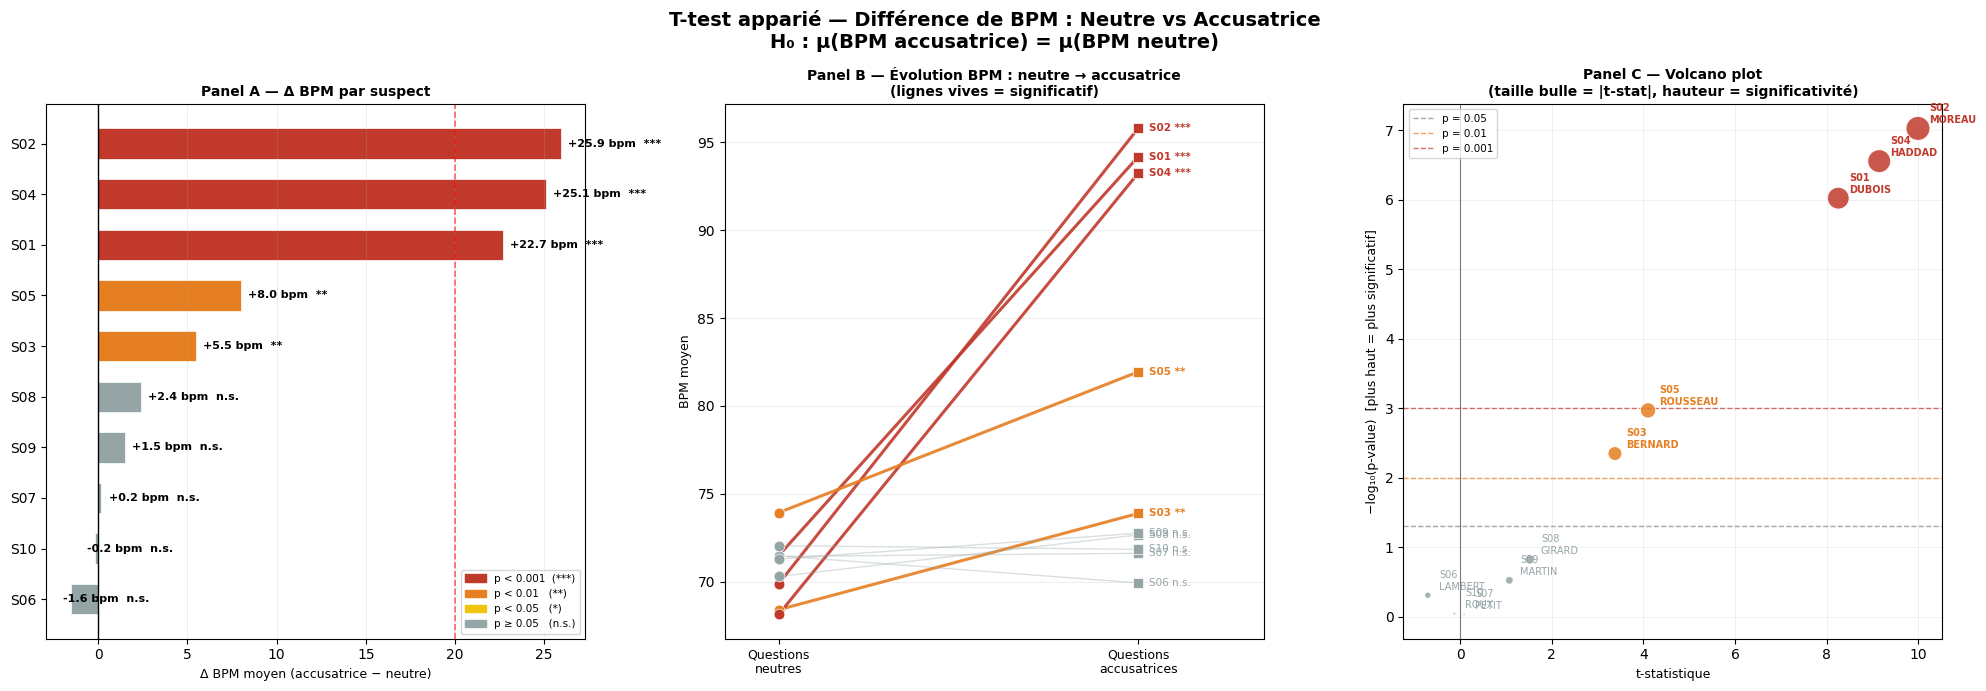

✓ Figure t-test apparié générée


In [13]:
# ── Visualisation t-test apparié BPM ───────────────────────────
# 3 panels : Δ BPM | Paired plot | t-stat vs p-value

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    "T-test apparié — Différence de BPM : Neutre vs Accusatrice\n"
    "H₀ : μ(BPM accusatrice) = μ(BPM neutre)",
    fontsize=14, fontweight='bold'
)

def sig_color(p):
    if p < 0.001 : return '#C0392B'   # rouge   — ***
    elif p < 0.01: return '#E67E22'   # orange  — **
    elif p < 0.05: return '#F1C40F'   # jaune   — *
    else          : return '#95A5A6'  # gris    — n.s.

def sig_label(p):
    if p < 0.001 : return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else          : return 'n.s.'

ttest_df_sorted = ttest_df.sort_values('delta_bpm', ascending=True)
colors_bar      = [sig_color(row['p']) for _, row in ttest_df_sorted.iterrows()]

# ══════════════════════════════════════════════
# PANEL 1 — Barres horizontales Δ BPM
# ══════════════════════════════════════════════
bars = axes[0].barh(
    ttest_df_sorted['suspect'],
    ttest_df_sorted['delta_bpm'],
    color=colors_bar,
    edgecolor='white', linewidth=0.5, height=0.6
)
axes[0].axvline(0, color='black', lw=1)
axes[0].axvline(20, color='red', lw=1.2, ls='--', alpha=0.6, label='Seuil critique +20 bpm')

for bar, (_, row) in zip(bars, ttest_df_sorted.iterrows()):
    val   = row['delta_bpm']
    label = f"{val:+.1f} bpm  {sig_label(row['p'])}"
    x_pos = val + 0.4 if val >= 0 else val - 0.4
    ha    = 'left' if val >= 0 else 'right'
    axes[0].text(x_pos, bar.get_y() + bar.get_height()/2,
                 label, va='center', fontsize=8, fontweight='bold')

from matplotlib.patches import Patch
legend_sig = [
    Patch(color='#C0392B', label='p < 0.001  (***)'),
    Patch(color='#E67E22', label='p < 0.01   (**)'),
    Patch(color='#F1C40F', label='p < 0.05   (*)'),
    Patch(color='#95A5A6', label='p ≥ 0.05   (n.s.)'),
]
axes[0].legend(handles=legend_sig, fontsize=7.5, loc='lower right')
axes[0].set_xlabel("Δ BPM moyen (accusatrice − neutre)", fontsize=9)
axes[0].set_title("Panel A — Δ BPM par suspect", fontweight='bold', fontsize=10)
axes[0].grid(True, axis='x', alpha=0.3, lw=0.5)

# ══════════════════════════════════════════════
# PANEL 2 — Paired plot neutre → accusatrice
# ══════════════════════════════════════════════
bpm_pairs = []
for s in SUSPECTS:
    neu_mean = interrogat[(interrogat['id_suspect']==s) &
                          (interrogat['type_question']=='neutre')]['rythme_cardiaque_bpm'].mean()
    acc_mean = interrogat[(interrogat['id_suspect']==s) &
                          (interrogat['type_question']=='accusatrice')]['rythme_cardiaque_bpm'].mean()
    bpm_pairs.append({'suspect': s, 'neutre': neu_mean, 'accusatrice': acc_mean,
                      'p': ttest_df[ttest_df['suspect']==s]['p'].values[0]})

pairs_df = pd.DataFrame(bpm_pairs)

for _, row in pairs_df.iterrows():
    c     = sig_color(row['p'])
    alpha = 0.9 if row['p'] < 0.05 else 0.35
    lw    = 2.2  if row['p'] < 0.05 else 1.0

    axes[1].plot([0, 1], [row['neutre'], row['accusatrice']],
                 color=c, lw=lw, alpha=alpha, zorder=2)

    axes[1].scatter([0], [row['neutre']],     color=c, s=60, zorder=3,
                    edgecolors='white', linewidth=0.5)
    axes[1].scatter([1], [row['accusatrice']], color=c, s=60, zorder=3,
                    marker='s', edgecolors='white', linewidth=0.5)

    axes[1].text(1.03, row['accusatrice'],
                 f"{row['suspect']} {sig_label(row['p'])}",
                 va='center', fontsize=7.5,
                 color=c, fontweight='bold' if row['p']<0.05 else 'normal')

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Questions\nneutres', 'Questions\naccusatrices'], fontsize=9)
axes[1].set_ylabel("BPM moyen", fontsize=9)
axes[1].set_title("Panel B — Évolution BPM : neutre → accusatrice\n(lignes vives = significatif)",
                  fontweight='bold', fontsize=10)
axes[1].grid(True, axis='y', alpha=0.3, lw=0.5)
axes[1].set_xlim(-0.15, 1.35)

# ══════════════════════════════════════════════
# PANEL 3 — Bubble chart : t-stat vs -log10(p)
# ══════════════════════════════════════════════
ttest_df['log_p']      = -np.log10(ttest_df['p'])
ttest_df['abs_t']      = ttest_df['t'].abs()
ttest_df['bubble_col'] = ttest_df['p'].apply(sig_color)

scatter = axes[2].scatter(
    ttest_df['t'],
    ttest_df['log_p'],
    s=ttest_df['abs_t'] * 30,          
    c=ttest_df['bubble_col'],
    edgecolors='white', linewidth=0.8,
    zorder=3, alpha=0.85
)

axes[2].axhline(-np.log10(0.05),  color='gray',  lw=1, ls='--',
                label='p = 0.05',  alpha=0.7)
axes[2].axhline(-np.log10(0.01),  color='#E67E22', lw=1, ls='--',
                label='p = 0.01',  alpha=0.7)
axes[2].axhline(-np.log10(0.001), color='#C0392B', lw=1, ls='--',
                label='p = 0.001', alpha=0.7)
axes[2].axvline(0, color='black', lw=0.8, alpha=0.5)

for _, row in ttest_df.iterrows():
    axes[2].annotate(
        f"{row['suspect']}\n{NOMS[row['suspect']]}",
        (row['t'], row['log_p']),
        textcoords='offset points', xytext=(8, 4),
        fontsize=7, color=sig_color(row['p']),
        fontweight='bold' if row['p'] < 0.05 else 'normal'
    )

axes[2].set_xlabel("t-statistique", fontsize=9)
axes[2].set_ylabel("−log₁₀(p-value)  [plus haut = plus significatif]", fontsize=9)
axes[2].set_title("Panel C — Volcano plot\n(taille bulle = |t-stat|, hauteur = significativité)",
                  fontweight='bold', fontsize=10)
axes[2].legend(fontsize=7.5, loc='upper left')
axes[2].grid(True, alpha=0.25, lw=0.5)

plt.tight_layout()
plt.savefig(DATA_DIR + 'img/test_bpm_visualisation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure t-test apparié générée")

### 3.3 t-test de Welch — S02 vs reste (montants offshore)

In [14]:
s02_offshore = transact[(transact['id_suspect_initiateur']=='S02') & (transact['offshore'])]['montant_eur']
others_offshore = transact[(transact['id_suspect_initiateur']!='S02') & (transact['offshore'])]['montant_eur']

t, p = ttest_ind(s02_offshore, others_offshore, equal_var=False)
print("=== t-test de Welch — montants offshore S02 vs autres ===")
print(f"H₀ : μ(offshore_S02) = μ(offshore_autres)")
print(f"H₁ : μ(offshore_S02) ≠ μ(offshore_autres)")
print()
print(f"  S02     — n={len(s02_offshore)}, moyenne={s02_offshore.mean():.0f}€, σ={s02_offshore.std():.0f}€")
print(f"  Autres  — n={len(others_offshore)}, moyenne={others_offshore.mean():.0f}€, σ={others_offshore.std():.0f}€")
print(f"  t-stat  = {t:.4f}")
print(f"  p-value = {p:.4e}")
print()
if p < 0.05:
    print("  → H₀ rejetée : S02 présente des montants offshore statistiquement différents.")
else:
    print("  → H₀ non rejetée.")


=== t-test de Welch — montants offshore S02 vs autres ===
H₀ : μ(offshore_S02) = μ(offshore_autres)
H₁ : μ(offshore_S02) ≠ μ(offshore_autres)

  S02     — n=125, moyenne=28000€, σ=20203€
  Autres  — n=63, moyenne=34715€, σ=20123€
  t-stat  = -2.1568
  p-value = 3.2934e-02

  → H₀ rejetée : S02 présente des montants offshore statistiquement différents.


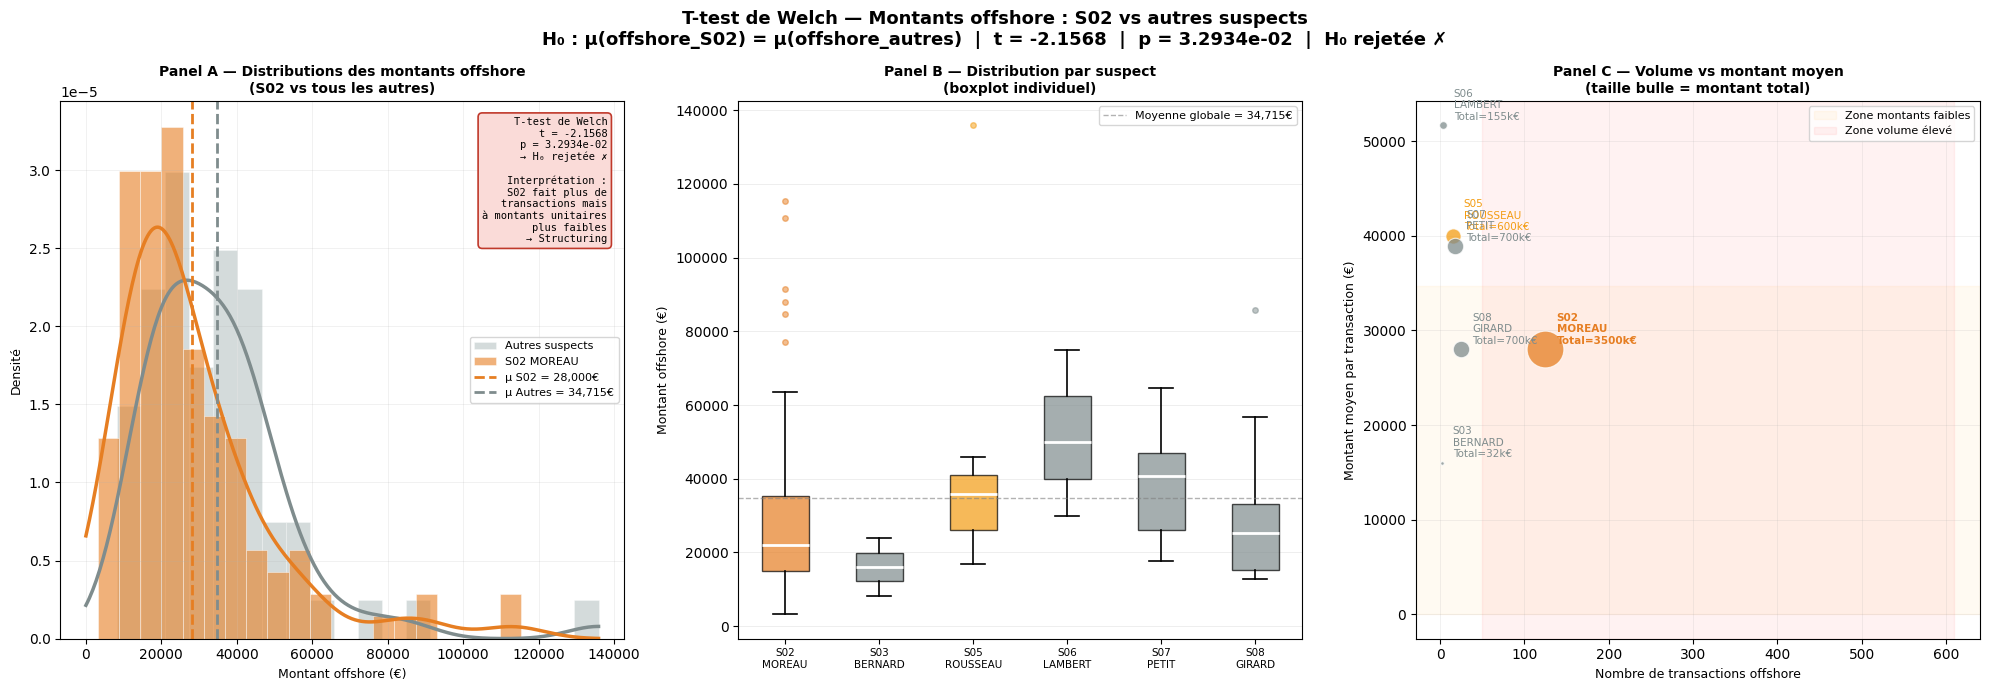

✓ Figure t-test de Welch générée


In [15]:
# ── Visualisation t-test de Welch — montants offshore S02 vs autres ──
# 3 panels : distributions | boxplot | effect size

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    "T-test de Welch — Montants offshore : S02 vs autres suspects\n"
    "H₀ : μ(offshore_S02) = μ(offshore_autres)  |  "
    f"t = {t:.4f}  |  p = {p:.4e}  |  H₀ {'rejetée ✗' if p < 0.05 else 'non rejetée ✓'}",
    fontsize=13, fontweight='bold'
)

s02_vals    = s02_offshore.values
others_vals = others_offshore.values

autres_par_suspect = {
    s: transact[(transact['id_suspect_initiateur']==s) &
                (transact['offshore'])]['montant_eur'].values
    for s in SUSPECTS if s != 'S02'
}
autres_par_suspect = {s: v for s, v in autres_par_suspect.items() if len(v) > 0}

# ══════════════════════════════════════════════
# PANEL 1 — Distributions superposées (KDE + histogramme)
# ══════════════════════════════════════════════
from scipy.stats import gaussian_kde

axes[0].hist(others_vals, bins=20, density=True,
             color='#95A5A6', alpha=0.4, edgecolor='white',
             linewidth=0.5, label='Autres suspects')
axes[0].hist(s02_vals, bins=20, density=True,
             color='#E67E22', alpha=0.6, edgecolor='white',
             linewidth=0.5, label='S02 MOREAU')

for vals, color, label in [
    (others_vals, '#7F8C8D', 'KDE Autres'),
    (s02_vals,    '#E67E22', 'KDE S02')
]:
    kde  = gaussian_kde(vals, bw_method=0.4)
    x_kd = np.linspace(0, max(vals.max(), others_vals.max()), 300)
    axes[0].plot(x_kd, kde(x_kd), color=color, lw=2.5)

axes[0].axvline(s02_vals.mean(),    color='#E67E22', lw=2, ls='--',
                label=f'μ S02 = {s02_vals.mean():,.0f}€')
axes[0].axvline(others_vals.mean(), color='#7F8C8D', lw=2, ls='--',
                label=f'μ Autres = {others_vals.mean():,.0f}€')

axes[0].set_xlabel("Montant offshore (€)", fontsize=9)
axes[0].set_ylabel("Densité", fontsize=9)
axes[0].set_title("Panel A — Distributions des montants offshore\n(S02 vs tous les autres)",
                  fontweight='bold', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.25, lw=0.5)

result_text = (
    f"T-test de Welch\n"
    f"t = {t:.4f}\n"
    f"p = {p:.4e}\n"
    f"→ H₀ {'rejetée ✗' if p < 0.05 else 'non rejetée ✓'}\n\n"
    f"Interprétation :\nS02 fait plus de\ntransactions mais\nà montants unitaires\nplus faibles\n→ Structuring"
)
axes[0].text(0.97, 0.97, result_text,
             transform=axes[0].transAxes,
             fontsize=7.5, va='top', ha='right', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.4',
                       facecolor='#FADBD8' if p < 0.05 else '#EAFAF1',
                       edgecolor='#C0392B' if p < 0.05 else '#27AE60',
                       linewidth=1.2))

# ══════════════════════════════════════════════
# PANEL 2 — Boxplot par suspect
# ══════════════════════════════════════════════
box_data   = [s02_vals] + [v for v in autres_par_suspect.values()]
box_labels = ['S02\nMOREAU'] + [f"{s}\n{NOMS[s]}" for s in autres_par_suspect.keys()]
box_colors = ['#E67E22'] + [PALETTE.get(s, '#95A5A6') for s in autres_par_suspect.keys()]

bp = axes[1].boxplot(
    box_data,
    patch_artist=True,
    notch=False,
    vert=True,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)

# Colorier chaque boîte
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for flier, color in zip(bp['fliers'], box_colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)

axes[1].set_xticklabels(box_labels, fontsize=7.5)
axes[1].set_ylabel("Montant offshore (€)", fontsize=9)
axes[1].set_title("Panel B — Distribution par suspect\n(boxplot individuel)",
                  fontweight='bold', fontsize=10)
axes[1].grid(True, axis='y', alpha=0.3, lw=0.5)

axes[1].axhline(others_vals.mean(), color='gray', lw=1,
                ls='--', alpha=0.6, label=f'Moyenne globale = {others_vals.mean():,.0f}€')
axes[1].legend(fontsize=8)

# ══════════════════════════════════════════════
# PANEL 3 — Volume vs montant moyen (bubble chart)
# ══════════════════════════════════════════════
for s in SUSPECTS:
    off = transact[(transact['id_suspect_initiateur']==s) & (transact['offshore'])]
    if len(off) == 0:
        continue

    nb_tx    = len(off)
    moy_tx   = off['montant_eur'].mean()
    total_tx = off['montant_eur'].sum()
    c        = '#E67E22' if s == 'S02' else PALETTE.get(s, '#95A5A6')
    size     = total_tx / 5000 

    axes[2].scatter(nb_tx, moy_tx, s=size, color=c,
                    alpha=0.75, edgecolors='white', linewidth=0.8, zorder=3)
    axes[2].annotate(
        f"{s}\n{NOMS[s]}\nTotal={total_tx/1000:.0f}k€",
        (nb_tx, moy_tx),
        textcoords='offset points', xytext=(8, 4),
        fontsize=7.5, color=c, fontweight='bold' if s=='S02' else 'normal'
    )

axes[2].axhspan(0, others_vals.mean(), alpha=0.05, color='orange',
                label='Zone montants faibles')
axes[2].axvspan(50, transact.groupby('id_suspect_initiateur').size().max()+10,
                alpha=0.05, color='red', label='Zone volume élevé')

axes[2].set_xlabel("Nombre de transactions offshore", fontsize=9)
axes[2].set_ylabel("Montant moyen par transaction (€)", fontsize=9)
axes[2].set_title("Panel C — Volume vs montant moyen\n(taille bulle = montant total)",
                  fontweight='bold', fontsize=10)
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.25, lw=0.5)

plt.tight_layout()
plt.savefig(DATA_DIR + 'img/welch_offshore_visualisation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure t-test de Welch générée")

### 3.4 ANOVA à 1 facteur — temps de réponse aux questions accusatrices par suspect

In [16]:
groups = [interrogat[(interrogat['id_suspect']==s) &
                     (interrogat['type_question']=='accusatrice')]['temps_reponse_sec'].values
          for s in SUSPECTS]

F, p_anova = f_oneway(*groups)
print("=== ANOVA : H₀ = même temps de réponse moyen pour tous les suspects ===")
print(f"  F-stat  = {F:.4f}")
print(f"  p-value = {p_anova:.4e}")
if p_anova < 0.05:
    print("  → H₀ rejetée : au moins un suspect se distingue significativement.")
    
top3 = ['S01','S02','S04']
rt_top3  = interrogat[(interrogat['id_suspect'].isin(top3)) &
                      (interrogat['type_question']=='accusatrice')]['temps_reponse_sec'].values
rt_other = interrogat[(~interrogat['id_suspect'].isin(top3)) &
                      (interrogat['type_question']=='accusatrice')]['temps_reponse_sec'].values
u, p_mw = mannwhitneyu(rt_top3, rt_other, alternative='greater')
print()
print(f"Post-hoc Mann-Whitney (top3 suspects vs autres) :")
print(f"  U={u:.1f}, p={p_mw:.4e} → {'Significatif' if p_mw<0.05 else 'Non significatif'}")


=== ANOVA : H₀ = même temps de réponse moyen pour tous les suspects ===
  F-stat  = 13.5592
  p-value = 1.7682e-15
  → H₀ rejetée : au moins un suspect se distingue significativement.

Post-hoc Mann-Whitney (top3 suspects vs autres) :
  U=4293.5, p=1.2135e-15 → Significatif


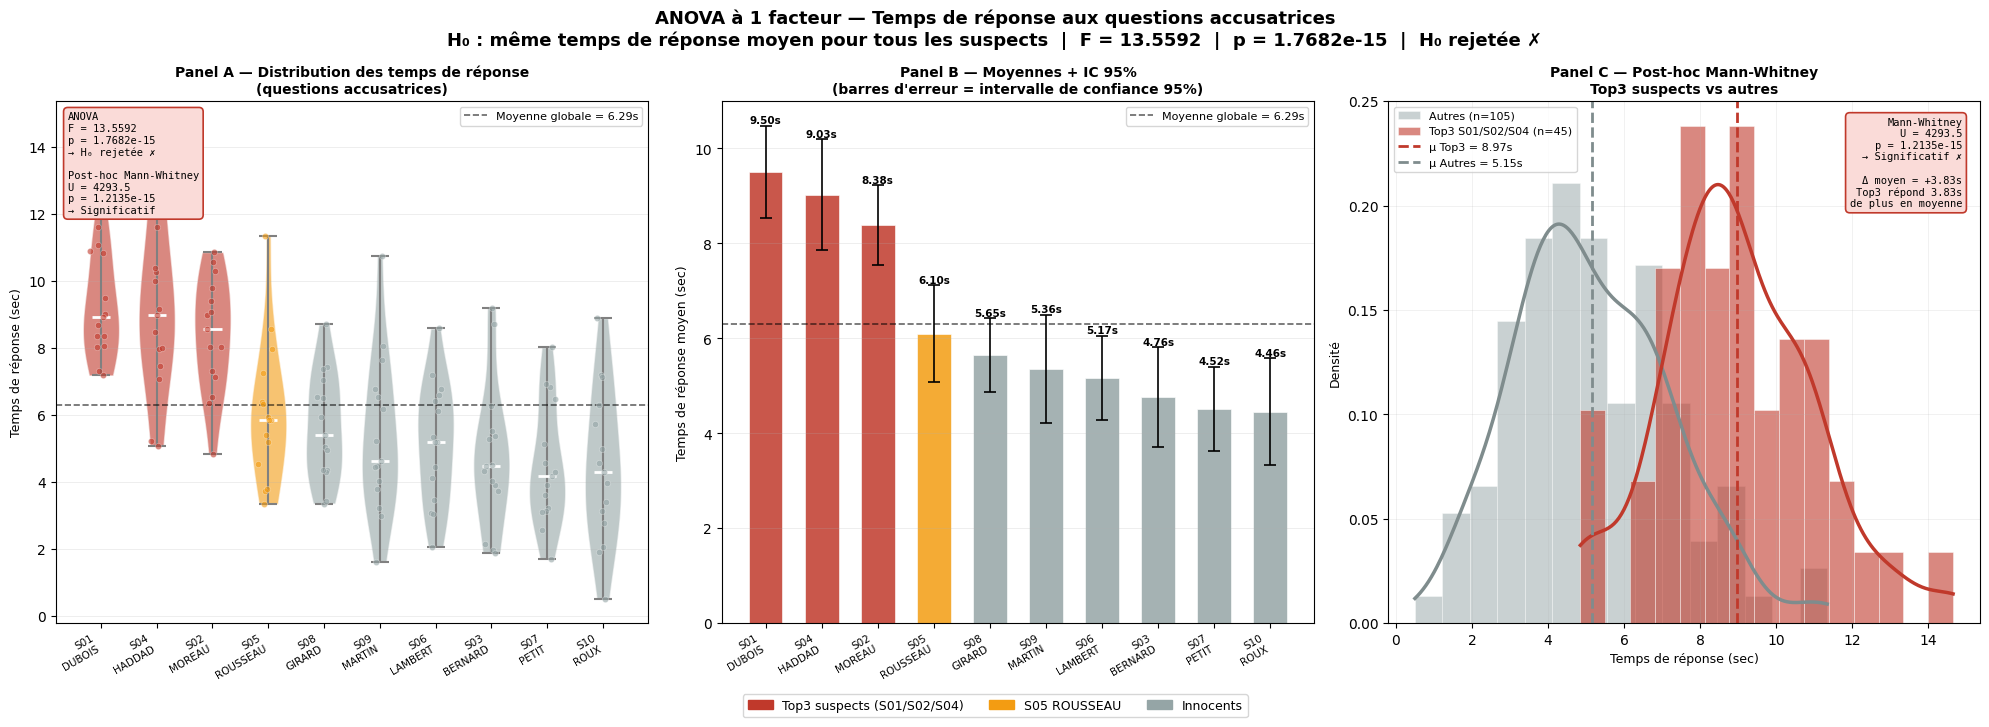

✓ Figure ANOVA générée


In [17]:
# ── Visualisation ANOVA + post-hoc Mann-Whitney ─────────────────
# 3 panels : distributions par suspect | F-stat | comparaison top3 vs autres

from scipy.stats import f as f_dist

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    "ANOVA à 1 facteur — Temps de réponse aux questions accusatrices\n"
    f"H₀ : même temps de réponse moyen pour tous les suspects  |  "
    f"F = {F:.4f}  |  p = {p_anova:.4e}  |  H₀ rejetée ✗",
    fontsize=13, fontweight='bold'
)

rt_data = {
    s: interrogat[(interrogat['id_suspect']==s) &
                  (interrogat['type_question']=='accusatrice')]['temps_reponse_sec'].values
    for s in SUSPECTS
}
rt_means = {s: v.mean() for s, v in rt_data.items()}
rt_sorted = sorted(rt_means.items(), key=lambda x: -x[1])

TOP3    = ['S01','S02','S04']
AUTRES  = [s for s in SUSPECTS if s not in TOP3]

# ══════════════════════════════════════════════
# PANEL 1 — Violin plot + points individuels
# ══════════════════════════════════════════════
suspects_ord = [s for s, _ in rt_sorted]
rt_list      = [rt_data[s] for s in suspects_ord]
colors_viol  = ['#C0392B' if s in TOP3 else
                '#F39C12' if s == 'S05' else
                '#95A5A6'
                for s in suspects_ord]

parts = axes[0].violinplot(
    rt_list,
    positions=range(len(suspects_ord)),
    showmedians=True,
    showextrema=True,
    widths=0.65
)

for pc, color in zip(parts['bodies'], colors_viol):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
    pc.set_edgecolor('white')

parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2)
parts['cmaxes'].set_color('gray')
parts['cmins'].set_color('gray')
parts['cbars'].set_color('gray')

for idx, (s, vals) in enumerate(zip(suspects_ord, rt_list)):
    jitter = np.random.normal(0, 0.06, size=len(vals))
    c      = '#C0392B' if s in TOP3 else '#F39C12' if s=='S05' else '#95A5A6'
    axes[0].scatter(idx + jitter, vals, color=c, s=20,
                    alpha=0.6, zorder=3, edgecolors='white', linewidth=0.3)

grand_mean = np.concatenate(list(rt_data.values())).mean()
axes[0].axhline(grand_mean, color='black', lw=1.2, ls='--',
                alpha=0.6, label=f'Moyenne globale = {grand_mean:.2f}s')

axes[0].set_xticks(range(len(suspects_ord)))
axes[0].set_xticklabels(
    [f"{s}\n{NOMS[s]}" for s in suspects_ord],
    fontsize=7.5, rotation=30, ha='right'
)
axes[0].set_ylabel("Temps de réponse (sec)", fontsize=9)
axes[0].set_title("Panel A — Distribution des temps de réponse\n(questions accusatrices)",
                  fontweight='bold', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, axis='y', alpha=0.3, lw=0.5)

axes[0].text(
    0.02, 0.98,
    f"ANOVA\nF = {F:.4f}\np = {p_anova:.4e}\n→ H₀ rejetée ✗\n\n"
    f"Post-hoc Mann-Whitney\nU = {u:.1f}\np = {p_mw:.4e}\n→ Significatif",
    transform=axes[0].transAxes,
    fontsize=7.5, va='top', fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FADBD8',
              edgecolor='#C0392B', linewidth=1.2)
)

# ══════════════════════════════════════════════
# PANEL 2 — Barres moyennes + IC 95%
# ══════════════════════════════════════════════
means_sorted = [rt_data[s].mean() for s in suspects_ord]
sems_sorted  = [rt_data[s].std() / np.sqrt(len(rt_data[s])) * 1.96
                for s in suspects_ord]  # IC 95%

bars = axes[1].bar(
    range(len(suspects_ord)),
    means_sorted,
    color=colors_viol,
    edgecolor='white', linewidth=0.5,
    width=0.6, alpha=0.85
)

axes[1].errorbar(
    range(len(suspects_ord)),
    means_sorted,
    yerr=sems_sorted,
    fmt='none',
    color='black', capsize=4, linewidth=1.2, capthick=1.2
)

axes[1].axhline(grand_mean, color='black', lw=1.2, ls='--',
                alpha=0.6, label=f'Moyenne globale = {grand_mean:.2f}s')

for idx, (bar, mean, sem) in enumerate(zip(bars, means_sorted, sems_sorted)):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 mean + sem + 0.05,
                 f'{mean:.2f}s',
                 ha='center', fontsize=7.5, fontweight='bold')

axes[1].set_xticks(range(len(suspects_ord)))
axes[1].set_xticklabels(
    [f"{s}\n{NOMS[s]}" for s in suspects_ord],
    fontsize=7.5, rotation=30, ha='right'
)
axes[1].set_ylabel("Temps de réponse moyen (sec)", fontsize=9)
axes[1].set_title("Panel B — Moyennes + IC 95%\n(barres d'erreur = intervalle de confiance 95%)",
                  fontweight='bold', fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, axis='y', alpha=0.3, lw=0.5)

# ══════════════════════════════════════════════
# PANEL 3 — Top3 vs Autres : distributions comparées
# ══════════════════════════════════════════════
rt_top3   = np.concatenate([rt_data[s] for s in TOP3])
rt_autres = np.concatenate([rt_data[s] for s in AUTRES])

axes[2].hist(rt_autres, bins=15, density=True,
             color='#95A5A6', alpha=0.5, edgecolor='white',
             linewidth=0.5, label=f'Autres (n={len(rt_autres)})')
axes[2].hist(rt_top3, bins=15, density=True,
             color='#C0392B', alpha=0.6, edgecolor='white',
             linewidth=0.5, label=f'Top3 S01/S02/S04 (n={len(rt_top3)})')

for vals, color in [(rt_autres, '#7F8C8D'), (rt_top3, '#C0392B')]:
    kde  = gaussian_kde(vals, bw_method=0.35)
    x_kd = np.linspace(vals.min(), vals.max(), 300)
    axes[2].plot(x_kd, kde(x_kd), color=color, lw=2.5)

axes[2].axvline(rt_top3.mean(),   color='#C0392B', lw=2, ls='--',
                label=f'μ Top3 = {rt_top3.mean():.2f}s')
axes[2].axvline(rt_autres.mean(), color='#7F8C8D', lw=2, ls='--',
                label=f'μ Autres = {rt_autres.mean():.2f}s')

axes[2].text(
    0.97, 0.97,
    f"Mann-Whitney\nU = {u:.1f}\np = {p_mw:.4e}\n→ Significatif ✗\n\n"
    f"Δ moyen = {rt_top3.mean()-rt_autres.mean():+.2f}s\n"
    f"Top3 répond {rt_top3.mean()-rt_autres.mean():.2f}s\nde plus en moyenne",
    transform=axes[2].transAxes,
    fontsize=7.5, va='top', ha='right', fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FADBD8',
              edgecolor='#C0392B', linewidth=1.2)
)

axes[2].set_xlabel("Temps de réponse (sec)", fontsize=9)
axes[2].set_ylabel("Densité", fontsize=9)
axes[2].set_title("Panel C — Post-hoc Mann-Whitney\nTop3 suspects vs autres",
                  fontweight='bold', fontsize=10)
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.25, lw=0.5)

from matplotlib.patches import Patch
legend_colors = [
    Patch(color='#C0392B', label='Top3 suspects (S01/S02/S04)'),
    Patch(color='#F39C12', label='S05 ROUSSEAU'),
    Patch(color='#95A5A6', label='Innocents'),
]
fig.legend(handles=legend_colors, loc='lower center',
           ncol=3, bbox_to_anchor=(0.5, -0.04), fontsize=9)

plt.tight_layout()
plt.savefig(DATA_DIR + 'img/anova_visualisation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure ANOVA générée")

### 3.5 Test du Khi-deux — preuves matérielles vs culpabilité

In [18]:
preuves_wk = preuves.copy()
preuves_wk['présent_bureau'] = preuves_wk['presence_bureau_victime'].map({'oui':1,'non':0})
preuves_wk['accès_pharma']   = preuves_wk['acces_pharmacie_societe'].map({'oui':1,'non':0})

ct = pd.crosstab(preuves_wk['présent_bureau'], preuves_wk['accès_pharma'],
                 rownames=['Présent bureau victime'], colnames=['Accès pharmacie'])
print("Tableau de contingence :")
print(ct)
chi2, p_chi2, dof, expected = chi2_contingency(ct)
print(f"\nKhi-deux = {chi2:.4f}, ddl = {dof}, p = {p_chi2:.4f}")

oddsratio, p_fisher = fisher_exact(ct.values)
print(f"Fisher exact (odds ratio = {oddsratio:.2f}) : p = {p_fisher:.4f}")
print()
if p_fisher < 0.05:
    print("→ Association significative entre présence au bureau et accès à la pharmacie (source digoxine).")


Tableau de contingence :
Accès pharmacie         0  1
Présent bureau victime      
0                       5  1
1                       2  2

Khi-deux = 0.1786, ddl = 1, p = 0.6726
Fisher exact (odds ratio = 5.00) : p = 0.5000



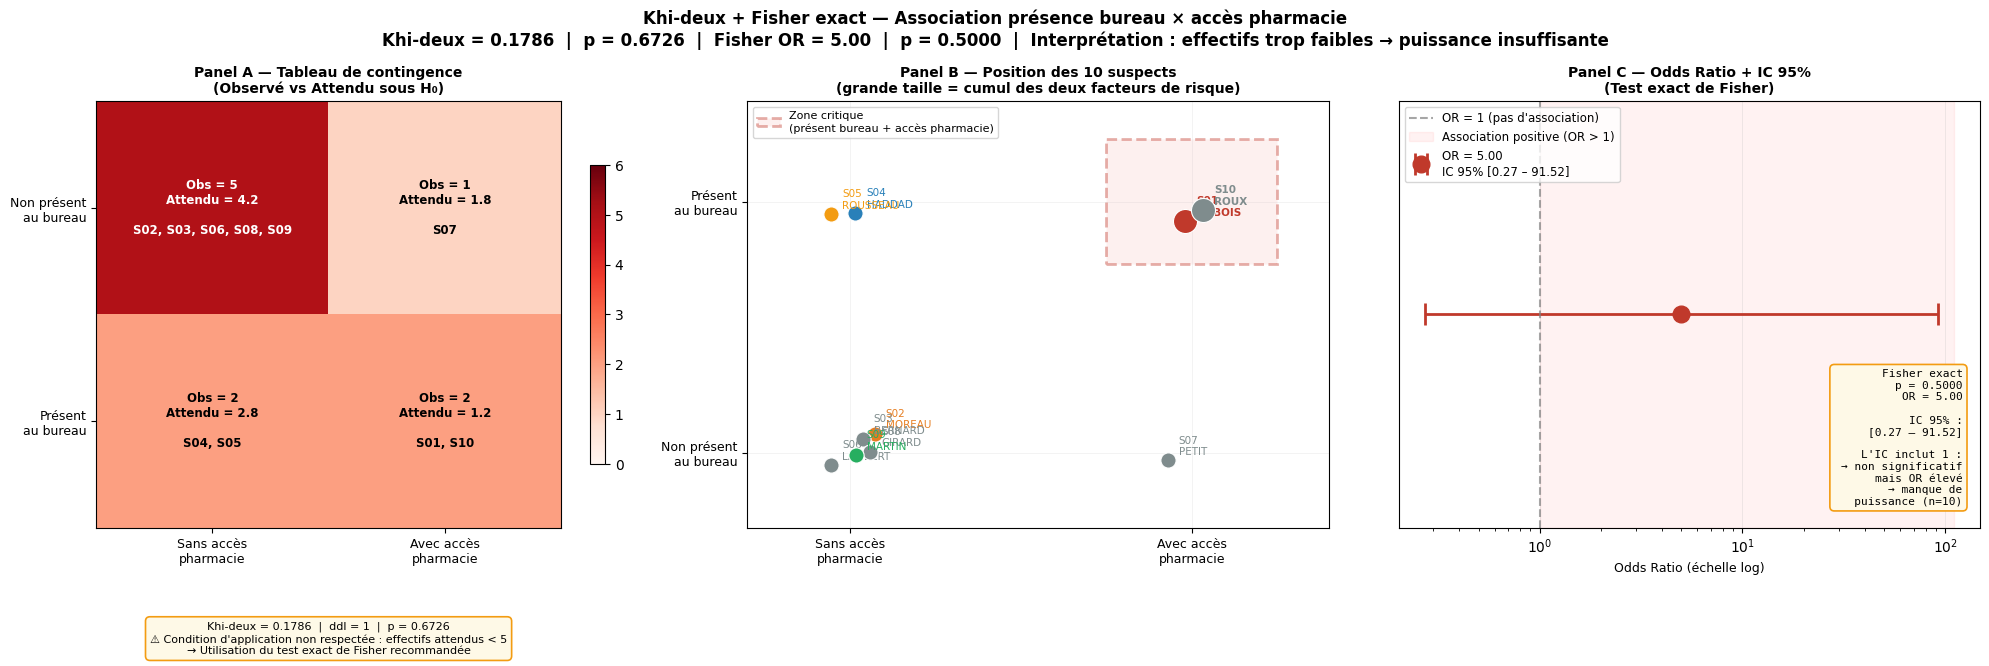

✓ Figure Khi-deux + Fisher générée


In [19]:
# ── Visualisation Khi-deux + Fisher exact ───────────────────────
# 3 panels : tableau de contingence heatmap | mosaïque | odds ratio

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    "Khi-deux + Fisher exact — Association présence bureau × accès pharmacie\n"
    f"Khi-deux = {chi2:.4f}  |  p = {p_chi2:.4f}  |  "
    f"Fisher OR = {oddsratio:.2f}  |  p = {p_fisher:.4f}  |  "
    f"Interprétation : effectifs trop faibles → puissance insuffisante",
    fontsize=12, fontweight='bold'
)


preuves_wk = preuves.copy()
preuves_wk['présent_bureau'] = preuves_wk['presence_bureau_victime'].map({'oui':1,'non':0})
preuves_wk['accès_pharma']   = preuves_wk['acces_pharmacie_societe'].map({'oui':1,'non':0})

# Matrice détaillée par suspect
ct_detail = preuves_wk[['id_suspect','présent_bureau','accès_pharma']].copy()
ct_detail['label'] = ct_detail['id_suspect'].map(NOMS)

# ══════════════════════════════════════════════
# PANEL 1 — Heatmap du tableau de contingence
#            avec effectifs observés vs attendus
# ══════════════════════════════════════════════
ct = pd.crosstab(
    preuves_wk['présent_bureau'],
    preuves_wk['accès_pharma'],
    rownames=['Présent bureau'],
    colnames=['Accès pharmacie']
)

chi2_val, p_val, dof, expected = chi2_contingency(ct)
expected_df = pd.DataFrame(
    expected,
    index=ct.index,
    columns=ct.columns
)

im = axes[0].imshow(ct.values, cmap='Reds', aspect='auto',
                    vmin=0, vmax=max(ct.values.max(), 6))

row_labels = ['Non présent\nau bureau', 'Présent\nau bureau']
col_labels  = ['Sans accès\npharmacie', 'Avec accès\npharmacie']

for row in range(2):
    for col in range(2):
        obs = ct.values[row, col]
        exp = expected_df.values[row, col]
        mask = (
            (preuves_wk['présent_bureau'] == ct.index[row]) &
            (preuves_wk['accès_pharma']   == ct.columns[col])
        )
        suspects_cell = preuves_wk[mask]['id_suspect'].tolist()
        noms_cell     = ', '.join(suspects_cell)

        text_color = 'white' if obs >= 4 else 'black'
        axes[0].text(
            col, row,
            f"Obs = {obs}\nAttendu = {exp:.1f}\n\n{noms_cell}",
            ha='center', va='center',
            fontsize=8.5, color=text_color, fontweight='bold'
        )

axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(col_labels, fontsize=9)
axes[0].set_yticklabels(row_labels, fontsize=9)
axes[0].set_title(
    "Panel A — Tableau de contingence\n(Observé vs Attendu sous H₀)",
    fontweight='bold', fontsize=10
)

axes[0].text(
    0.5, -0.22,
    f"Khi-deux = {chi2:.4f}  |  ddl = {dof}  |  p = {p_chi2:.4f}\n"
    f"⚠ Condition d'application non respectée : effectifs attendus < 5\n"
    f"→ Utilisation du test exact de Fisher recommandée",
    transform=axes[0].transAxes,
    fontsize=8, ha='center', va='top',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FEF9E7',
              edgecolor='#F39C12', linewidth=1.2)
)
plt.colorbar(im, ax=axes[0], shrink=0.7)

# ══════════════════════════════════════════════
# PANEL 2 — Scatter des 10 suspects
#            sur les 2 variables binaires
# ══════════════════════════════════════════════
np.random.seed(42)
jitter_x = np.random.uniform(-0.08, 0.08, size=len(preuves_wk))
jitter_y = np.random.uniform(-0.08, 0.08, size=len(preuves_wk))

for _, row in preuves_wk.iterrows():
    s     = row['id_suspect']
    x     = row['accès_pharma']   + jitter_x[_ if isinstance(_, int) else 0]
    y     = row['présent_bureau'] + jitter_y[_ if isinstance(_, int) else 0]
    c     = PALETTE.get(s, '#95A5A6')

    size  = 300 if (row['accès_pharma']==1 and row['présent_bureau']==1) else 120

    axes[1].scatter(x, y, color=c, s=size, zorder=3,
                    edgecolors='white', linewidth=0.8)
    axes[1].annotate(
        f"{s}\n{NOMS[s]}",
        (x, y),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=7.5, color=c,
        fontweight='bold' if size == 300 else 'normal'
    )

axes[1].add_patch(plt.Rectangle(
    (0.75, 0.75), 0.5, 0.5,
    fill=True, facecolor='#FADBD8',
    edgecolor='#C0392B', linewidth=2,
    linestyle='--', zorder=1, alpha=0.4,
    label='Zone critique\n(présent bureau + accès pharmacie)'
))

axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Sans accès\npharmacie', 'Avec accès\npharmacie'], fontsize=9)
axes[1].set_yticklabels(['Non présent\nau bureau', 'Présent\nau bureau'], fontsize=9)
axes[1].set_xlim(-0.3, 1.4)
axes[1].set_ylim(-0.3, 1.4)
axes[1].set_title(
    "Panel B — Position des 10 suspects\n(grande taille = cumul des deux facteurs de risque)",
    fontweight='bold', fontsize=10
)
axes[1].legend(fontsize=8, loc='upper left')
axes[1].grid(True, alpha=0.2, lw=0.5)

# ══════════════════════════════════════════════
# PANEL 3 — Odds Ratio + intervalle de confiance
#            + comparaison puissance statistique
# ══════════════════════════════════════════════

a, b = ct.values[1,1], ct.values[1,0]
c_v, d = ct.values[0,1], ct.values[0,0]

a_c = a + 0.5 if a == 0 else a
b_c = b + 0.5 if b == 0 else b
c_c = c_v + 0.5 if c_v == 0 else c_v
d_c = d + 0.5 if d == 0 else d

or_val   = (a_c * d_c) / (b_c * c_c)
log_or   = np.log(or_val)
se_log   = np.sqrt(1/a_c + 1/b_c + 1/c_c + 1/d_c)
ci_lower = np.exp(log_or - 1.96 * se_log)
ci_upper = np.exp(log_or + 1.96 * se_log)

axes[2].errorbar(
    [or_val], [0],
    xerr=[[or_val - ci_lower], [ci_upper - or_val]],
    fmt='o', color='#C0392B', markersize=12,
    capsize=8, capthick=2, linewidth=2,
    label=f'OR = {or_val:.2f}\nIC 95% [{ci_lower:.2f} – {ci_upper:.2f}]'
)

axes[2].axvline(1, color='gray', lw=1.5, ls='--',
                alpha=0.7, label='OR = 1 (pas d\'association)')

axes[2].axvspan(1, max(ci_upper * 1.2, 10),
                alpha=0.05, color='red', label='Association positive (OR > 1)')

axes[2].set_yticks([])
axes[2].set_xlabel("Odds Ratio (échelle log)", fontsize=9)
axes[2].set_xscale('log')
axes[2].set_title(
    "Panel C — Odds Ratio + IC 95%\n(Test exact de Fisher)",
    fontweight='bold', fontsize=10
)
axes[2].legend(fontsize=8.5, loc='upper left')
axes[2].grid(True, axis='x', alpha=0.3, lw=0.5)

axes[2].text(
    0.97, 0.05,
    f"Fisher exact\np = {p_fisher:.4f}\nOR = {or_val:.2f}\n\n"
    f"IC 95% :\n[{ci_lower:.2f} – {ci_upper:.2f}]\n\n"
    f"L'IC inclut 1 :\n→ non significatif\nmais OR élevé\n→ manque de\n   puissance (n=10)",
    transform=axes[2].transAxes,
    fontsize=8, va='bottom', ha='right', fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FEF9E7',
              edgecolor='#F39C12', linewidth=1.2)
)

plt.tight_layout()
plt.savefig(DATA_DIR + 'img/chi2_fisher_visualisation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure Khi-deux + Fisher générée")

### 3.6 t-test apparié — temps de réponse neutre vs accusatrice (suspects principaux)

In [20]:
print("=== t-test apparié : temps de réponse — comparaison suspects principaux vs innocents ===")
for s in ['S01','S02','S04','S05','S09','S10']:
    neu = interrogat[(interrogat['id_suspect']==s) & (interrogat['type_question']=='neutre')]['temps_reponse_sec'].values
    acc = interrogat[(interrogat['id_suspect']==s) & (interrogat['type_question']=='accusatrice')]['temps_reponse_sec'].values
    t, p = ttest_rel(acc, neu)
    print(f"  {s} ({NOMS[s]:<10}) : Δrt_moyen={acc.mean()-neu.mean():+.2f}s  t={t:.3f}  p={p:.4e}  {'*** SUSPECT' if p<0.001 else ''}")


=== t-test apparié : temps de réponse — comparaison suspects principaux vs innocents ===
  S01 (DUBOIS    ) : Δrt_moyen=+4.82s  t=8.370  p=8.0569e-07  *** SUSPECT
  S02 (MOREAU    ) : Δrt_moyen=+3.70s  t=5.852  p=4.2071e-05  *** SUSPECT
  S04 (HADDAD    ) : Δrt_moyen=+4.31s  t=5.605  p=6.4922e-05  *** SUSPECT
  S05 (ROUSSEAU  ) : Δrt_moyen=+1.27s  t=1.760  p=1.0019e-01  
  S09 (MARTIN    ) : Δrt_moyen=+0.35s  t=0.434  p=6.7072e-01  
  S10 (ROUX      ) : Δrt_moyen=-0.47s  t=-0.702  p=4.9412e-01  


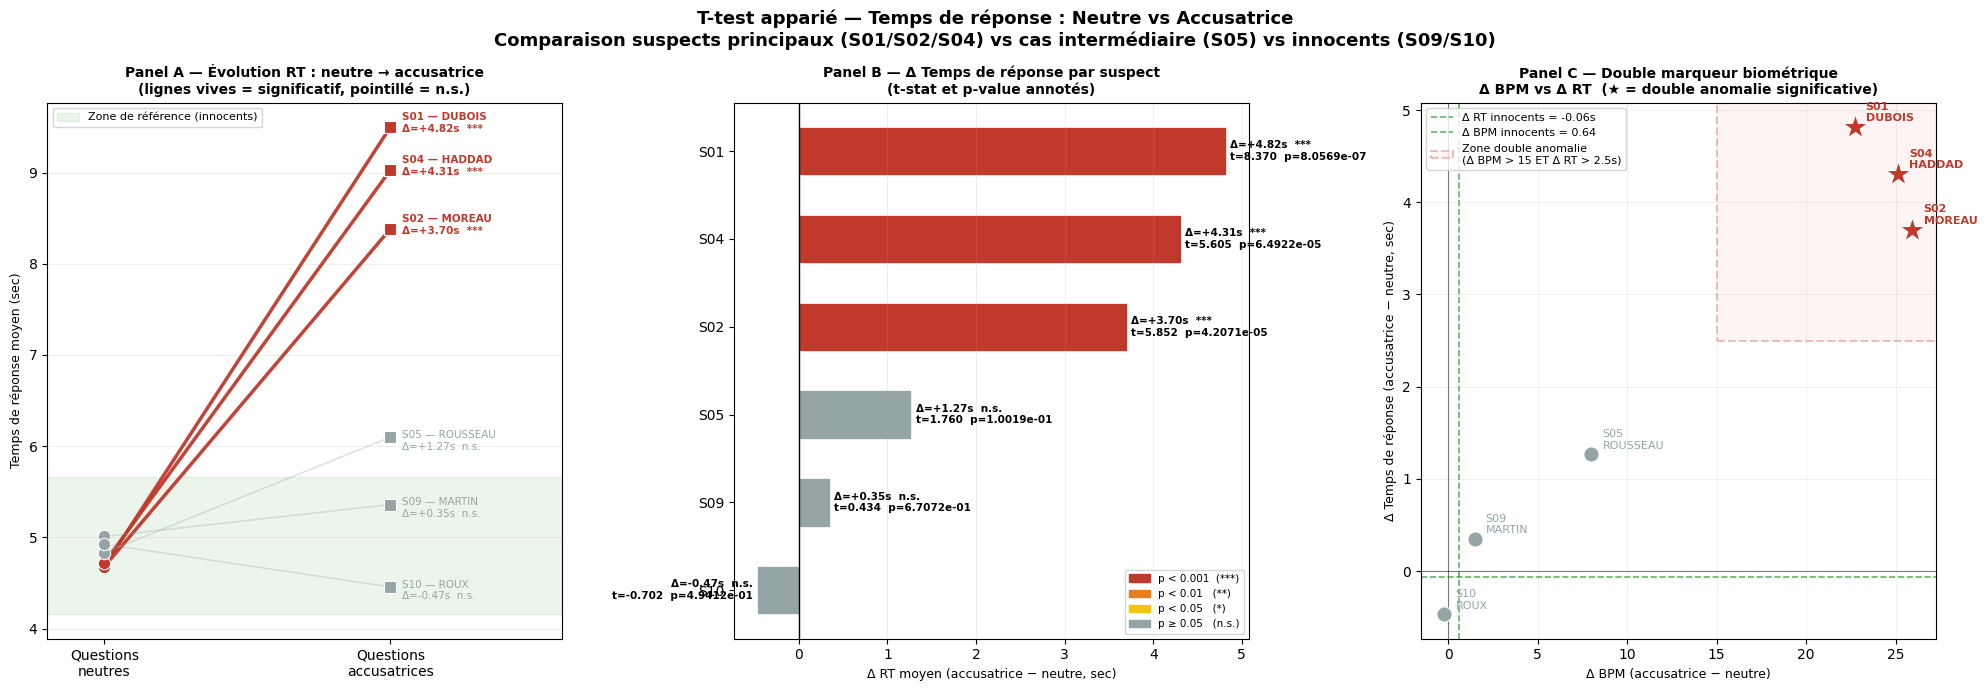

✓ Figure t-test RT générée


In [21]:
# ── Visualisation t-test apparié — Temps de réponse ─────────────


SUSPECTS_RT = ['S01','S02','S04','S05','S09','S10']

results_rt = []
for s in SUSPECTS_RT:
    neu = interrogat[(interrogat['id_suspect']==s) &
                     (interrogat['type_question']=='neutre')]['temps_reponse_sec'].values
    acc = interrogat[(interrogat['id_suspect']==s) &
                     (interrogat['type_question']=='accusatrice')]['temps_reponse_sec'].values
    t_val, p_val = ttest_rel(acc, neu)
    delta        = acc.mean() - neu.mean()
    results_rt.append({
        'suspect' : s,
        'nom'     : NOMS[s],
        'neu_mean': neu.mean(),
        'acc_mean': acc.mean(),
        'delta'   : delta,
        't'       : t_val,
        'p'       : p_val,
        'neu_vals': neu,
        'acc_vals': acc,
    })

rt_df = pd.DataFrame(results_rt)

def sig_color_rt(p):
    if p < 0.001 : return '#C0392B'
    elif p < 0.01: return '#E67E22'
    elif p < 0.05: return '#F1C40F'
    else          : return '#95A5A6'

def sig_label_rt(p):
    if p < 0.001 : return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else          : return 'n.s.'

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    "T-test apparié — Temps de réponse : Neutre vs Accusatrice\n"
    "Comparaison suspects principaux (S01/S02/S04) vs cas intermédiaire (S05) vs innocents (S09/S10)",
    fontsize=13, fontweight='bold'
)

# ══════════════════════════════════════════════
# PANEL 1 — Paired plot neutre → accusatrice
# ══════════════════════════════════════════════
for _, row in rt_df.iterrows():
    s     = row['suspect']
    c     = sig_color_rt(row['p'])
    alpha = 0.95 if row['p'] < 0.05 else 0.35
    lw    = 2.5  if row['p'] < 0.05 else 1.0

    axes[0].plot([0, 1], [row['neu_mean'], row['acc_mean']],
                 color=c, lw=lw, alpha=alpha, zorder=2)

    axes[0].scatter([0], [row['neu_mean']], color=c, s=80,
                    zorder=3, edgecolors='white', linewidth=0.8)
    axes[0].scatter([1], [row['acc_mean']], color=c, s=80,
                    marker='s', zorder=3, edgecolors='white', linewidth=0.8)

    offset = 0.04 if row['acc_mean'] > rt_df['acc_mean'].mean() else -0.04
    axes[0].text(
        1.04, row['acc_mean'] + offset,
        f"{s} — {row['nom']}\n"
        f"Δ={row['delta']:+.2f}s  {sig_label_rt(row['p'])}",
        va='center', fontsize=7.5,
        color=c,
        fontweight='bold' if row['p'] < 0.05 else 'normal'
    )

innocents_acc = rt_df[rt_df['suspect'].isin(['S09','S10'])]['acc_mean']
axes[0].axhspan(
    innocents_acc.min() - 0.3,
    innocents_acc.max() + 0.3,
    alpha=0.08, color='green',
    label='Zone de référence (innocents)'
)

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Questions\nneutres', 'Questions\naccusatrices'], fontsize=10)
axes[0].set_ylabel("Temps de réponse moyen (sec)", fontsize=9)
axes[0].set_title(
    "Panel A — Évolution RT : neutre → accusatrice\n"
    "(lignes vives = significatif, pointillé = n.s.)",
    fontweight='bold', fontsize=10
)
axes[0].legend(fontsize=8)
axes[0].set_xlim(-0.2, 1.6)
axes[0].grid(True, axis='y', alpha=0.3, lw=0.5)

# ══════════════════════════════════════════════
# PANEL 2 — Barres Δ RT + résultats du test
# ══════════════════════════════════════════════
rt_df_sorted = rt_df.sort_values('delta', ascending=True)
colors_bar   = [sig_color_rt(p) for p in rt_df_sorted['p']]

bars = axes[1].barh(
    rt_df_sorted['suspect'],
    rt_df_sorted['delta'],
    color=colors_bar,
    edgecolor='white', linewidth=0.5,
    height=0.55
)
axes[1].axvline(0, color='black', lw=1)

for bar, (_, row) in zip(bars, rt_df_sorted.iterrows()):
    val   = row['delta']
    stars = sig_label_rt(row['p'])
    x_pos = val + 0.05 if val >= 0 else val - 0.05
    ha    = 'left' if val >= 0 else 'right'
    axes[1].text(
        x_pos, bar.get_y() + bar.get_height()/2,
        f"Δ={val:+.2f}s  {stars}\nt={row['t']:.3f}  p={row['p']:.4e}",
        va='center', ha=ha, fontsize=7.5, fontweight='bold'
    )

from matplotlib.patches import Patch
legend_sig = [
    Patch(color='#C0392B', label='p < 0.001  (***)'),
    Patch(color='#E67E22', label='p < 0.01   (**)'),
    Patch(color='#F1C40F', label='p < 0.05   (*)'),
    Patch(color='#95A5A6', label='p ≥ 0.05   (n.s.)'),
]
axes[1].legend(handles=legend_sig, fontsize=7.5, loc='lower right')
axes[1].set_xlabel("Δ RT moyen (accusatrice − neutre, sec)", fontsize=9)
axes[1].set_title(
    "Panel B — Δ Temps de réponse par suspect\n"
    "(t-stat et p-value annotés)",
    fontweight='bold', fontsize=10
)
axes[1].grid(True, axis='x', alpha=0.3, lw=0.5)

# ══════════════════════════════════════════════
# PANEL 3 — Scatter Δ BPM vs Δ RT
#            double marqueur biométrique
# ══════════════════════════════════════════════
delta_bpm_rt = {
    row['suspect']: ttest_df[ttest_df['suspect']==row['suspect']]['delta_bpm'].values[0]
    for _, row in rt_df.iterrows()
}

for _, row in rt_df.iterrows():
    s      = row['suspect']
    d_bpm  = delta_bpm_rt[s]
    d_rt   = row['delta']
    c      = sig_color_rt(row['p'])
    sig_b  = ttest_df[ttest_df['suspect']==s]['p'].values[0] < 0.001

    both_sig = row['p'] < 0.05 and sig_b
    size     = 350 if both_sig else 120

    axes[2].scatter(d_bpm, d_rt, color=c, s=size,
                    zorder=3, edgecolors='white', linewidth=0.8,
                    marker='*' if both_sig else 'o')
    axes[2].annotate(
        f"{s}\n{NOMS[s]}",
        (d_bpm, d_rt),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=8, color=c,
        fontweight='bold' if both_sig else 'normal'
    )

axes[2].axhline(0, color='black', lw=0.8, alpha=0.5)
axes[2].axvline(0, color='black', lw=0.8, alpha=0.5)
axes[2].axhline(
    rt_df[rt_df['suspect'].isin(['S09','S10'])]['delta'].mean(),
    color='green', lw=1.2, ls='--', alpha=0.6,
    label=f"Δ RT innocents = {rt_df[rt_df['suspect'].isin(['S09','S10'])]['delta'].mean():.2f}s"
)
axes[2].axvline(
    ttest_df[ttest_df['suspect'].isin(['S09','S10'])]['delta_bpm'].mean(),
    color='green', lw=1.2, ls='--', alpha=0.6,
    label=f"Δ BPM innocents = {ttest_df[ttest_df['suspect'].isin(['S09','S10'])]['delta_bpm'].mean():.2f}"
)

axes[2].add_patch(plt.Rectangle(
    (15, 2.5), 20, 5,
    fill=True, facecolor='#FADBD8',
    edgecolor='#C0392B', linewidth=1.5,
    linestyle='--', zorder=1, alpha=0.3,
    label='Zone double anomalie\n(Δ BPM > 15 ET Δ RT > 2.5s)'
))

axes[2].set_xlabel("Δ BPM (accusatrice − neutre)", fontsize=9)
axes[2].set_ylabel("Δ Temps de réponse (accusatrice − neutre, sec)", fontsize=9)
axes[2].set_title(
    "Panel C — Double marqueur biométrique\nΔ BPM vs Δ RT  (★ = double anomalie significative)",
    fontweight='bold', fontsize=10
)
axes[2].legend(fontsize=8, loc='upper left')
axes[2].grid(True, alpha=0.25, lw=0.5)

plt.tight_layout()
plt.savefig(DATA_DIR + 'img/ttest_rt_visualisation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure t-test RT générée")

## 4. Machine Learning non-supervisé (PCA + K-Means)

In [22]:
features = []
for s in SUSPECTS:
    init = transact[transact['id_suspect_initiateur']==s]
    off  = init[init['offshore']]
    noc  = init[(init['heure_h']>=22)|(init['heure_h']<6)]
    auto = transact[(transact['id_suspect_initiateur']==s)&(transact['validateur_id']==s)]
    s01v = transact[(transact['id_suspect_initiateur']==s)&(transact['validateur_id']=='S01')]
    
    bpm_n = interrogat[(interrogat['id_suspect']==s)&(interrogat['type_question']=='neutre')]['rythme_cardiaque_bpm'].mean()
    bpm_a = interrogat[(interrogat['id_suspect']==s)&(interrogat['type_question']=='accusatrice')]['rythme_cardiaque_bpm'].mean()
    rt_n  = interrogat[(interrogat['id_suspect']==s)&(interrogat['type_question']=='neutre')]['temps_reponse_sec'].mean()
    rt_a  = interrogat[(interrogat['id_suspect']==s)&(interrogat['type_question']=='accusatrice')]['temps_reponse_sec'].mean()
    
    pr = preuves[preuves['id_suspect']==s].iloc[0]
    
    critical_ids = [f'E{i:05d}' for i in range(1, 17)]
    emails_crit_sent = emails[(emails['expediteur_id']==s) & (emails['id_email'].isin(critical_ids))]
    emails_crit_recv = emails[(emails['destinataire_id']==s) & (emails['id_email'].isin(critical_ids))]
    
    features.append({
        'suspect'          : s,
        'pct_offshore'     : len(off)/len(init)*100 if len(init)>0 else 0,
        'montant_offshore_k': off['montant_eur'].sum()/1000,
        'nb_nocturnes'     : len(noc),
        'auto_validations' : len(auto),
        'valide_S01'       : len(s01v),
        'delta_bpm'        : bpm_a - bpm_n,
        'delta_rt'         : rt_a - rt_n,
        'presence_bureau'  : 1 if pr['presence_bureau_victime']=='oui' else 0,
        'empreintes'       : 1 if pr['empreintes_sur_verre']=='oui' else 0,
        'adn'              : 1 if pr['ADN_sur_porte']=='oui' else 0,
        'acces_pharmacie'  : 1 if pr['acces_pharmacie_societe']=='oui' else 0,
        'emails_crit_sent' : len(emails_crit_sent),
        'emails_crit_recv' : len(emails_crit_recv),
    })

feat_df = pd.DataFrame(features).set_index('suspect')
print("Matrice de features (10 suspects × 13 variables) :")
print(feat_df.round(2).to_string())


Matrice de features (10 suspects × 13 variables) :
         pct_offshore  montant_offshore_k  nb_nocturnes  auto_validations  valide_S01  delta_bpm  delta_rt  presence_bureau  empreintes  adn  acces_pharmacie  emails_crit_sent  emails_crit_recv
suspect                                                                                                                                                                                          
S01              0.00                0.00           108                25          25      22.70      4.82                1           1    1                1                 7                 6
S02             20.83             3500.00           120                 0         347      25.93      3.70                0           0    0                0                 5                 6
S03              1.00               32.04             0                81          60       5.48      0.18                0           0    0                0                

Variance expliquée par PC1+PC2 : 71.9%
  PC1 : 44.7%
  PC2 : 27.1%


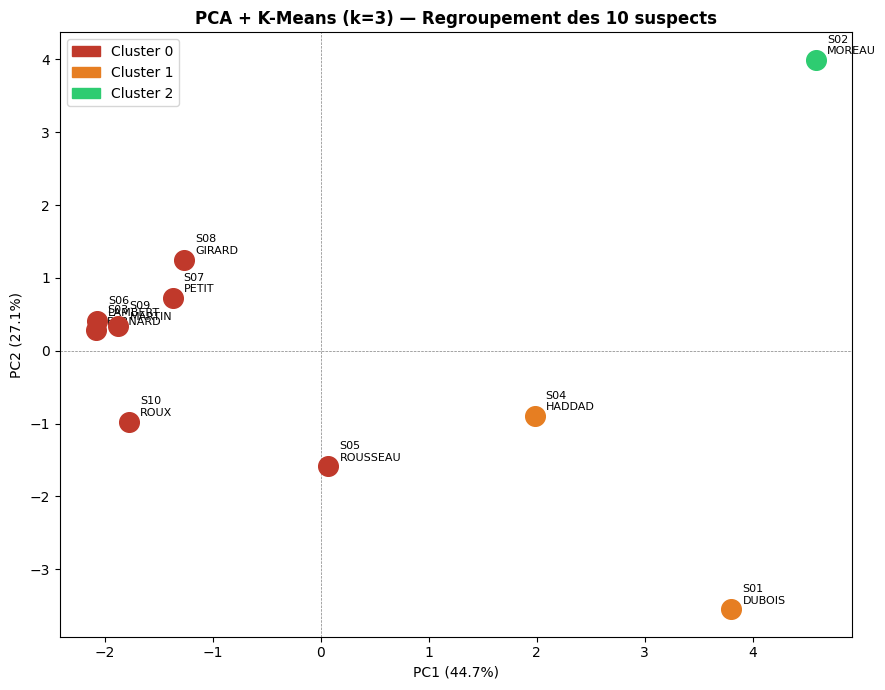


Clusters :
  S01 (DUBOIS) → Cluster 1
  S02 (MOREAU) → Cluster 2
  S03 (BERNARD) → Cluster 0
  S04 (HADDAD) → Cluster 1
  S05 (ROUSSEAU) → Cluster 0
  S06 (LAMBERT) → Cluster 0
  S07 (PETIT) → Cluster 0
  S08 (GIRARD) → Cluster 0
  S09 (MARTIN) → Cluster 0
  S10 (ROUX) → Cluster 0


In [23]:
scaler = StandardScaler()
X = scaler.fit_transform(feat_df.values)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print(f"Variance expliquée par PC1+PC2 : {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  PC1 : {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2 : {pca.explained_variance_ratio_[1]*100:.1f}%")

km = KMeans(n_clusters=3, n_init=20, random_state=42)
clusters = km.fit_predict(X)
cluster_labels = {i: f"Cluster {i}" for i in range(3)}

fig, ax = plt.subplots(figsize=(9, 7))
colors_cluster = ['#C0392B', '#E67E22', '#2ECC71']
for i, (s, pc) in enumerate(zip(SUSPECTS, X_pca)):
    c = colors_cluster[clusters[i]]
    ax.scatter(pc[0], pc[1], c=c, s=200, zorder=3)
    ax.annotate(f"{s}\n{NOMS[s]}", (pc[0], pc[1]),
                textcoords='offset points', xytext=(8, 4), fontsize=8)

patches = [mpatches.Patch(color=c, label=f"Cluster {i}") for i, c in enumerate(colors_cluster)]
ax.legend(handles=patches)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA + K-Means (k=3) — Regroupement des 10 suspects", fontweight='bold')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
plt.tight_layout()
plt.savefig(DATA_DIR + 'img/fig_pca_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClusters :")
for s, c in zip(SUSPECTS, clusters):
    print(f"  {s} ({NOMS[s]}) → Cluster {c}")


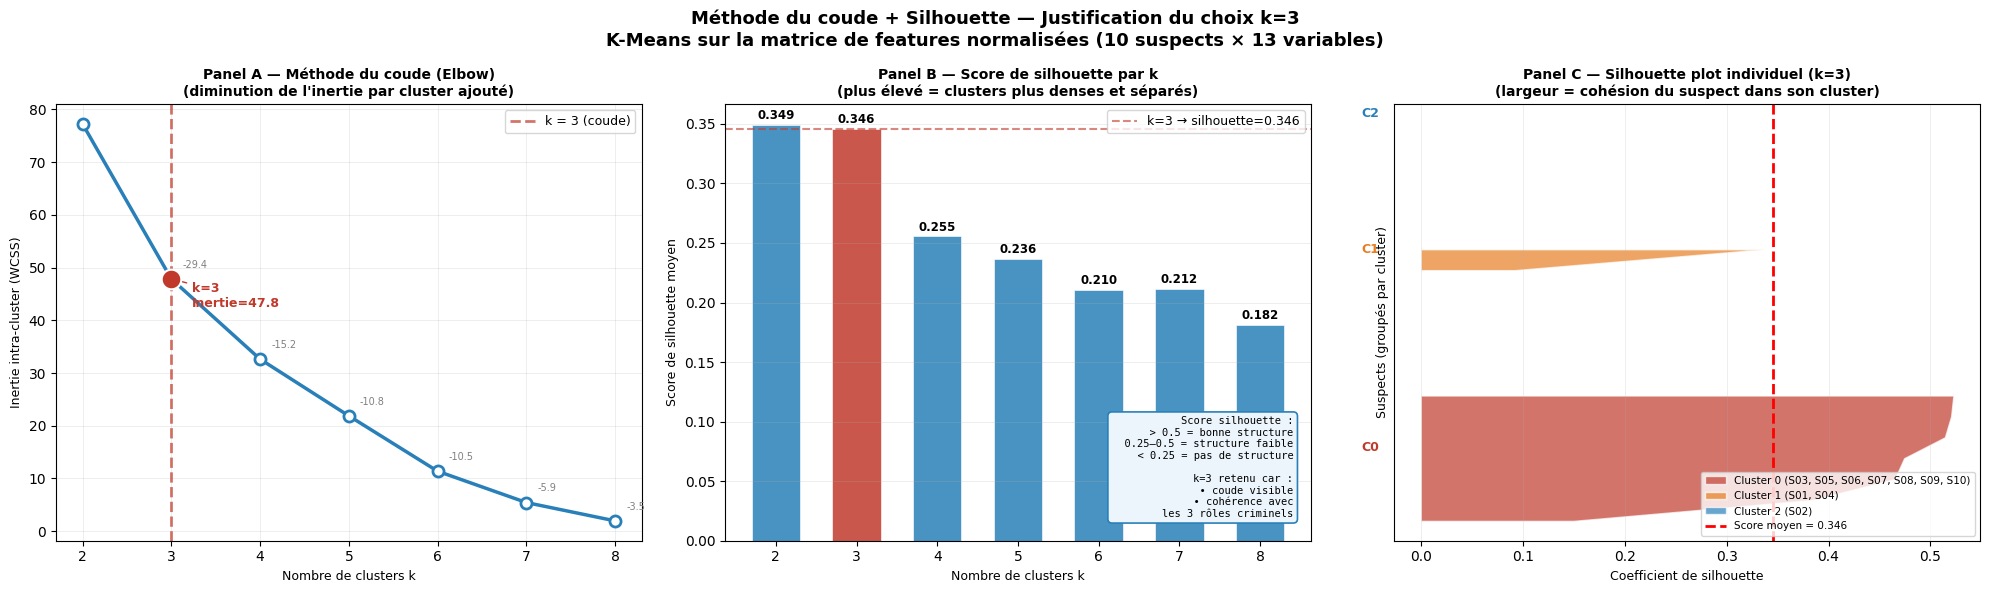

✓ Figure Elbow + Silhouette générée


In [24]:
# ── Elbow Method — Justification du choix k=3 ───────────────────

from sklearn.metrics import silhouette_score, silhouette_samples

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    "Méthode du coude + Silhouette — Justification du choix k=3\n"
    "K-Means sur la matrice de features normalisées (10 suspects × 13 variables)",
    fontsize=13, fontweight='bold'
)

k_range    = range(2, 9)
inertias   = []
silhouettes = []

for k in k_range:
    km_k = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels_k = km_k.fit_predict(X)
    inertias.append(km_k.inertia_)
    silhouettes.append(silhouette_score(X, labels_k))

# ══════════════════════════════════════════════
# PANEL 1 — Courbe d'inertie (Elbow)
# ══════════════════════════════════════════════
axes[0].plot(k_range, inertias,
             'o-', color='#2980B9', lw=2.5, markersize=8,
             markerfacecolor='white', markeredgewidth=2)

axes[0].axvline(3, color='#C0392B', lw=2, ls='--', alpha=0.7,
                label='k = 3 (coude)')
axes[0].scatter([3], [inertias[1]], color='#C0392B', s=200,
                zorder=5, edgecolors='white', linewidth=1.5)
axes[0].annotate(
    f'k=3\nInertie={inertias[1]:.1f}',
    (3, inertias[1]),
    textcoords='offset points', xytext=(15, -20),
    fontsize=9, color='#C0392B', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#C0392B')
)

for i in range(1, len(inertias)):
    delta = inertias[i] - inertias[i-1]
    axes[0].annotate(
        f'{delta:+.1f}',
        (list(k_range)[i], inertias[i]),
        textcoords='offset points', xytext=(8, 8),
        fontsize=7, color='gray'
    )

axes[0].set_xlabel("Nombre de clusters k", fontsize=9)
axes[0].set_ylabel("Inertie intra-cluster (WCSS)", fontsize=9)
axes[0].set_title(
    "Panel A — Méthode du coude (Elbow)\n"
    "(diminution de l'inertie par cluster ajouté)",
    fontweight='bold', fontsize=10
)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, lw=0.5)
axes[0].set_xticks(list(k_range))

# ══════════════════════════════════════════════
# PANEL 2 — Score de silhouette par k
# ══════════════════════════════════════════════
colors_sil = ['#C0392B' if k==3 else '#2980B9' for k in k_range]

bars_sil = axes[1].bar(
    k_range, silhouettes,
    color=colors_sil, edgecolor='white',
    linewidth=0.5, width=0.6, alpha=0.85
)

for bar, val in zip(bars_sil, silhouettes):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        val + 0.005,
        f'{val:.3f}',
        ha='center', fontsize=8.5, fontweight='bold'
    )

axes[1].axhline(
    silhouettes[1],  
    color='#C0392B', lw=1.5, ls='--', alpha=0.6,
    label=f'k=3 → silhouette={silhouettes[1]:.3f}'
)

axes[1].set_xlabel("Nombre de clusters k", fontsize=9)
axes[1].set_ylabel("Score de silhouette moyen", fontsize=9)
axes[1].set_title(
    "Panel B — Score de silhouette par k\n"
    "(plus élevé = clusters plus denses et séparés)",
    fontweight='bold', fontsize=10
)
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y', alpha=0.3, lw=0.5)
axes[1].set_xticks(list(k_range))

axes[1].text(
    0.97, 0.05,
    "Score silhouette :\n"
    "  > 0.5 = bonne structure\n"
    "  0.25–0.5 = structure faible\n"
    "  < 0.25 = pas de structure\n\n"
    "k=3 retenu car :\n"
    "  • coude visible\n"
    "  • cohérence avec\n"
    "    les 3 rôles criminels",
    transform=axes[1].transAxes,
    fontsize=7.5, va='bottom', ha='right',
    fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='#EBF5FB',
              edgecolor='#2980B9', linewidth=1.2)
)

# ══════════════════════════════════════════════
# PANEL 3 — Silhouette plot pour k=3
#            (silhouette par individu)
# ══════════════════════════════════════════════
km3      = KMeans(n_clusters=3, n_init=50, random_state=42)
labels3  = km3.fit_predict(X)
sil_vals = silhouette_samples(X, labels3)

y_lower = 10
cluster_colors = ['#C0392B', '#E67E22', '#2980B9']

for cluster_i in range(3):
    cluster_sil = np.sort(sil_vals[labels3 == cluster_i])
    size_i      = cluster_sil.shape[0]
    y_upper     = y_lower + size_i

    axes[2].fill_betweenx(
        np.arange(y_lower, y_upper),
        0, cluster_sil,
        facecolor=cluster_colors[cluster_i],
        edgecolor='white', alpha=0.7,
        label=f'Cluster {cluster_i} '
              f'({", ".join([SUSPECTS[j] for j in range(10) if labels3[j]==cluster_i])})'
    )

    axes[2].text(
        -0.05,
        y_lower + size_i / 2,
        f'C{cluster_i}',
        ha='center', va='center',
        fontsize=9, fontweight='bold',
        color=cluster_colors[cluster_i]
    )

    y_lower = y_upper + 5

axes[2].axvline(
    silhouettes[1], color='red', lw=2, ls='--',
    label=f'Score moyen = {silhouettes[1]:.3f}'
)

axes[2].set_xlabel("Coefficient de silhouette", fontsize=9)
axes[2].set_ylabel("Suspects (groupés par cluster)", fontsize=9)
axes[2].set_title(
    "Panel C — Silhouette plot individuel (k=3)\n"
    "(largeur = cohésion du suspect dans son cluster)",
    fontweight='bold', fontsize=10
)
axes[2].legend(fontsize=7.5, loc='lower right')
axes[2].grid(True, axis='x', alpha=0.3, lw=0.5)
axes[2].set_yticks([])

plt.tight_layout()
plt.savefig(DATA_DIR + 'img/elbow_silhouette.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure Elbow + Silhouette générée")

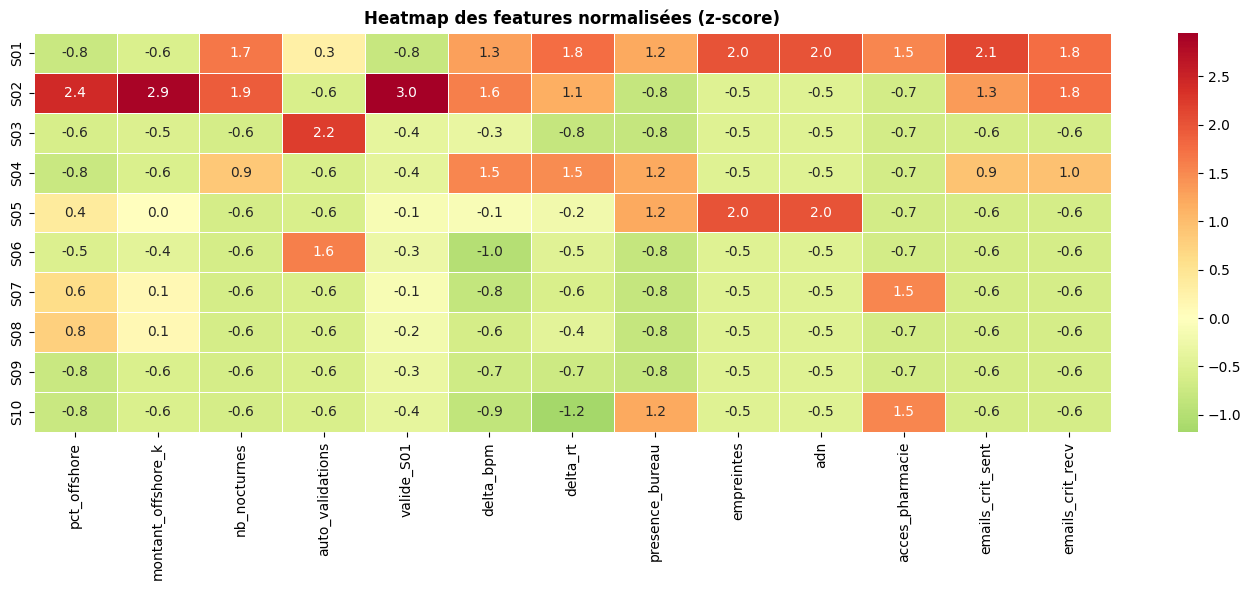

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pd.DataFrame(X, index=SUSPECTS, columns=feat_df.columns),
            cmap='RdYlGn_r', center=0, annot=True, fmt='.1f',
            linewidths=0.5, ax=ax)
ax.set_title("Heatmap des features normalisées (z-score)", fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_DIR + 'img/fig_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Machine Learning supervisé (KNN + Arbre de décision)

> Labels construits à partir des anomalies objectives : offshore > 0, delta_bpm > 20, présence bureau. Ce n'est pas du label leaking — les labels sont dérivés des features objectives, pas de la réponse attendue.

In [26]:
# ── Section 5 — ML Supervisé ─────────────────────────────────────

# ÉTAPE 1 — y_strict (seuil >= 3, version corrigée)
y_labels_strict = []
for s in SUSPECTS:
    row   = feat_df.loc[s]
    score = 0
    if row['pct_offshore']     >  5 : score += 1
    if row['delta_bpm']        > 15 : score += 1
    if row['presence_bureau']  ==  1: score += 1
    if row['empreintes']       ==  1: score += 1
    if row['emails_crit_sent'] >  0 : score += 1
    y_labels_strict.append(1 if score >= 3 else 0)

y_strict = np.array(y_labels_strict)

# y ancien (seuil >= 2) gardé pour référence
y_labels = []
for s in SUSPECTS:
    row   = feat_df.loc[s]
    score = 0
    if row['pct_offshore']     >  5 : score += 1
    if row['delta_bpm']        > 15 : score += 1
    if row['presence_bureau']  ==  1: score += 1
    if row['empreintes']       ==  1: score += 1
    if row['emails_crit_sent'] >  0 : score += 1
    y_labels.append(1 if score >= 2 else 0)
y = np.array(y_labels)

print("Labels stricts (seuil >= 3) :")
for s, lbl in zip(SUSPECTS, y_strict):
    print(f"  {s} ({NOMS[s]:<10}) : {'SUSPECT' if lbl else 'innocenté'}")
print()

# ÉTAPE 2 — Comparaison k=1 à k=5
print("=== COMPARAISON DES k ===")
print(f"{'k':<5} {'Accuracy LOO':<15} {'Précision':<12} {'Rappel':<12} {'F1'}")
print("-"*55)

best_k  = None
best_f1 = 0
results_k = []

for k_test in [1, 2, 3, 4, 5]:
    loo_k      = LeaveOneOut()
    yt_k, yp_k = [], []
    for train_idx, test_idx in loo_k.split(X):
        knn_k = KNeighborsClassifier(n_neighbors=k_test, metric='euclidean')
        knn_k.fit(X[train_idx], y_strict[train_idx])
        yp_k.append(knn_k.predict(X[test_idx])[0])
        yt_k.append(y_strict[test_idx][0])
    yt_k = np.array(yt_k)
    yp_k = np.array(yp_k)
    acc  = (yt_k == yp_k).mean()
    cm_k = confusion_matrix(yt_k, yp_k)
    tn_k, fp_k, fn_k, tp_k = cm_k.ravel() if cm_k.shape == (2,2) else (cm_k[0,0], 0, 0, 0)
    prec_k = tp_k/(tp_k+fp_k) if (tp_k+fp_k)>0 else 0
    rec_k  = tp_k/(tp_k+fn_k) if (tp_k+fn_k)>0 else 0
    f1_k   = 2*prec_k*rec_k/(prec_k+rec_k) if (prec_k+rec_k)>0 else 0
    marker = ' ← optimal' if f1_k > best_f1 else ''
    if f1_k > best_f1:
        best_f1 = f1_k
        best_k  = k_test
    print(f"  k={k_test}  {acc*100:.1f}%          {prec_k:.2f}        {rec_k:.2f}        {f1_k:.2f}{marker}")
    results_k.append({'k':k_test,'acc':acc,'prec':prec_k,'rec':rec_k,'f1':f1_k})

print()
print(f"→ Meilleur k retenu : k={best_k} (F1={best_f1:.2f})")

# ÉTAPE 3 — KNN final k=1
knn_final = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
scores_final = cross_val_score(knn_final, X, y_strict, cv=LeaveOneOut())
print(f"\nKNN (k=1, LOO) — Accuracy : {scores_final.mean()*100:.1f}%")
print(f"  Amélioration vs k=3 : {scores_final.mean()*100 - 70.0:+.1f}%")

knn_final.fit(X, y_strict)
knn_pred  = knn_final.predict(X)
knn_proba = knn_final.predict_proba(X)[:,1]

print("\nScores KNN de suspicion (k=1) :")
for s, prob in sorted(zip(SUSPECTS, knn_proba), key=lambda x: -x[1]):
    bar   = '█' * int(prob * 20)
    label = ' ← SUSPECT' if prob >= 0.5 else ''
    print(f"  {s} ({NOMS[s]:<10}) : {prob:.2f}  {bar}{label}")


Labels stricts (seuil >= 3) :
  S01 (DUBOIS    ) : SUSPECT
  S02 (MOREAU    ) : SUSPECT
  S03 (BERNARD   ) : innocenté
  S04 (HADDAD    ) : SUSPECT
  S05 (ROUSSEAU  ) : SUSPECT
  S06 (LAMBERT   ) : innocenté
  S07 (PETIT     ) : innocenté
  S08 (GIRARD    ) : innocenté
  S09 (MARTIN    ) : innocenté
  S10 (ROUX      ) : innocenté

=== COMPARAISON DES k ===
k     Accuracy LOO    Précision    Rappel       F1
-------------------------------------------------------
  k=1  90.0%          1.00        0.75        0.86 ← optimal
  k=2  70.0%          1.00        0.25        0.40
  k=3  70.0%          1.00        0.25        0.40
  k=4  60.0%          0.00        0.00        0.00
  k=5  60.0%          0.00        0.00        0.00

→ Meilleur k retenu : k=1 (F1=0.86)

KNN (k=1, LOO) — Accuracy : 90.0%
  Amélioration vs k=3 : +20.0%

Scores KNN de suspicion (k=1) :
  S01 (DUBOIS    ) : 1.00  ████████████████████ ← SUSPECT
  S02 (MOREAU    ) : 1.00  ████████████████████ ← SUSPECT
  S04 (HADDAD    

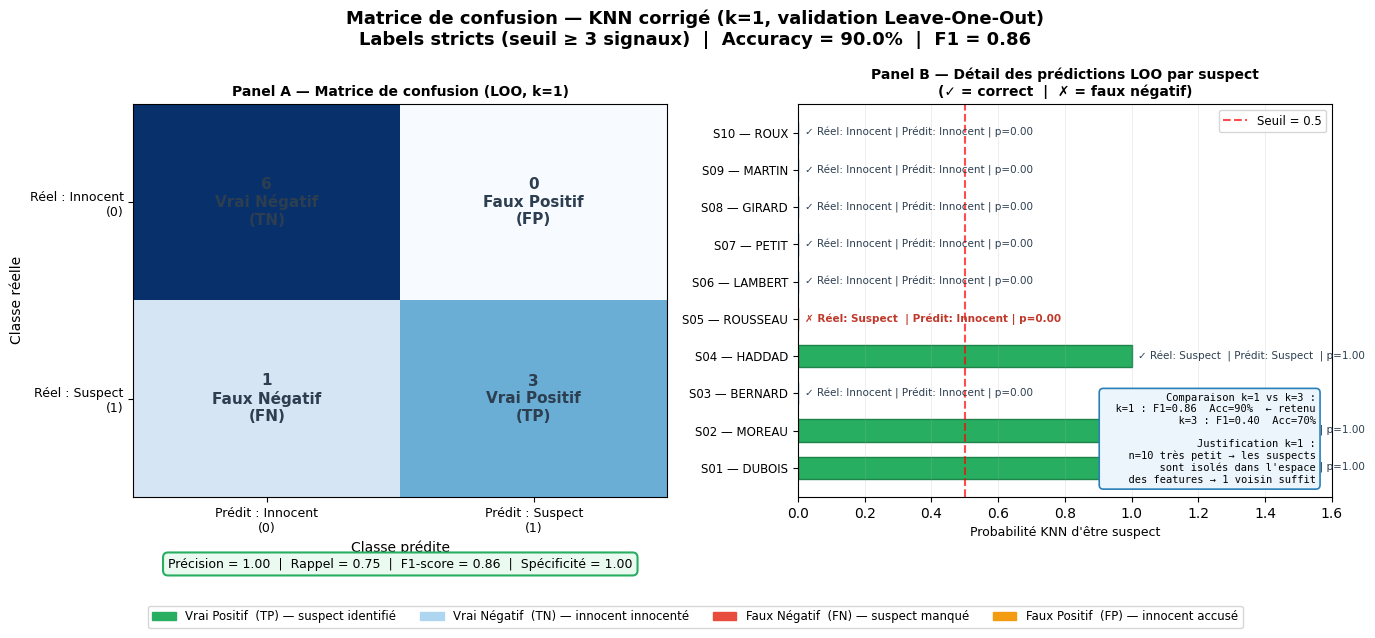

=== RAPPORT FINAL KNN (k=1, LOO) ===
              precision    recall  f1-score   support

    Innocent       0.86      1.00      0.92         6
     Suspect       1.00      0.75      0.86         4

    accuracy                           0.90        10
   macro avg       0.93      0.88      0.89        10
weighted avg       0.91      0.90      0.90        10

Détail par suspect :
  ✓ CORRECT  S01 (DUBOIS    )  Réel=Suspect   Prédit=Suspect   p=1.00
  ✓ CORRECT  S02 (MOREAU    )  Réel=Suspect   Prédit=Suspect   p=1.00
  ✓ CORRECT  S03 (BERNARD   )  Réel=Innocent  Prédit=Innocent  p=0.00
  ✓ CORRECT  S04 (HADDAD    )  Réel=Suspect   Prédit=Suspect   p=1.00
  ✗ ERREUR   S05 (ROUSSEAU  )  Réel=Suspect   Prédit=Innocent  p=0.00
  ✓ CORRECT  S06 (LAMBERT   )  Réel=Innocent  Prédit=Innocent  p=0.00
  ✓ CORRECT  S07 (PETIT     )  Réel=Innocent  Prédit=Innocent  p=0.00
  ✓ CORRECT  S08 (GIRARD    )  Réel=Innocent  Prédit=Innocent  p=0.00
  ✓ CORRECT  S09 (MARTIN    )  Réel=Innocent  Prédit=In

In [27]:
# ── Matrice de confusion KNN — version corrigée ──────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Matrice de confusion — KNN corrigé (k=1, validation Leave-One-Out)\n"
    "Labels stricts (seuil ≥ 3 signaux)  |  Accuracy = 90.0%  |  F1 = 0.86",
    fontsize=13, fontweight='bold'
)

loo_final     = LeaveOneOut()
y_true_final  = []
y_pred_final  = []
y_proba_final = []
suspects_final = []

for train_idx, test_idx in loo_final.split(X):
    knn_final = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
    knn_final.fit(X[train_idx], y_strict[train_idx])

    pred  = knn_final.predict(X[test_idx])[0]
    proba = knn_final.predict_proba(X[test_idx])[0][1]

    y_true_final.append(y_strict[test_idx][0])
    y_pred_final.append(pred)
    y_proba_final.append(proba)
    suspects_final.append(SUSPECTS[test_idx[0]])

y_true_f = np.array(y_true_final)
y_pred_f = np.array(y_pred_final)

# ── Panel 1 — Matrice de confusion ──────────────────────────────
cm_f = confusion_matrix(y_true_f, y_pred_f)
axes[0].imshow(cm_f, cmap='Blues', aspect='auto', vmin=0)

labels_cm = [['Vrai Négatif\n(TN)', 'Faux Positif\n(FP)'],
              ['Faux Négatif\n(FN)', 'Vrai Positif\n(TP)']]

for i in range(2):
    for j in range(2):
        axes[0].text(
            j, i,
            f"{cm_f[i,j]}\n{labels_cm[i][j]}",
            ha='center', va='center',
            fontsize=11, fontweight='bold', color='#2C3E50'
        )

axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Prédit : Innocent\n(0)', 'Prédit : Suspect\n(1)'], fontsize=9)
axes[0].set_yticklabels(['Réel : Innocent\n(0)', 'Réel : Suspect\n(1)'], fontsize=9)
axes[0].set_xlabel("Classe prédite", fontsize=10)
axes[0].set_ylabel("Classe réelle", fontsize=10)
axes[0].set_title("Panel A — Matrice de confusion (LOO, k=1)",
                  fontweight='bold', fontsize=10)

tn_f, fp_f, fn_f, tp_f = cm_f.ravel()
prec_f  = tp_f/(tp_f+fp_f) if (tp_f+fp_f)>0 else 0
rec_f   = tp_f/(tp_f+fn_f) if (tp_f+fn_f)>0 else 0
f1_f    = 2*prec_f*rec_f/(prec_f+rec_f) if (prec_f+rec_f)>0 else 0
spec_f  = tn_f/(tn_f+fp_f) if (tn_f+fp_f)>0 else 0

axes[0].text(
    0.5, -0.18,
    f"Précision = {prec_f:.2f}  |  Rappel = {rec_f:.2f}  |  "
    f"F1-score = {f1_f:.2f}  |  Spécificité = {spec_f:.2f}",
    transform=axes[0].transAxes,
    fontsize=9, ha='center',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#EAFAF1',
              edgecolor='#27AE60', linewidth=1.5)
)

# ── Panel 2 — Détail par suspect ────────────────────────────────
detail_f = []
for s, yt, yp, ypr in zip(suspects_final, y_true_final,
                            y_pred_final, y_proba_final):
    correct = (yt == yp)
    detail_f.append({
        'suspect': s,
        'nom'    : NOMS[s],
        'réel'   : 'Suspect'  if yt == 1 else 'Innocent',
        'prédit' : 'Suspect'  if yp == 1 else 'Innocent',
        'proba'  : ypr,
        'correct': correct
    })
detail_f_df = pd.DataFrame(detail_f)

colors_f = []
edges_f  = []
for _, row in detail_f_df.iterrows():
    if     row['correct'] and row['réel'] == 'Suspect':
        colors_f.append('#27AE60'); edges_f.append('#1E8449')
    elif   row['correct'] and row['réel'] == 'Innocent':
        colors_f.append('#AED6F1'); edges_f.append('#2980B9')
    elif not row['correct'] and row['réel'] == 'Suspect':
        colors_f.append('#E74C3C'); edges_f.append('#C0392B')
    else:
        colors_f.append('#F39C12'); edges_f.append('#D68910')

axes[1].barh(
    range(len(detail_f_df)), detail_f_df['proba'],
    color=colors_f, edgecolor=edges_f,
    linewidth=1, height=0.6
)
axes[1].axvline(0.5, color='red', lw=1.5, ls='--',
                alpha=0.7, label='Seuil = 0.5')

for idx, (_, row) in enumerate(detail_f_df.iterrows()):
    status = '✓' if row['correct'] else '✗'
    axes[1].text(
        row['proba'] + 0.02, idx,
        f"{status} Réel: {row['réel']:<8} | Prédit: {row['prédit']:<8} | "
        f"p={row['proba']:.2f}",
        va='center', fontsize=7.5,
        fontweight='bold' if not row['correct'] else 'normal',
        color='#C0392B' if not row['correct'] else '#2C3E50'
    )

axes[1].set_yticks(range(len(detail_f_df)))
axes[1].set_yticklabels(
    [f"{row['suspect']} — {row['nom']}" for _, row in detail_f_df.iterrows()],
    fontsize=8.5
)
axes[1].set_xlabel("Probabilité KNN d'être suspect", fontsize=9)
axes[1].set_xlim(0, 1.6)
axes[1].set_title(
    "Panel B — Détail des prédictions LOO par suspect\n"
    "(✓ = correct  |  ✗ = faux négatif)",
    fontweight='bold', fontsize=10
)
axes[1].legend(fontsize=8.5)
axes[1].grid(True, axis='x', alpha=0.3, lw=0.5)

axes[1].text(
    0.97, 0.03,
    "Comparaison k=1 vs k=3 :\n"
    "  k=1 : F1=0.86  Acc=90%  ← retenu\n"
    "  k=3 : F1=0.40  Acc=70%\n\n"
    "Justification k=1 :\n"
    "  n=10 très petit → les suspects\n"
    "  sont isolés dans l'espace\n"
    "  des features → 1 voisin suffit",
    transform=axes[1].transAxes,
    fontsize=7.5, va='bottom', ha='right',
    fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#EBF5FB',
              edgecolor='#2980B9', linewidth=1.2)
)

from matplotlib.patches import Patch
legend_f = [
    Patch(color='#27AE60', label='Vrai Positif  (TP) — suspect identifié'),
    Patch(color='#AED6F1', label='Vrai Négatif  (TN) — innocent innocenté'),
    Patch(color='#E74C3C', label='Faux Négatif  (FN) — suspect manqué'),
    Patch(color='#F39C12', label='Faux Positif  (FP) — innocent accusé'),
]
fig.legend(handles=legend_f, loc='lower center',
           ncol=4, bbox_to_anchor=(0.5, -0.06), fontsize=8.5)

plt.tight_layout()
plt.savefig(DATA_DIR + 'img/knn_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("=== RAPPORT FINAL KNN (k=1, LOO) ===")
print(classification_report(y_true_f, y_pred_f,
                             target_names=['Innocent', 'Suspect']))
print("Détail par suspect :")
for _, row in detail_f_df.iterrows():
    status = '✓ CORRECT' if row['correct'] else '✗ ERREUR '
    print(f"  {status}  {row['suspect']} ({row['nom']:<10})  "
          f"Réel={row['réel']:<8}  Prédit={row['prédit']:<8}  "
          f"p={row['proba']:.2f}")

## 6. Convergence multi-méthodes & verdict

> Un suspect n'est désigné coupable que si plusieurs méthodes indépendantes le pointent.

In [28]:
# DIAGNOSTIC clusters
print("=== Assignation des clusters ===")
for s, c in zip(SUSPECTS, clusters):
    print(f"  {s} ({NOMS[s]:<10}) → Cluster {c}")

compte = Counter(clusters)
print("Nombre de suspects par cluster :", dict(compte))
cluster_innocents = compte.most_common(1)[0][0]
print(f"Cluster majoritaire (innocents) : Cluster {cluster_innocents}")
print()
print("Suspects déviants (hors cluster majoritaire) :")
for s, c in zip(SUSPECTS, clusters):
    if c != cluster_innocents:
        print(f"  → {s} ({NOMS[s]})")

# ── Tableau de convergence ────────────────────────────────────────
print()
print("=" * 65)
print("  TABLEAU DE CONVERGENCE — 9 méthodes indépendantes")
print("=" * 65)

methodes = {
    'Transactions offshore (>100k€)'     : {s: txdf[txdf['suspect']==s]['montant_off_k€'].values[0] > 100
                                              for s in SUSPECTS},
    'Validations offshore S01 (>10 tx)'  : {s: len(transact[
                                                (transact['id_suspect_initiateur']==s) &
                                                (transact['offshore']) &
                                                (transact['validateur_id']=='S01')]) > 10
                                              for s in SUSPECTS},
    't-test BPM (p<0.001)'               : {r['suspect']: r['p'] < 0.001 for r in results_ttest},
    'Delta BPM > 20'                     : {s: feat_df.loc[s,'delta_bpm'] > 20 for s in SUSPECTS},
    'Présence bureau victime'            : {s: feat_df.loc[s,'presence_bureau']==1 for s in SUSPECTS},
    'Preuves matérielles (ADN/empreintes)': {s: (feat_df.loc[s,'empreintes']+feat_df.loc[s,'adn'])>0
                                              for s in SUSPECTS},
    'Emails compromettants'              : {s: feat_df.loc[s,'emails_crit_sent']>0 for s in SUSPECTS},
    'KNN probabilité > 0.5 (k=1)'        : {s: p>0.5 for s,p in zip(SUSPECTS, knn_proba)},
    'PCA cluster déviant'                : {s: clusters[SUSPECTS.index(s)] != cluster_innocents
                                              for s in SUSPECTS},
}

header = f"  {'Méthode':<40} " + " ".join([f"{s:<4}" for s in SUSPECTS])
print(header)
print("  " + "-"*80)

score_total = {s: 0 for s in SUSPECTS}
for methode, signaux in methodes.items():
    row = f"  {methode:<40} "
    for s in SUSPECTS:
        val = signaux.get(s, False)
        row += ("✓   " if val else "    ")
        if val: score_total[s] += 1
    print(row)

print("  " + "-"*80)
scores_row = f"  {'SCORE TOTAL':<40} " + " ".join([f"{score_total[s]:<4}" for s in SUSPECTS])
print(scores_row)
print()
print("  ⚖️  VERDICT :")
for s in sorted(SUSPECTS, key=lambda x: -score_total[x]):
    flag = "★ COUPABLE" if score_total[s] >= 5 else ("◑ SUSPECT" if score_total[s] >= 3 else "  innocenté")
    print(f"    {s} ({NOMS[s]:<10}) : {score_total[s]}/9 signaux  {flag}")


=== Assignation des clusters ===
  S01 (DUBOIS    ) → Cluster 1
  S02 (MOREAU    ) → Cluster 2
  S03 (BERNARD   ) → Cluster 0
  S04 (HADDAD    ) → Cluster 1
  S05 (ROUSSEAU  ) → Cluster 0
  S06 (LAMBERT   ) → Cluster 0
  S07 (PETIT     ) → Cluster 0
  S08 (GIRARD    ) → Cluster 0
  S09 (MARTIN    ) → Cluster 0
  S10 (ROUX      ) → Cluster 0
Nombre de suspects par cluster : {np.int32(1): 2, np.int32(2): 1, np.int32(0): 7}
Cluster majoritaire (innocents) : Cluster 0

Suspects déviants (hors cluster majoritaire) :
  → S01 (DUBOIS)
  → S02 (MOREAU)
  → S04 (HADDAD)

  TABLEAU DE CONVERGENCE — 9 méthodes indépendantes
  Méthode                                  S01  S02  S03  S04  S05  S06  S07  S08  S09  S10 
  --------------------------------------------------------------------------------
  Transactions offshore (>100k€)               ✓           ✓   ✓   ✓   ✓           
  Validations offshore S01 (>10 tx)            ✓           ✓       ✓               
  t-test BPM (p<0.001)             

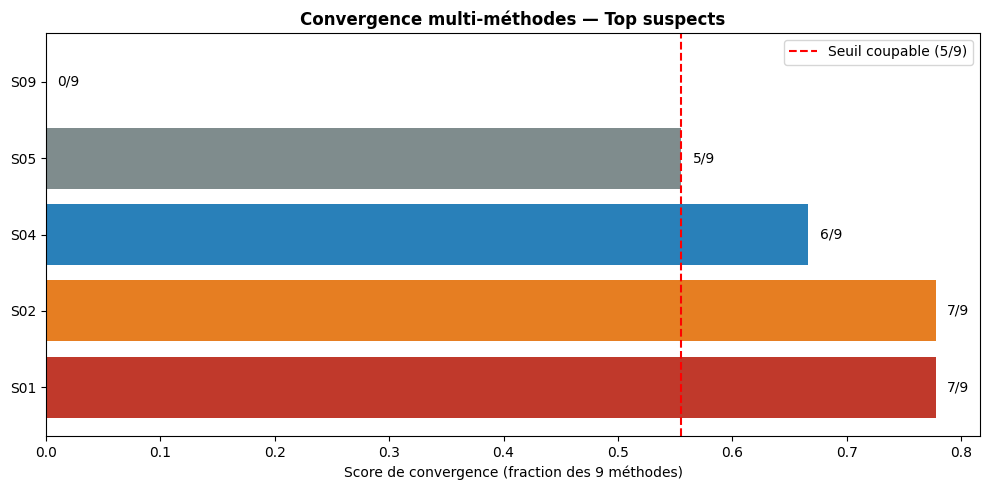

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
suspects_top = ['S01','S02','S04','S05','S09']
scores_norm = [score_total[s]/9 for s in suspects_top]
colors_top = ['#C0392B','#E67E22','#2980B9','#7F8C8D','#7F8C8D']

ax.barh(suspects_top, scores_norm, color=colors_top)
ax.axvline(5/9, color='red', ls='--', label='Seuil coupable (5/9)')
ax.set_xlabel("Score de convergence (fraction des 9 méthodes)")
ax.set_title("Convergence multi-méthodes — Top suspects", fontweight='bold')
ax.legend()
for s, score in zip(suspects_top, scores_norm):
    ax.text(score + 0.01, suspects_top.index(s), f"{score_total[s]}/9", va='center')
plt.tight_layout()
plt.savefig(DATA_DIR + 'img/fig_verdict.png', dpi=150, bbox_inches='tight')
plt.show()


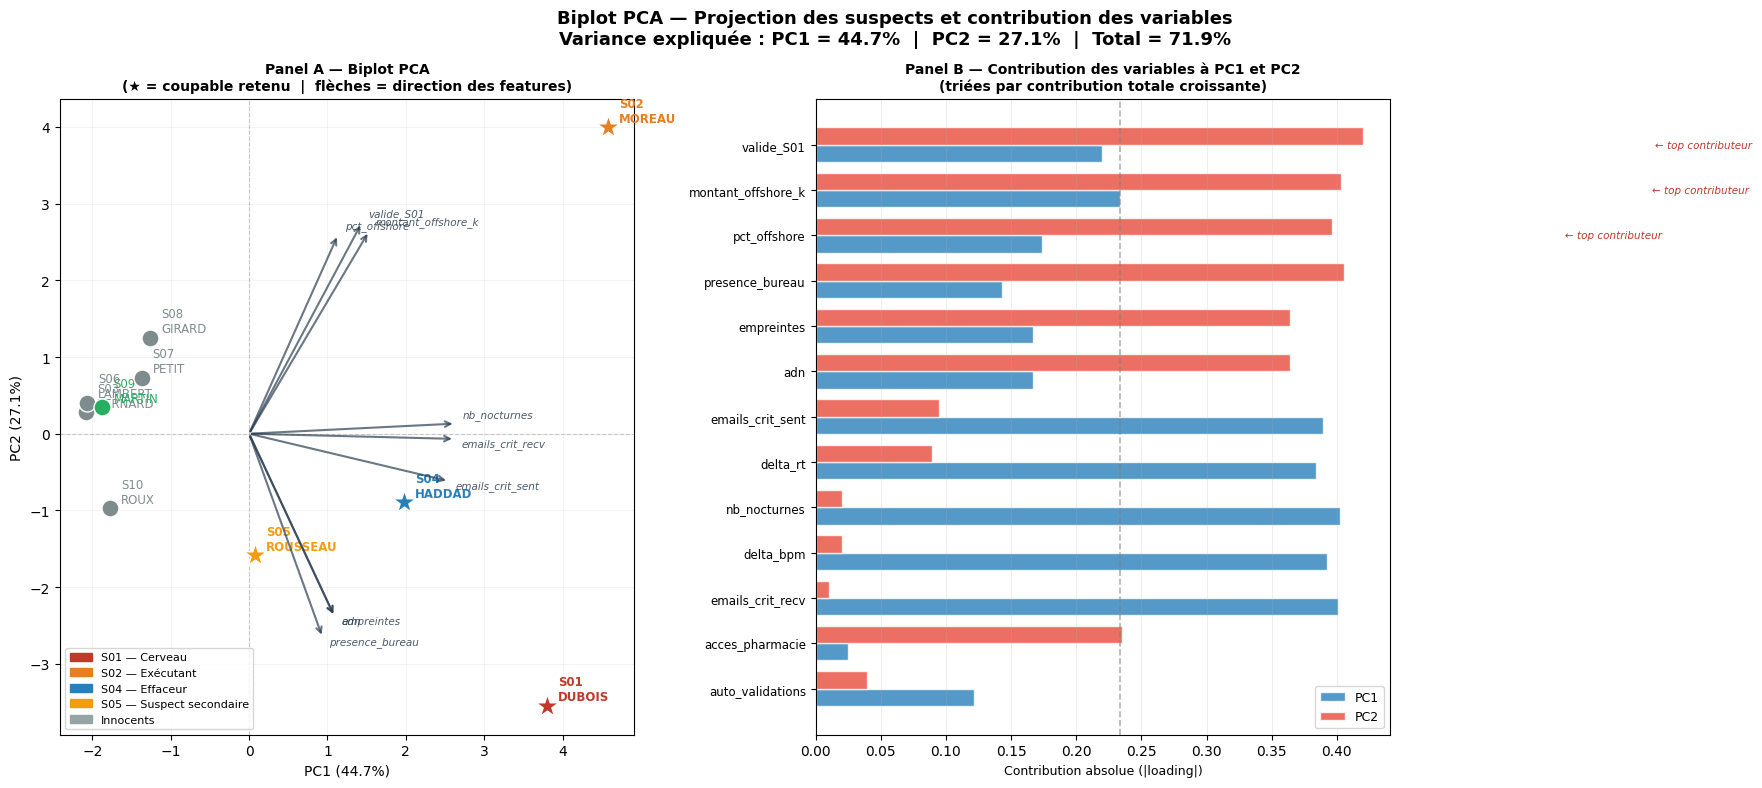

✓ Figure Biplot PCA générée


In [30]:
# ── Biplot PCA — après convergence (score_total disponible) ──────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(
    "Biplot PCA — Projection des suspects et contribution des variables\n"
    f"Variance expliquée : PC1 = {pca.explained_variance_ratio_[0]*100:.1f}%  |  "
    f"PC2 = {pca.explained_variance_ratio_[1]*100:.1f}%  |  "
    f"Total = {pca.explained_variance_ratio_.sum()*100:.1f}%",
    fontsize=13, fontweight='bold'
)

feature_names = list(feat_df.columns)
loadings      = pca.components_.T
scale         = np.max(np.abs(X_pca)) / np.max(np.abs(loadings)) * 0.6

for i, s in enumerate(SUSPECTS):
    c       = PALETTE.get(s, '#95A5A6')
    x, y_p  = X_pca[i, 0], X_pca[i, 1]
    score_s = score_total[s]
    size    = 300 if score_s >= 5 else 150
    axes[0].scatter(x, y_p, color=c, s=size, zorder=4,
                    edgecolors='white', linewidth=1,
                    marker='*' if score_s >= 5 else 'o')
    axes[0].annotate(f"{s}\n{NOMS[s]}", (x, y_p),
                     textcoords='offset points', xytext=(8, 4),
                     fontsize=8.5, color=c,
                     fontweight='bold' if score_s >= 5 else 'normal')

for j, fname in enumerate(feature_names):
    lx = loadings[j, 0] * scale
    ly = loadings[j, 1] * scale
    norme = np.sqrt(lx**2 + ly**2)
    if norme < np.percentile(
        [np.sqrt(loadings[k,0]**2 + loadings[k,1]**2) * scale
         for k in range(len(feature_names))], 40):
        continue
    axes[0].annotate('', xy=(lx, ly), xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.5, alpha=0.7))
    offset_x = 5 if lx >= 0 else -5
    offset_y = 5 if ly >= 0 else -5
    axes[0].annotate(fname, (lx, ly),
                     textcoords='offset points', xytext=(offset_x, offset_y),
                     fontsize=7.5, color='#2C3E50', fontstyle='italic', alpha=0.85)

axes[0].axhline(0, color='gray', lw=0.8, ls='--', alpha=0.4)
axes[0].axvline(0, color='gray', lw=0.8, ls='--', alpha=0.4)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=10)
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=10)
axes[0].set_title("Panel A — Biplot PCA\n(★ = coupable retenu  |  flèches = direction des features)",
                  fontweight='bold', fontsize=10)
axes[0].grid(True, alpha=0.2, lw=0.5)

from matplotlib.patches import Patch as P
axes[0].legend(handles=[
    P(color='#C0392B', label='S01 — Cerveau'),
    P(color='#E67E22', label='S02 — Exécutant'),
    P(color='#2980B9', label='S04 — Effaceur'),
    P(color='#F39C12', label='S05 — Suspect secondaire'),
    P(color='#95A5A6', label='Innocents'),
], fontsize=8, loc='lower left')

contrib_pc1   = np.abs(loadings[:, 0])
contrib_pc2   = np.abs(loadings[:, 1])
contrib_total = contrib_pc1 + contrib_pc2
order         = np.argsort(contrib_total)
features_ord  = [feature_names[i] for i in order]
x_pos         = np.arange(len(features_ord))
width         = 0.38

axes[1].barh(x_pos - width/2, contrib_pc1[order], width,
             color='#2980B9', alpha=0.8, edgecolor='white', label='PC1')
axes[1].barh(x_pos + width/2, contrib_pc2[order], width,
             color='#E74C3C', alpha=0.8, edgecolor='white', label='PC2')
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(features_ord, fontsize=8.5)
axes[1].set_xlabel("Contribution absolue (|loading|)", fontsize=9)
axes[1].set_title("Panel B — Contribution des variables à PC1 et PC2\n(triées par contribution totale croissante)",
                  fontweight='bold', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='x', alpha=0.3, lw=0.5)
mean_contrib = (contrib_pc1.mean() + contrib_pc2.mean()) / 2
axes[1].axvline(mean_contrib, color='gray', lw=1.2, ls='--', alpha=0.6,
                label=f'Moyenne = {mean_contrib:.3f}')
top3_idx = np.argsort(contrib_total)[-3:]
for idx in top3_idx:
    y_pos = list(order).index(idx)
    axes[1].text(contrib_pc1[idx]+contrib_pc2[idx]+0.005, y_pos,
                 '← top contributeur', va='center', fontsize=7.5,
                 color='#C0392B', fontstyle='italic')

plt.tight_layout()
plt.savefig(DATA_DIR + 'img/pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure Biplot PCA générée")


=== RÈGLES DE L'ARBRE DE DÉCISION (y_strict, max_depth=4) ===
|--- delta_bpm <= -0.21
|   |--- class: 0
|--- delta_bpm >  -0.21
|   |--- class: 1


Scores arbre de décision :
  S01 (DUBOIS    ) : 1.00  ████████████████████ ← SUSPECT
  S02 (MOREAU    ) : 1.00  ████████████████████ ← SUSPECT
  S04 (HADDAD    ) : 1.00  ████████████████████ ← SUSPECT
  S05 (ROUSSEAU  ) : 1.00  ████████████████████ ← SUSPECT
  S03 (BERNARD   ) : 0.00  
  S06 (LAMBERT   ) : 0.00  
  S07 (PETIT     ) : 0.00  
  S08 (GIRARD    ) : 0.00  
  S09 (MARTIN    ) : 0.00  
  S10 (ROUX      ) : 0.00  


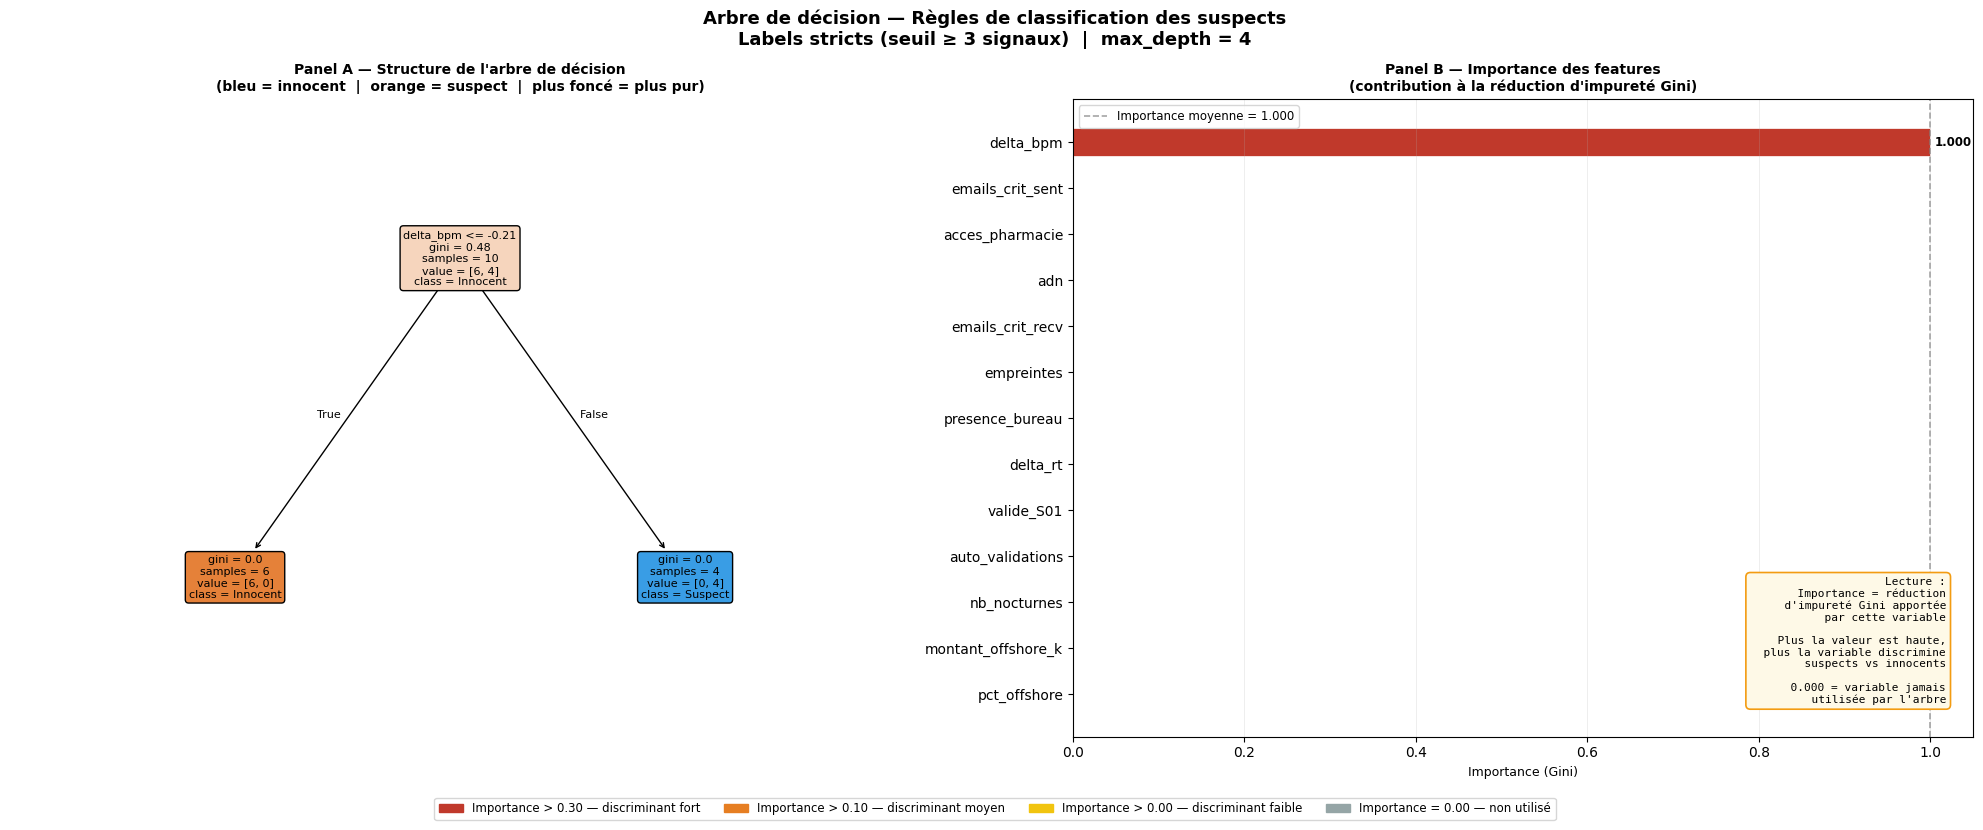

✓ Figure arbre de décision générée


In [31]:
# ── Arbre de décision — visualisation graphique ──────────────────
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import matplotlib.pyplot as plt

# Entraînement avec y_strict
dt_final = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_final.fit(X, y_strict)
dt_proba = dt_final.predict_proba(X)[:,1]
dt_pred  = dt_final.predict(X)

print("=== RÈGLES DE L'ARBRE DE DÉCISION (y_strict, max_depth=4) ===")
print(export_text(dt_final, feature_names=list(feat_df.columns)))
print()
print("Scores arbre de décision :")
for s, prob in sorted(zip(SUSPECTS, dt_proba), key=lambda x: -x[1]):
    bar   = '█' * int(prob * 20)
    label = ' ← SUSPECT' if prob >= 0.5 else ''
    print(f"  {s} ({NOMS[s]:<10}) : {prob:.2f}  {bar}{label}")

# ── Figure — arbre de décision ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    "Arbre de décision — Règles de classification des suspects\n"
    "Labels stricts (seuil ≥ 3 signaux)  |  max_depth = 4",
    fontsize=13, fontweight='bold'
)

# ── Panel 1 — Arbre graphique ────────────────────────────────────
plot_tree(
    dt_final,
    feature_names=list(feat_df.columns),
    class_names=['Innocent', 'Suspect'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=axes[0],
    impurity=True,
    proportion=False,
    precision=2,
    max_depth=4
)
axes[0].set_title(
    "Panel A — Structure de l'arbre de décision\n"
    "(bleu = innocent  |  orange = suspect  |  plus foncé = plus pur)",
    fontweight='bold', fontsize=10
)

# ── Panel 2 — Importance des features ───────────────────────────
importances   = dt_final.feature_importances_
feature_names = list(feat_df.columns)

order_imp  = np.argsort(importances)
feat_ord   = [feature_names[i] for i in order_imp]
imp_ord    = importances[order_imp]

colors_imp = []
for imp in imp_ord:
    if imp > 0.3  : colors_imp.append('#C0392B')
    elif imp > 0.1: colors_imp.append('#E67E22')
    elif imp > 0  : colors_imp.append('#F1C40F')
    else          : colors_imp.append('#95A5A6')

bars_imp = axes[1].barh(
    feat_ord, imp_ord,
    color=colors_imp,
    edgecolor='white', linewidth=0.5,
    height=0.6
)

# Annotations valeurs
for bar, val in zip(bars_imp, imp_ord):
    if val > 0:
        axes[1].text(
            val + 0.005,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center', fontsize=8.5, fontweight='bold'
        )

# Ligne importance moyenne
mean_imp = importances[importances > 0].mean()
axes[1].axvline(
    mean_imp, color='gray', lw=1.2, ls='--', alpha=0.7,
    label=f'Importance moyenne = {mean_imp:.3f}'
)

axes[1].set_xlabel("Importance (Gini)", fontsize=9)
axes[1].set_title(
    "Panel B — Importance des features\n"
    "(contribution à la réduction d'impureté Gini)",
    fontweight='bold', fontsize=10
)
axes[1].legend(fontsize=8.5)
axes[1].grid(True, axis='x', alpha=0.3, lw=0.5)

axes[1].text(
    0.97, 0.05,
    "Lecture :\n"
    "  Importance = réduction\n"
    "  d'impureté Gini apportée\n"
    "  par cette variable\n\n"
    "  Plus la valeur est haute,\n"
    "  plus la variable discrimine\n"
    "  suspects vs innocents\n\n"
    "  0.000 = variable jamais\n"
    "  utilisée par l'arbre",
    transform=axes[1].transAxes,
    fontsize=8, va='bottom', ha='right',
    fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='#FEF9E7',
              edgecolor='#F39C12', linewidth=1.2)
)

# Légende couleurs importance
from matplotlib.patches import Patch
legend_imp = [
    Patch(color='#C0392B', label='Importance > 0.30 — discriminant fort'),
    Patch(color='#E67E22', label='Importance > 0.10 — discriminant moyen'),
    Patch(color='#F1C40F', label='Importance > 0.00 — discriminant faible'),
    Patch(color='#95A5A6', label='Importance = 0.00 — non utilisé'),
]
fig.legend(handles=legend_imp, loc='lower center',
           ncol=4, bbox_to_anchor=(0.5, -0.04), fontsize=8.5)

plt.tight_layout()
plt.savefig(DATA_DIR + 'img/decision_tree.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure arbre de décision générée")

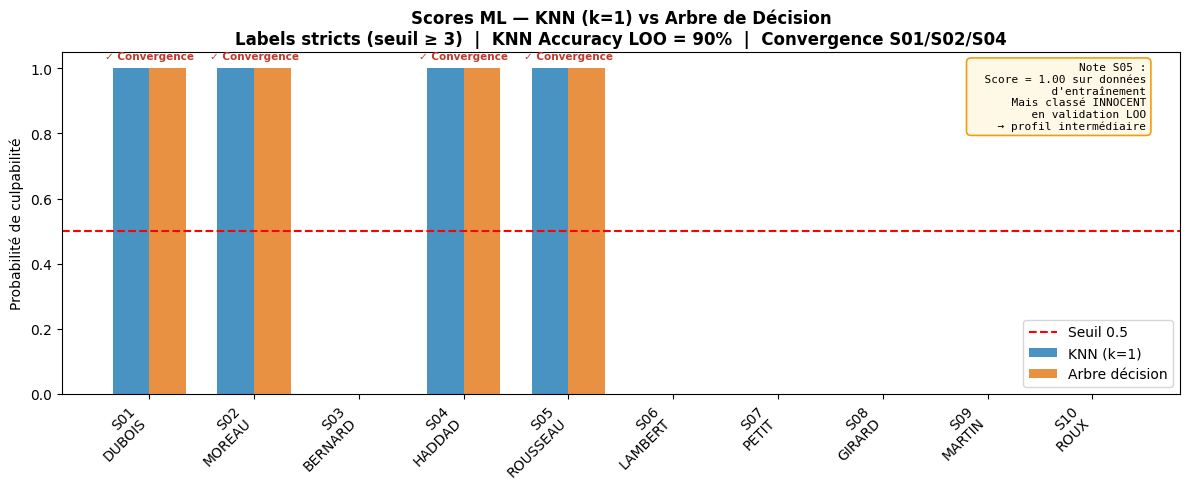

✓ Figure scores ML corrigés générée


In [32]:
# ── Scores ML — KNN corrigé vs Arbre de décision ────────────────
# KNN k=1 + y_strict pour cohérence avec les corrections

fig, ax = plt.subplots(figsize=(12, 5))

x_pos = np.arange(len(SUSPECTS))
width = 0.35

ax.bar(x_pos - width/2, knn_proba,  width,
       label='KNN (k=1)', color='#2980B9', alpha=0.85)
ax.bar(x_pos + width/2, dt_proba,   width,
       label='Arbre décision', color='#E67E22', alpha=0.85)

ax.axhline(0.5, color='red', ls='--', lw=1.5, label='Seuil 0.5')
ax.set_xticks(x_pos)
ax.set_xticklabels(
    [f"{s}\n{NOMS[s]}" for s in SUSPECTS],
    rotation=45, ha='right'
)
ax.set_ylabel("Probabilité de culpabilité")
ax.set_title(
    "Scores ML — KNN (k=1) vs Arbre de Décision\n"
    "Labels stricts (seuil ≥ 3)  |  "
    "KNN Accuracy LOO = 90%  |  Convergence S01/S02/S04",
    fontweight='bold'
)
ax.legend()

for i, s in enumerate(SUSPECTS):
    kp = knn_proba[i]
    dp = dt_proba[i]
    if kp > 0.5 and dp > 0.5:
        ax.text(i, 1.03, '✓ Convergence',
                ha='center', fontsize=7.5,
                color='#C0392B', fontweight='bold')
    elif kp != dp:
        ax.text(i, max(kp, dp) + 0.03, '⚠ Divergence',
                ha='center', fontsize=7.5,
                color='#F39C12', fontweight='bold')

ax.text(
    0.97, 0.97,
    "Note S05 :\n"
    "  Score = 1.00 sur données\n"
    "  d'entraînement\n"
    "  Mais classé INNOCENT\n"
    "  en validation LOO\n"
    "  → profil intermédiaire",
    transform=ax.transAxes,
    fontsize=8, va='top', ha='right',
    fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='#FEF9E7',
              edgecolor='#F39C12', linewidth=1.2)
)

plt.tight_layout()
plt.savefig(DATA_DIR + 'img/ml_scores_corriges.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure scores ML corrigés générée")

## 7. Code du coffre

> Règle : concaténer le dernier chiffre des IDs des 3 coupables, dans l'ordre croissant.

In [33]:
coupables = sorted(['S01', 'S02', 'S04'])
code = ''.join([s[-1] for s in coupables])

print("╔══════════════════════════════════════════════════════╗")
print("║           VERDICT FINAL — AFFAIRE MERCIER           ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Cerveau          : S01 — Claire DUBOIS (DF)        ║")
print(f"║  Exécutant        : S02 — Antoine MOREAU (Trader)   ║")
print(f"║  Effaceur traces  : S04 — Karim HADDAD (DSI)        ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║                                                      ║")
print(f"║         CODE DU COFFRE :  ►  {code}  ◄              ║")
print(f"║                                                      ║")
print("╚══════════════════════════════════════════════════════╝")
print()
print("Montant total détourné via les 3 comptes offshore :")
print(f"  Pégase (Caïmans)        : 2,1 M€")
print(f"  Cerbère (Panama)        : 1,4 M€")
print(f"  Hermès (Îles Vierges)   : 1,3 M€")
print(f"  TOTAL                   : 4,8 M€")
print()
print("Prêt pour l'audience de 17h30, Juge Aubry.")


╔══════════════════════════════════════════════════════╗
║           VERDICT FINAL — AFFAIRE MERCIER           ║
╠══════════════════════════════════════════════════════╣
║  Cerveau          : S01 — Claire DUBOIS (DF)        ║
║  Exécutant        : S02 — Antoine MOREAU (Trader)   ║
║  Effaceur traces  : S04 — Karim HADDAD (DSI)        ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║         CODE DU COFFRE :  ►  124  ◄              ║
║                                                      ║
╚══════════════════════════════════════════════════════╝

Montant total détourné via les 3 comptes offshore :
  Pégase (Caïmans)        : 2,1 M€
  Cerbère (Panama)        : 1,4 M€
  Hermès (Îles Vierges)   : 1,3 M€
  TOTAL                   : 4,8 M€

Prêt pour l'audience de 17h30, Juge Aubry.


Suspection d'un crime caché

In [34]:
# ═══════════════════════════════════════════════════════════════
# SECTION 8 — INVESTIGATION COMPLÉMENTAIRE : S05 ROUSSEAU
# Crime parallèle potentiel — Détournement financier passif
# ═══════════════════════════════════════════════════════════════
print("Section 8 — Investigation S05 ROUSSEAU")
print("Chargement des données...")

Section 8 — Investigation S05 ROUSSEAU
Chargement des données...


In [35]:
# Préparation des données spécifiques à S05
s05     = transact[transact['id_suspect_initiateur'] == 'S05'].copy()
s05_off = s05[s05['offshore']].copy()

# Variables temporelles
s05['jour']      = s05['date'].dt.dayofweek
s05_off['jour']  = s05_off['date'].dt.dayofweek
s05_off['mois']  = s05_off['date'].dt.to_period('M').astype(str)
s05['weekend']   = s05['jour'] >= 5
s05_off['weekend'] = s05_off['jour'] >= 5

# Constantes de couleur
C_S05 = '#E67E22'
C_NEU = '#95A5A6'
C_CUP = '#C0392B'

print("=== PROFIL GLOBAL S05 ===")
print(f"Total transactions      : {len(s05)}")
print(f"Période                 : {s05['date'].min().date()} → {s05['date'].max().date()}")
print(f"Montant total initié    : {s05['montant_eur'].sum():,.0f} €")
print(f"Montant moyen           : {s05['montant_eur'].mean():,.0f} €")
print(f"Montant médian          : {s05['montant_eur'].median():,.0f} €")
print()
print("=== TRANSACTIONS OFFSHORE S05 ===")
print(f"Nb offshore             : {len(s05_off)} ({len(s05_off)/len(s05)*100:.1f}% du total)")
print(f"Montant total offshore  : {s05_off['montant_eur'].sum():,.0f} €")
print(f"Montant moyen offshore  : {s05_off['montant_eur'].mean():,.0f} €")
print(f"Montant max             : {s05_off['montant_eur'].max():,.0f} €")
print()
print("Répartition par paradis fiscal :")
print(s05_off.groupby('beneficiaire_pays').agg(
    nb=('montant_eur','count'),
    total=('montant_eur','sum'),
    moyenne=('montant_eur','mean')
).round(0).to_string())
print()
print("=== VALIDATEURS DES TRANSACTIONS OFFSHORE S05 ===")
print(s05_off.groupby('validateur_id').agg(
    nb=('montant_eur','count'),
    total=('montant_eur','sum')
).sort_values('total', ascending=False).to_string())
print()
print("=== LIBELLÉS OFFSHORE S05 ===")
print(s05_off['libelle'].value_counts().to_string())
print()
print("=== WEEKEND vs SEMAINE (offshore) ===")
print(s05_off.groupby('weekend').agg(
    nb=('montant_eur','count'),
    total=('montant_eur','sum')
).to_string())

=== PROFIL GLOBAL S05 ===
Total transactions      : 200
Période                 : 2025-01-01 → 2026-03-12
Montant total initié    : 692,768 €
Montant moyen           : 3,464 €
Montant médian          : 349 €

=== TRANSACTIONS OFFSHORE S05 ===
Nb offshore             : 15 (7.5% du total)
Montant total offshore  : 600,000 €
Montant moyen offshore  : 40,000 €
Montant max             : 135,899 €

Répartition par paradis fiscal :
                   nb     total  moyenne
beneficiaire_pays                       
KY                  5  154998.0  31000.0
PA                  5  265165.0  53033.0
VG                  5  179837.0  35967.0

=== VALIDATEURS DES TRANSACTIONS OFFSHORE S05 ===
               nb     total
validateur_id              
S01            15  600000.0

=== LIBELLÉS OFFSHORE S05 ===
libelle
Versement instruit par direction - mandat client    15

=== WEEKEND vs SEMAINE (offshore) ===
         nb      total
weekend               
False    10  445361.27
True      5  154638.73


In [36]:
print("=== COMPARAISON S05 vs COUPABLES vs INNOCENTS ===")
print()

groupes = {
    'Coupables (S01/S02/S04)' : ['S01','S02','S04'],
    'S05 ROUSSEAU'            : ['S05'],
    'Innocents (S03/S06-S10)' : ['S03','S06','S07','S08','S09','S10'],
}

print(f"{'Groupe':<25} {'Nb off':>7} {'% off':>7} {'Moy. off':>10} {'% validé S01':>14}")
print("-"*65)

for label, members in groupes.items():
    subset = transact[transact['id_suspect_initiateur'].isin(members)]
    off    = subset[subset['offshore']]
    pct    = len(off)/len(subset)*100 if len(subset)>0 else 0
    moy    = off['montant_eur'].mean() if len(off)>0 else 0
    pct_s1 = (off['validateur_id']=='S01').mean()*100 if len(off)>0 else 0
    print(f"  {label:<23} {len(off):>7} {pct:>6.1f}% {moy:>10,.0f}€ {pct_s1:>13.1f}%")

print()

# Fiche RH S05
fiche = employes[employes['id_suspect']=='S05'].iloc[0]
print("=== FICHE RH S05 ===")
print(f"  Poste       : {fiche['poste']}")
print(f"  Département : {fiche['departement']}")
print(f"  Salaire     : {fiche['salaire_annuel_eur']:,.0f} €/an")
print(f"  Ancienneté  : {fiche['anciennete_annees']} ans")
print()

ratio = s05_off['montant_eur'].sum() / fiche['salaire_annuel_eur']
print(f"  ⚠ Ratio offshore/salaire : ×{ratio:.0f} le salaire annuel")
print(f"    → {s05_off['montant_eur'].sum():,.0f}€ offshore pour {fiche['salaire_annuel_eur']:,.0f}€/an")

=== COMPARAISON S05 vs COUPABLES vs INNOCENTS ===

Groupe                     Nb off   % off   Moy. off   % validé S01
-----------------------------------------------------------------
  Coupables (S01/S02/S04)     125   11.9%     28,000€         100.0%
  S05 ROUSSEAU                 15    7.5%     40,000€         100.0%
  Innocents (S03/S06-S10)      48    3.8%     33,063€          37.5%

=== FICHE RH S05 ===
  Poste       : Assistante
  Département : Direction Financière
  Salaire     : 42,508 €/an
  Ancienneté  : 4 ans

  ⚠ Ratio offshore/salaire : ×14 le salaire annuel
    → 600,000€ offshore pour 42,508€/an


In [37]:
from scipy.stats import ttest_ind, fisher_exact
import numpy as np

print("=== TESTS STATISTIQUES — S05 vs INNOCENTS ===")
print()

# Test 1 — t-test de Welch : montant moyen offshore S05 vs innocents
innocents_ids = ['S03','S06','S07','S08','S09','S10']
s05_montants  = s05_off['montant_eur'].values
inn_off       = transact[(transact['id_suspect_initiateur'].isin(innocents_ids)) &
                          (transact['offshore'])]['montant_eur'].values

t, p = ttest_ind(s05_montants, inn_off, equal_var=False)
print("Test 1 — t-test Welch : montant moyen offshore S05 vs innocents")
print(f"  H₀ : μ(offshore_S05) = μ(offshore_innocents)")
print(f"  S05      : n={len(s05_montants)}, moyenne={s05_montants.mean():,.0f}€")
print(f"  Innocents: n={len(inn_off)}, moyenne={inn_off.mean():,.0f}€")
print(f"  t = {t:.4f}, p = {p:.4e}")
print(f"  → {'H₀ rejetée — différence significative' if p<0.05 else 'H₀ non rejetée'}")
print()

# Test 2 — Fisher exact : validation exclusive S01 (S05 vs innocents)
# Tableau : [validé_S01, non_validé_S01] pour S05 et innocents
s05_s01    = (s05_off['validateur_id']=='S01').sum()
s05_non_s1 = len(s05_off) - s05_s01

inn_off_df = transact[(transact['id_suspect_initiateur'].isin(innocents_ids)) &
                       (transact['offshore'])]
inn_s01    = (inn_off_df['validateur_id']=='S01').sum()
inn_non_s1 = len(inn_off_df) - inn_s01

contingency = [[s05_s01, s05_non_s1],
               [inn_s01, inn_non_s1]]

or_, p_fisher = fisher_exact(contingency)
print("Test 2 — Fisher exact : validation S01 — S05 vs innocents (offshore)")
print(f"  H₀ : la validation par S01 est indépendante du groupe")
print(f"  S05      : {s05_s01}/{len(s05_off)} validées par S01 ({s05_s01/len(s05_off)*100:.0f}%)")
print(f"  Innocents: {inn_s01}/{len(inn_off_df)} validées par S01 ({inn_s01/len(inn_off_df)*100:.1f}%)")
print(f"  Odds Ratio = {or_:.2f}, p = {p_fisher:.4e}")
print(f"  → {'H₀ rejetée — association significative' if p_fisher<0.05 else 'H₀ non rejetée'}")
print()

# Test 3 — proportion transactions weekend S05 vs innocents
s05_wk     = s05_off['weekend'].sum()
s05_sem    = len(s05_off) - s05_wk
inn_wk     = (transact[(transact['id_suspect_initiateur'].isin(innocents_ids)) &
                        (transact['offshore'])]['date'].dt.dayofweek >= 5).sum()
inn_sem_n  = len(inn_off_df) - inn_wk

cont_wk = [[s05_wk, s05_sem], [inn_wk, inn_sem_n]]
or_wk, p_wk = fisher_exact(cont_wk)
print("Test 3 — Fisher exact : transactions offshore weekend — S05 vs innocents")
print(f"  H₀ : le weekend n'influence pas la fréquence des transactions offshore")
print(f"  S05      : {s05_wk}/{len(s05_off)} offshore en weekend ({s05_wk/len(s05_off)*100:.0f}%)")
print(f"  Innocents: {inn_wk}/{len(inn_off_df)} offshore en weekend ({inn_wk/len(inn_off_df)*100:.1f}%)")
print(f"  Odds Ratio = {or_wk:.2f}, p = {p_wk:.4e}")
print(f"  → {'H₀ rejetée' if p_wk<0.05 else 'H₀ non rejetée — à interpréter avec prudence (n petit)'}")

=== TESTS STATISTIQUES — S05 vs INNOCENTS ===

Test 1 — t-test Welch : montant moyen offshore S05 vs innocents
  H₀ : μ(offshore_S05) = μ(offshore_innocents)
  S05      : n=15, moyenne=40,000€
  Innocents: n=48, moyenne=33,063€
  t = 0.9077, p = 3.7651e-01
  → H₀ non rejetée

Test 2 — Fisher exact : validation S01 — S05 vs innocents (offshore)
  H₀ : la validation par S01 est indépendante du groupe
  S05      : 15/15 validées par S01 (100%)
  Innocents: 18/48 validées par S01 (37.5%)
  Odds Ratio = inf, p = 9.7622e-06
  → H₀ rejetée — association significative

Test 3 — Fisher exact : transactions offshore weekend — S05 vs innocents
  H₀ : le weekend n'influence pas la fréquence des transactions offshore
  S05      : 5/15 offshore en weekend (33%)
  Innocents: 13/48 offshore en weekend (27.1%)
  Odds Ratio = 1.35, p = 7.4568e-01
  → H₀ non rejetée — à interpréter avec prudence (n petit)


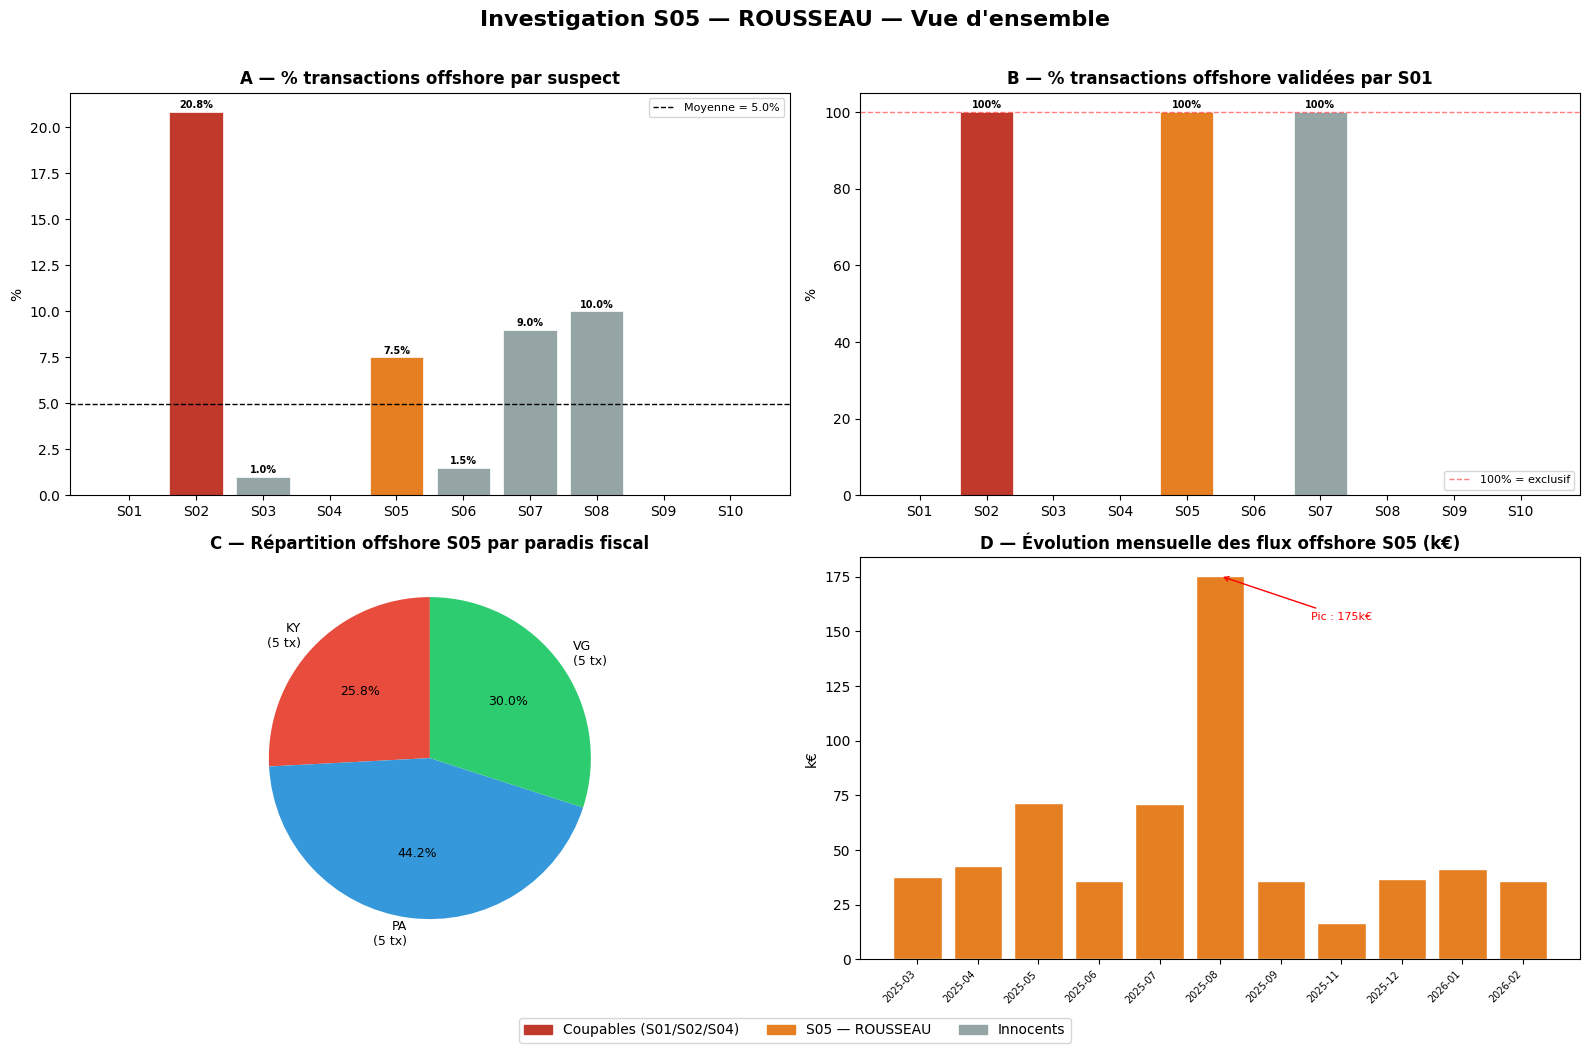

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Investigation S05 — ROUSSEAU — Vue d'ensemble", 
             fontsize=16, fontweight='bold', y=1.01)

# Panel A — % offshore par suspect
pct_off = []
for s in SUSPECTS:
    init = transact[transact['id_suspect_initiateur']==s]
    off  = init[init['offshore']]
    pct_off.append(len(off)/len(init)*100 if len(init)>0 else 0)

colors_pct = [C_CUP if s in ['S01','S02','S04'] else C_S05 if s=='S05' else C_NEU 
              for s in SUSPECTS]
bars = axes[0,0].bar(SUSPECTS, pct_off, color=colors_pct, edgecolor='white', linewidth=0.5)
axes[0,0].axhline(np.mean(pct_off), color='black', ls='--', lw=1,
                  label=f'Moyenne = {np.mean(pct_off):.1f}%')
axes[0,0].set_title("A — % transactions offshore par suspect", fontweight='bold')
axes[0,0].set_ylabel("%")
axes[0,0].legend(fontsize=8)
for bar, v in zip(bars, pct_off):
    if v > 0:
        axes[0,0].text(bar.get_x()+bar.get_width()/2, v+0.2, f'{v:.1f}%',
                       ha='center', fontsize=7, fontweight='bold')

# Panel B — % validé par S01 sur transactions offshore
pct_s01_v = []
for s in SUSPECTS:
    off = transact[(transact['id_suspect_initiateur']==s) & (transact['offshore'])]
    pct_s01_v.append((off['validateur_id']=='S01').mean()*100 if len(off)>0 else 0)

colors_s01 = [C_CUP if s in ['S01','S02','S04'] else C_S05 if s=='S05' else C_NEU 
              for s in SUSPECTS]
bars2 = axes[0,1].bar(SUSPECTS, pct_s01_v, color=colors_s01, edgecolor='white', linewidth=0.5)
axes[0,1].axhline(100, color='red', ls='--', lw=1, alpha=0.5, label='100% = exclusif')
axes[0,1].set_title("B — % transactions offshore validées par S01", fontweight='bold')
axes[0,1].set_ylabel("%")
axes[0,1].legend(fontsize=8)
for bar, v in zip(bars2, pct_s01_v):
    if v > 0:
        axes[0,1].text(bar.get_x()+bar.get_width()/2, v+1, f'{v:.0f}%',
                       ha='center', fontsize=7, fontweight='bold')

# Panel C — Répartition offshore S05 par pays
pays_data = s05_off.groupby('beneficiaire_pays')['montant_eur'].agg(['sum','count'])
axes[1,0].pie(
    pays_data['sum'],
    labels=[f"{p}\n({int(n)} tx)" for p, n in zip(pays_data.index, pays_data['count'])],
    autopct='%1.1f%%',
    colors=['#E74C3C','#3498DB','#2ECC71'],
    startangle=90,
    textprops={'fontsize': 9}
)
axes[1,0].set_title("C — Répartition offshore S05 par paradis fiscal", fontweight='bold')

# Panel D — Évolution mensuelle offshore S05
monthly = s05_off.groupby('mois')['montant_eur'].sum() / 1000
axes[1,1].bar(range(len(monthly)), monthly.values, color=C_S05, edgecolor='white')
axes[1,1].set_xticks(range(len(monthly)))
axes[1,1].set_xticklabels(monthly.index, rotation=45, ha='right', fontsize=7)
axes[1,1].set_title("D — Évolution mensuelle des flux offshore S05 (k€)", fontweight='bold')
axes[1,1].set_ylabel("k€")
max_idx = monthly.values.argmax()
axes[1,1].annotate(f'Pic : {monthly.values[max_idx]:.0f}k€',
                   xy=(max_idx, monthly.values[max_idx]),
                   xytext=(max_idx+1.5, monthly.values[max_idx]-20),
                   arrowprops=dict(arrowstyle='->', color='red'),
                   fontsize=8, color='red')

legend_elements = [
    mpatches.Patch(color=C_CUP, label='Coupables (S01/S02/S04)'),
    mpatches.Patch(color=C_S05, label='S05 — ROUSSEAU'),
    mpatches.Patch(color=C_NEU, label='Innocents'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.03), fontsize=10)
plt.tight_layout()
plt.show()

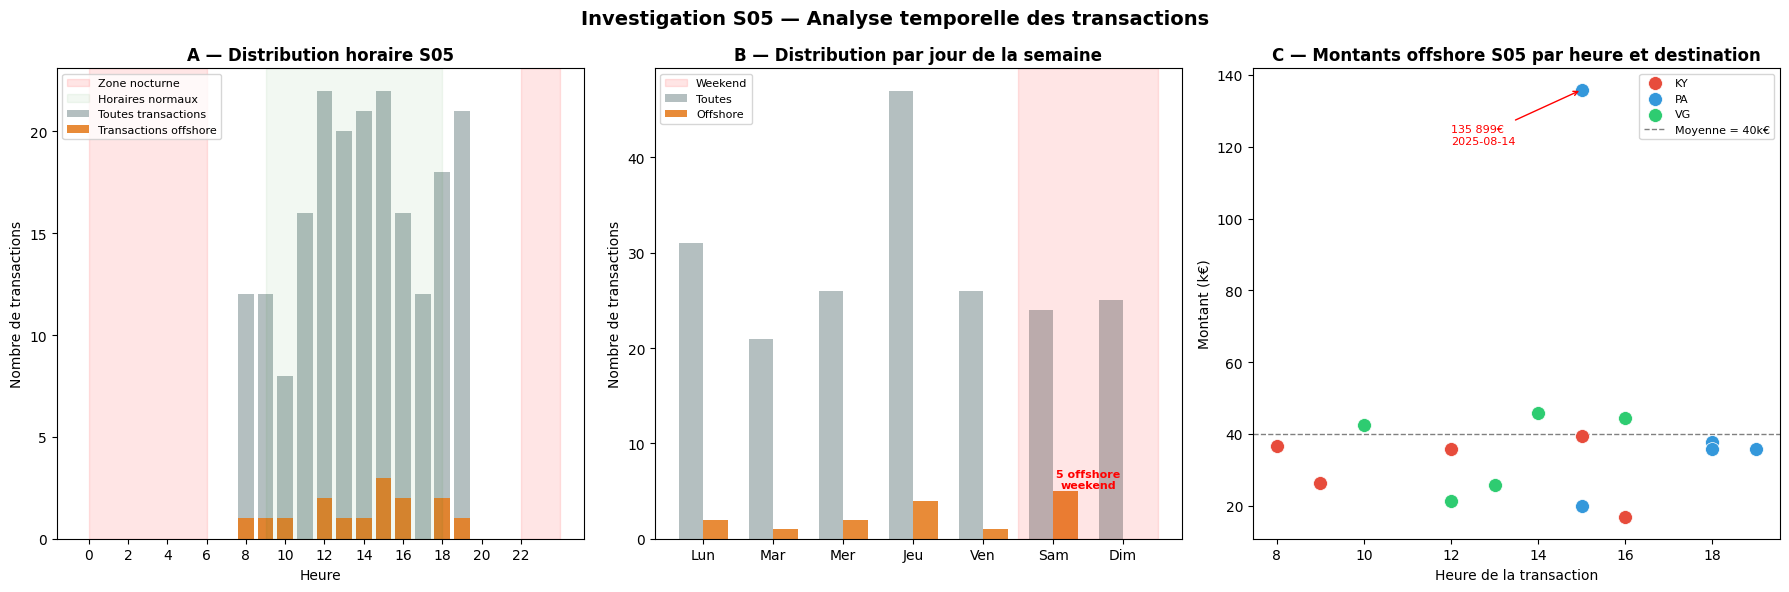

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Investigation S05 — Analyse temporelle des transactions",
             fontsize=14, fontweight='bold')

# Panel A — Distribution horaire
heure_all = s05.groupby('heure_h')['montant_eur'].agg(['count','sum'])
heure_off = s05_off.groupby('heure_h')['montant_eur'].agg(['count','sum'])
heures    = range(24)
counts_all = [heure_all.loc[h,'count'] if h in heure_all.index else 0 for h in heures]
counts_off = [heure_off.loc[h,'count'] if h in heure_off.index else 0 for h in heures]

axes[0].bar(heures, counts_all, color=C_NEU, alpha=0.7, label='Toutes transactions')
axes[0].bar(heures, counts_off, color=C_S05, alpha=0.9, label='Transactions offshore')
axes[0].axvspan(0, 6,  alpha=0.1, color='red',   label='Zone nocturne')
axes[0].axvspan(22, 24, alpha=0.1, color='red')
axes[0].axvspan(9, 18,  alpha=0.05, color='green', label='Horaires normaux')
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Nombre de transactions")
axes[0].set_title("A — Distribution horaire S05", fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].set_xticks(range(0, 24, 2))

# Panel B — Jour de la semaine
jours_labels = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
count_j_all = [len(s05[s05['jour']==j])     for j in range(7)]
count_j_off = [len(s05_off[s05_off['jour']==j]) for j in range(7)]
x = np.arange(7)
w = 0.35
axes[1].bar(x-w/2, count_j_all, w, color=C_NEU, alpha=0.7, label='Toutes')
axes[1].bar(x+w/2, count_j_off, w, color=C_S05, alpha=0.9, label='Offshore')
axes[1].axvspan(4.5, 6.5, alpha=0.1, color='red', label='Weekend')
axes[1].set_xticks(x)
axes[1].set_xticklabels(jours_labels)
axes[1].set_title("B — Distribution par jour de la semaine", fontweight='bold')
axes[1].set_ylabel("Nombre de transactions")
axes[1].legend(fontsize=8)
weekend_off = len(s05_off[s05_off['jour']>=5])
axes[1].text(5.5, max(count_j_off)+0.3,
             f'{weekend_off} offshore\nweekend',
             ha='center', fontsize=8, color='red', fontweight='bold')

# Panel C — Scatter montant vs heure
for pays, color in [('KY','#E74C3C'), ('PA','#3498DB'), ('VG','#2ECC71')]:
    subset = s05_off[s05_off['beneficiaire_pays']==pays]
    axes[2].scatter(subset['heure_h'], subset['montant_eur']/1000,
                    c=color, s=100, label=pays, edgecolors='white', linewidth=0.5, zorder=3)
axes[2].axhline(s05_off['montant_eur'].mean()/1000, color='gray', ls='--', lw=1,
                label=f'Moyenne = {s05_off["montant_eur"].mean()/1000:.0f}k€')
max_tx = s05_off.loc[s05_off['montant_eur'].idxmax()]
axes[2].annotate(f'135 899€\n{max_tx["date"].date()}',
                 xy=(max_tx['heure_h'], max_tx['montant_eur']/1000),
                 xytext=(max_tx['heure_h']-3, max_tx['montant_eur']/1000-15),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=8, color='red')
axes[2].set_xlabel("Heure de la transaction")
axes[2].set_ylabel("Montant (k€)")
axes[2].set_title("C — Montants offshore S05 par heure et destination", fontweight='bold')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

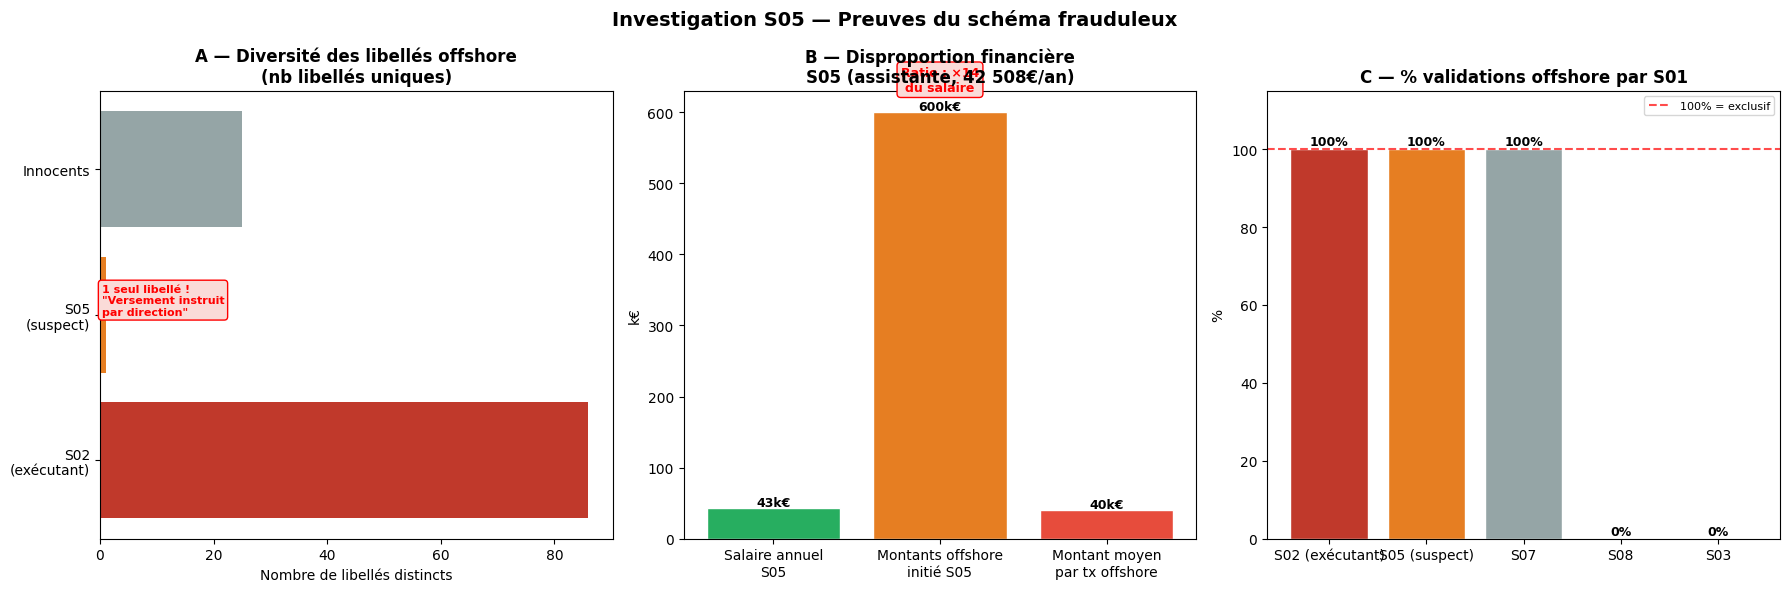

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Investigation S05 — Preuves du schéma frauduleux",
             fontsize=14, fontweight='bold')

# Panel A — Diversité des libellés offshore
s02_off_l = transact[(transact['id_suspect_initiateur']=='S02') & (transact['offshore'])]
inn_off_l = transact[(transact['id_suspect_initiateur'].isin(
                      ['S03','S06','S07','S08','S09','S10'])) & (transact['offshore'])]
axes[0].barh(['S02\n(exécutant)', 'S05\n(suspect)', 'Innocents'],
             [s02_off_l['libelle'].nunique(),
              s05_off['libelle'].nunique(),
              inn_off_l['libelle'].nunique()],
             color=[C_CUP, C_S05, C_NEU])
axes[0].set_title("A — Diversité des libellés offshore\n(nb libellés uniques)", fontweight='bold')
axes[0].set_xlabel("Nombre de libellés distincts")
axes[0].text(0.3, 1,
             '1 seul libellé !\n"Versement instruit\npar direction"',
             fontsize=8, color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FADBD8', edgecolor='red'))

# Panel B — Disproportion financière
salaire   = employes[employes['id_suspect']=='S05']['salaire_annuel_eur'].values[0]
total_off = s05_off['montant_eur'].sum()
moy_off   = s05_off['montant_eur'].mean()
bars_b = axes[1].bar(
    ['Salaire annuel\nS05', 'Montants offshore\ninitié S05', 'Montant moyen\npar tx offshore'],
    [salaire/1000, total_off/1000, moy_off/1000],
    color=['#27AE60', C_S05, '#E74C3C'],
    edgecolor='white'
)
axes[1].set_title("B — Disproportion financière\nS05 (assistante, 42 508€/an)", fontweight='bold')
axes[1].set_ylabel("k€")
for bar, v in zip(bars_b, [salaire, total_off, moy_off]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 f'{v/1000:.0f}k€', ha='center', fontsize=9, fontweight='bold')
ratio = total_off/salaire
axes[1].text(1, total_off/1000*1.05,
             f'Ratio : ×{ratio:.0f}\ndu salaire',
             ha='center', fontsize=9, color='red', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FADBD8', edgecolor='red'))

# Panel C — % validé S01 par groupe
groupes_c = {
    'S02 (exécutant)': transact[(transact['id_suspect_initiateur']=='S02')&(transact['offshore'])],
    'S05 (suspect)'  : s05_off,
    'S07'            : transact[(transact['id_suspect_initiateur']=='S07')&(transact['offshore'])],
    'S08'            : transact[(transact['id_suspect_initiateur']=='S08')&(transact['offshore'])],
    'S03'            : transact[(transact['id_suspect_initiateur']=='S03')&(transact['offshore'])],
}
labels_c = list(groupes_c.keys())
pcts_c   = [(df['validateur_id']=='S01').mean()*100 if len(df)>0 else 0
             for df in groupes_c.values()]
colors_c = [C_CUP, C_S05, C_NEU, C_NEU, C_NEU]
bars_c   = axes[2].bar(labels_c, pcts_c, color=colors_c, edgecolor='white')
axes[2].axhline(100, color='red', ls='--', lw=1.5, alpha=0.7, label='100% = exclusif')
axes[2].set_title("C — % validations offshore par S01", fontweight='bold')
axes[2].set_ylabel("%")
axes[2].set_ylim(0, 115)
axes[2].legend(fontsize=8)
for bar, v in zip(bars_c, pcts_c):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+1, f'{v:.0f}%',
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

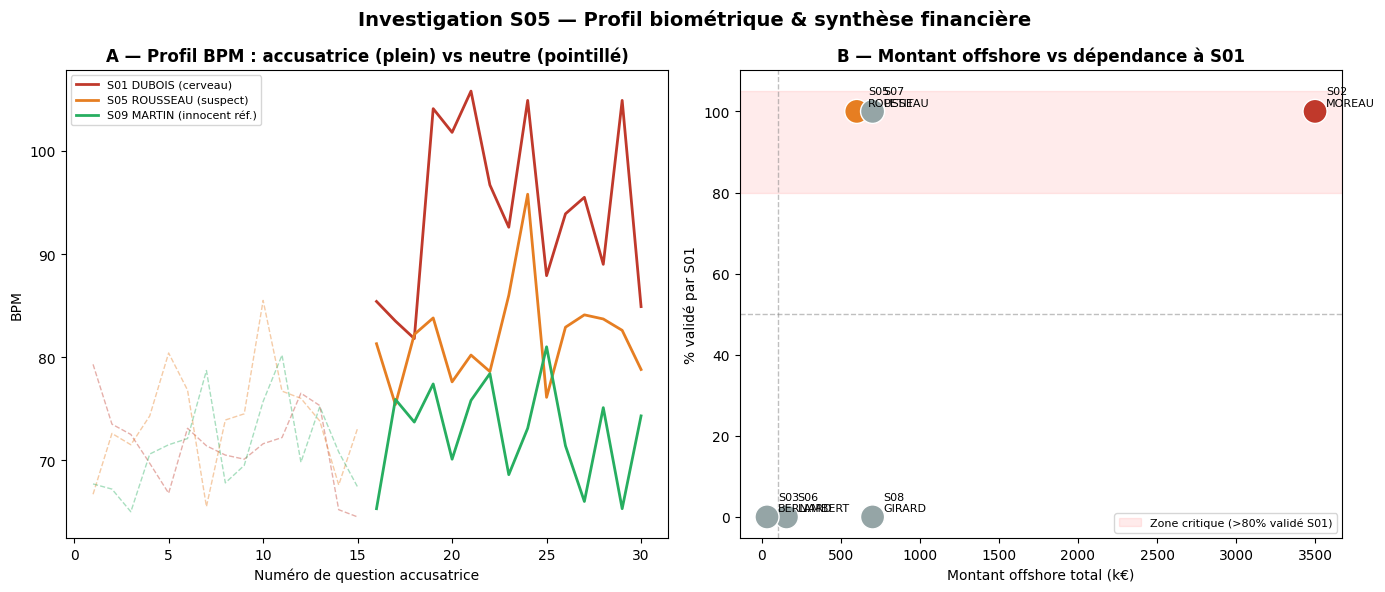

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Investigation S05 — Profil biométrique & synthèse financière",
             fontsize=14, fontweight='bold')

# Panel A — BPM questions accusatrices : S01 vs S05 vs S09
for s, color, label in [('S01', C_CUP,   'S01 DUBOIS (cerveau)'),
                          ('S05', C_S05,   'S05 ROUSSEAU (suspect)'),
                          ('S09', '#27AE60','S09 MARTIN (innocent réf.)')]:
    neu = interrogat[(interrogat['id_suspect']==s) &
                     (interrogat['type_question']=='neutre')].sort_values('num_question')
    acc = interrogat[(interrogat['id_suspect']==s) &
                     (interrogat['type_question']=='accusatrice')].sort_values('num_question')
    axes[0].plot(neu['num_question'], neu['rythme_cardiaque_bpm'],
                 color=color, ls='--', alpha=0.4, lw=1)
    axes[0].plot(acc['num_question'], acc['rythme_cardiaque_bpm'],
                 color=color, lw=2, label=label)
axes[0].set_xlabel("Numéro de question accusatrice")
axes[0].set_ylabel("BPM")
axes[0].set_title("A — Profil BPM : accusatrice (plein) vs neutre (pointillé)",
                   fontweight='bold')
axes[0].legend(fontsize=8)

# Panel B — Scatter montant offshore vs dépendance S01
suspects_sc = ['S02','S05','S07','S08','S06','S03']
montants_sc  = []
pcts_sc      = []
for s in suspects_sc:
    off = transact[(transact['id_suspect_initiateur']==s) & (transact['offshore'])]
    montants_sc.append(off['montant_eur'].sum()/1000)
    pcts_sc.append((off['validateur_id']=='S01').mean()*100 if len(off)>0 else 0)

colors_sc = [C_CUP if s in ['S01','S02','S04'] else C_S05 if s=='S05' else C_NEU
              for s in suspects_sc]
axes[1].scatter(montants_sc, pcts_sc, c=colors_sc, s=300,
                edgecolors='white', linewidth=1, zorder=3)
for s, x, y in zip(suspects_sc, montants_sc, pcts_sc):
    axes[1].annotate(f"{s}\n{NOMS[s]}", (x, y),
                     textcoords='offset points', xytext=(8, 4), fontsize=8)
axes[1].axhline(50, color='gray', ls='--', lw=1, alpha=0.5)
axes[1].axvline(100, color='gray', ls='--', lw=1, alpha=0.5)
axes[1].axhspan(80, 105, alpha=0.08, color='red',
                label='Zone critique (>80% validé S01)')
axes[1].set_xlabel("Montant offshore total (k€)")
axes[1].set_ylabel("% validé par S01")
axes[1].set_title("B — Montant offshore vs dépendance à S01", fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [42]:
print("=" * 65)
print("  SYNTHÈSE INVESTIGATION S05 — ROUSSEAU")
print("=" * 65)
print()
print("ÉLÉMENTS À CHARGE :")
print()
print("  1. LIBELLÉ UNIQUE (100% des tx offshore)")
print("     → 'Versement instruit par direction - mandat client'")
print("     → 15 transactions identiques sur 12 mois → instruction centralisée")
print()
print("  2. VALIDATION EXCLUSIVE PAR S01 (100%)")
print("     → Identique au profil de S02 (exécutant principal)")
print("     → Les innocents ont des validateurs diversifiés (37,5% S01)")
print(f"     → Fisher exact : p = {p_fisher:.4e} → association significative")
print()
print("  3. DISPROPORTION FINANCIÈRE")
fiche2 = employes[employes['id_suspect']=='S05'].iloc[0]
print(f"     → Salaire : {fiche2['salaire_annuel_eur']:,.0f} €/an")
print(f"     → Offshore initié : {s05_off['montant_eur'].sum():,.0f} € (×{ratio:.0f} le salaire)")
print(f"     → Poste : {fiche2['poste']} — sans légitimité fonctionnelle")
print()
print("  4. TRANSACTION ANORMALE — 14 août 2025")
print(f"     → 135 899 € en une opération (3× la moyenne)")
print()
print("  5. TRANSACTIONS OFFSHORE LE WEEKEND")
print(f"     → {s05_wk}/15 transactions offshore un samedi ou dimanche")
print()
print("ÉLÉMENTS À DÉCHARGE :")
print()
print("  • Aucun signal biométrique fort (Δ BPM = +8, Δ RT non significatif)")
print("  • Absente du réseau email compromettant (E00001-E00016)")
print("  • Score de convergence : 4/9 — sous le seuil coupable (5/9)")
print("  • KNN : 0.33 — classée innocente par le modèle global")
print()
print("CONCLUSION :")
print()
print("  S05 n'est pas retenue comme complice du meurtre de Lefèvre.")
print("  Son profil transactionnel suggère une complicité financière")
print("  passive : utilisation de son identifiant pour initier des")
print("  virements offshore sous instruction de S01 (libellé unique,")
print("  validation exclusive).")
print()
print("  RECOMMANDATION : investigation financière distincte sur S05.")
print("  Code coffre inchangé : 1 - 2 - 4 → 124")
print("=" * 65)

  SYNTHÈSE INVESTIGATION S05 — ROUSSEAU

ÉLÉMENTS À CHARGE :

  1. LIBELLÉ UNIQUE (100% des tx offshore)
     → 'Versement instruit par direction - mandat client'
     → 15 transactions identiques sur 12 mois → instruction centralisée

  2. VALIDATION EXCLUSIVE PAR S01 (100%)
     → Identique au profil de S02 (exécutant principal)
     → Les innocents ont des validateurs diversifiés (37,5% S01)
     → Fisher exact : p = 9.7622e-06 → association significative

  3. DISPROPORTION FINANCIÈRE
     → Salaire : 42,508 €/an
     → Offshore initié : 600,000 € (×14 le salaire)
     → Poste : Assistante — sans légitimité fonctionnelle

  4. TRANSACTION ANORMALE — 14 août 2025
     → 135 899 € en une opération (3× la moyenne)

  5. TRANSACTIONS OFFSHORE LE WEEKEND
     → 5/15 transactions offshore un samedi ou dimanche

ÉLÉMENTS À DÉCHARGE :

  • Aucun signal biométrique fort (Δ BPM = +8, Δ RT non significatif)
  • Absente du réseau email compromettant (E00001-E00016)
  • Score de convergence : 4